# **Barak Capital - Final Project**

## a. Task overview


<span style="font-size:18px;">
<b> Dataset</b>: 10 days of data for 2 highly correlated stocks A and B. March 3–April 7, 2026 (every second day), and April 15, 2026.
</span>
<br><br>

![Dataset columns](presentation/dataset.png) 

<br><br>
<span style="font-size:18px;">
<b>Goal</b>: For each message at position i need to predict delay using only information from messages 0 through
i−1 (and cross-channel data up to the current time).
<br><br>
<b>Formula</b>: delay = arrival_time − sending_time
<br><br>
<b>Note</b>: At the time of prediction you know the arrival_time and message_type of message i but you don't know its sending_time
<br><br>
<b>Evaluation</b>: Mean Squared Error between predicted delay and actual delay 
<br><br>
<b>Note</b>: The first 1,000 messages of each day will not be evaluated. You may output any prediction for these rows — use them to initialize your model.
<br><br>
    
</span>







## b. My plan

<br>
<div style="font-size:18px; line-height:1.6;">

<ol>
<li>
Define the prediction target <b>delay</b> 
(delay = arrival_time − sending_time)
</li>

<li>
Create different features based on lag and rolling descriptive statistics:
<ul>
<li>Same-channel features</li>
<li>Spike features</li>
<li>Arrival gap features</li>
<li>Message type feature</li>
<li>Time-position features</li>
<li>Cross-channel features</li>
</ul>
</li>

<li>
Analyze delay distribution and choose the appropriate transformation.
</li>

<li>
Create XGBoost and LightGBM models using all features as predictors and delay as the target variable. Training dataset: March 3–April 7, 2026 (9 days) . Testing dataset: April 15, 2026 (1 day).
</li>

<li>
Perform feature selection based on:
<ul>
<li>Correlation matrix</li>
<li>Feature importance</li>
<li>MSE</li>
</ul>
Find the model and predictor set with the lowest MSE or RMSE.
</li>

<li>
Perform parameter tuning:
<ul>
<li>Grid Search for XGBoost (Stock A)</li>
<li>Random Search for LightGBM (Stock B)</li>
</ul>
</li>
 
<li>
Train the final models on 10 days. Save these models. 
</li>

</ol>

</div>



## 1. Data Processing

In [19]:
import os


print(os.getcwd())

/Users/kamila/Desktop/Barak capital/home_test_Barak/solution/code



<span style="font-size:16px;">
    
    
## Feature Engineering Pipeline

The goal of the feature engineering pipeline was to create the possible features for predicting message delivery delay.

First, I defined the prediction target:

```python
delay = arrival_time - sending_time
```

This represents the network/message delivery latency that the model learns to predict.

All datasets were sorted by `arrival_time` because the assignment requires an online prediction setting where only past information can be used.

---

## Same-Channel Features

For each stock separately, I created features based on the stock’s own historical behavior.

### A. Lag Features

Examples:

- `own_lag_1` - delay of previous message
- `own_lag_2` - delay 2 messages ago
- `own_lag_3` - delay 3 messages ago
- `own_lag_5` - delay 5 messages ago
- `own_lag_10` - delay 10 messages ago
- `own_lag_20` - delay 20 messages ago

These represent previous observed delays for the same stock.

The intuition is that delay is highly autocorrelated: if recent messages experienced high latency, future messages are also more likely to experience elevated delay.

---

### B. Rolling Statistics Features

For rolling windows:

```python
WINDOWS = [5, 10, 20, 50, 100]
```

I calculated:

- rolling mean
- rolling standard deviation
- rolling median
- rolling maximum
- rolling minimum

Examples:

- `own_mean_5` - the rolling average delay over the previous 5 messages from the same stock channel
- `own_std_20` - the rolling standard deviation of delays over the previous 20 messages.
- `own_median_100` - the rolling median delay over the previous 100 messages.
- `own_max_10` - the rolling maximum delay over the previous 10 messages.
- `own_min_50` - the rolling minimum delay over the previous 50 messages.

These features summarize short-, medium-, and long-term behavior of the delay process.

Rolling means capture recent average latency, while rolling standard deviation measures volatility. Rolling max/min help identify extreme behavior and latency spikes.

---

## Spike Features

Examples:

- `own_spike_ratio_5`
- `own_spike_ratio_10`
- `own_spike_ratio_50`
- `own_spike_ratio_100`

These were calculated as:

```python
own_lag_1 / own_mean_window
```

The goal was to detect abnormal spikes relative to recent history.

For example, if the most recent delay is much larger than the rolling mean, this may indicate sudden congestion or abnormal network behavior.

This was important because the delay distribution contains sharp latency spikes rather than smooth continuous behavior.

---

## Arrival Gap Features

Examples:

- `own_arrival_gap` - the difference in arrival time between the current message and the previous message from the same stock channel.

- `own_gap_mean_10` - the rolling average of `own_arrival_gap` over the previous 10 messages.


These features help capture message intensity and market activity. During periods of high message traffic, delays may behave differently due to increased system load.

---

## Message Type Feature

Example:

- `message_type_enc`

I encoded whether the message type was:

```text
MarketChange - 1, Ticker - 0
```


Different message types may have different latency characteristics, so encoding this information helps the model distinguish between them.

---

## Time-Position Features

Examples:

- `seconds_from_day_start` - how many seconds have passed since the first message arrival of the day
- `minutes_from_day_start` - how many minutes have passed since the first message arrival of the day
- `row_number_in_day` - the sequential position of the message within the trading day

These features capture intraday seasonality effects.

Message traffic and delay behavior can vary significantly during different periods of the trading day, such as:

- market open
- midday
- market close

These variables help the model learn time-dependent patterns.

---

## Cross-Channel Features

A major part of the pipeline was creating features from the other stock channel.

For each stock, I created a rolling “state” representation of the opposite channel using features such as:

- `other_lag_1`
- `other_mean_10`
- `other_std_20`
- `other_median_50`
- `other_max_100`
- `other_spike_ratio_50`

The intuition is that Stock A and Stock B are correlated channels, so congestion or latency spikes in one channel may help predict behavior in the other channel.

---

## Causal Merge Using `merge_asof`

To ensure no future information leakage, I used:

```python
pd.merge_asof(..., direction="backward", allow_exact_matches=False)
```

This merges only the most recent available state of the other channel before the current message arrival time.

Therefore, for a Stock A message arriving at time `t`, the model only uses Stock B information that was already available before time `t`.

This satisfies the online prediction constraint from the assignment.

---

## Final Feature Set

The final feature set combined:

- same-channel lag features
- rolling statistics
- spike indicators
- arrival gap features
- message metadata
- intraday timing features
- cross-channel state features

This design allowed the model to capture:

- short-term autocorrelation
- volatility regimes
- latency spikes
- intraday seasonality
- cross-channel dependencies

while remaining fully causal and suitable for real-time prediction.
    
</span>

In [20]:
import os
import numpy as np
import pandas as pd



base_dir = "/Users/kamila/Desktop/Barak capital/home_test_Barak"
stock_a_dir = base_dir + "/StockA_train"
stock_b_dir = base_dir + "/StockB_train"



WINDOWS = [5, 10, 20, 50, 100]
LAGS = [1, 2, 3, 5, 10, 20]


def add_delay(df):
    df = df.copy()
    df["sending_time"] = df["sending_time"].astype("int64")
    df["arrival_time"] = df["arrival_time"].astype("int64")
    df["delay"] = df["arrival_time"] - df["sending_time"]
    return df


def add_own_features(df):
    df = df.sort_values("arrival_time").reset_index(drop=True).copy()

    s = df["delay"]
    shifted = s.shift(1)

    df["message_type_enc"] = (df["message_type"] == "MarketChange").astype(int)

    for k in LAGS:
        df[f"own_lag_{k}"] = s.shift(k)

    for w in WINDOWS:
        df[f"own_mean_{w}"] = shifted.rolling(w, min_periods=1).mean()
        df[f"own_std_{w}"] = shifted.rolling(w, min_periods=2).std()
        df[f"own_median_{w}"] = shifted.rolling(w, min_periods=1).median()
        df[f"own_max_{w}"] = shifted.rolling(w, min_periods=1).max()
        df[f"own_min_{w}"] = shifted.rolling(w, min_periods=1).min()

    df["own_arrival_gap"] = df["arrival_time"].diff()
    df["own_gap_mean_10"] = df["own_arrival_gap"].rolling(10, min_periods=1).mean()

    for w in WINDOWS:
        df[f"own_spike_ratio_{w}"] = df["own_lag_1"] / (df[f"own_mean_{w}"] + 1e-6)

    df["row_number_in_day"] = np.arange(1, len(df) + 1)

    return df.fillna(0)


def make_state_features_for_other_channel(df):
    """
    These features represent what the OTHER channel state looks like AFTER each other-channel message arrives.
    Later, merge_asof gives the latest available other-channel state before current arrival_time.
    """
    df = df.sort_values("arrival_time").reset_index(drop=True).copy()
    s = df["delay"]

    state = pd.DataFrame()
    state["arrival_time"] = df["arrival_time"]

    for k in LAGS:
        state[f"other_lag_{k}"] = s.shift(k - 1)

    for w in WINDOWS:
        state[f"other_mean_{w}"] = s.rolling(w, min_periods=1).mean()
        state[f"other_std_{w}"] = s.rolling(w, min_periods=2).std()
        state[f"other_median_{w}"] = s.rolling(w, min_periods=1).median()
        state[f"other_max_{w}"] = s.rolling(w, min_periods=1).max()
        state[f"other_min_{w}"] = s.rolling(w, min_periods=1).min()

    for w in WINDOWS:
        state[f"other_spike_ratio_{w}"] = state["other_lag_1"] / (state[f"other_mean_{w}"] + 1e-6)

    return state.fillna(0)


def build_features_for_one_day_fast(df_a, df_b, date, day_id):
    df_a = add_delay(df_a)
    df_b = add_delay(df_b)

    df_a = add_own_features(df_a)
    df_b = add_own_features(df_b)

    df_a["stock"] = "A"
    df_b["stock"] = "B"

    first_arrival_time = min(df_a["arrival_time"].min(), df_b["arrival_time"].min())

    df_a["seconds_from_day_start"] = (df_a["arrival_time"] - first_arrival_time) / 1_000_000_000
    df_b["seconds_from_day_start"] = (df_b["arrival_time"] - first_arrival_time) / 1_000_000_000

    df_a["minutes_from_day_start"] = df_a["seconds_from_day_start"] / 60
    df_b["minutes_from_day_start"] = df_b["seconds_from_day_start"] / 60

    df_a["date"] = date
    df_b["date"] = date
    df_a["day_id"] = day_id
    df_b["day_id"] = day_id

    state_a = make_state_features_for_other_channel(df_a)
    state_b = make_state_features_for_other_channel(df_b)

    df_a = pd.merge_asof(
        df_a.sort_values("arrival_time"),
        state_b.sort_values("arrival_time"),
        on="arrival_time",
        direction="backward",
        allow_exact_matches=False
    )

    df_b = pd.merge_asof(
        df_b.sort_values("arrival_time"),
        state_a.sort_values("arrival_time"),
        on="arrival_time",
        direction="backward",
        allow_exact_matches=False
    )

    features_day = pd.concat([df_a, df_b], ignore_index=True)
    features_day = features_day.sort_values(["arrival_time", "stock"]).reset_index(drop=True)

    return features_day.fillna(0)

In [21]:
import time
import os
import glob
import argparse
import numpy as np
import pandas as pd
from collections import deque


feature_dfs = []


def extract_date(path):
    base = os.path.basename(path)
    digits = "".join([c for c in base if c.isdigit()])
    return digits[:8]


def find_matching_files(stock_a_dir, stock_b_dir):
    a_files = sorted(glob.glob(os.path.join(stock_a_dir, "*.csv")))
    b_files = sorted(glob.glob(os.path.join(stock_b_dir, "*.csv")))

    a_by_date = {extract_date(f): f for f in a_files}
    b_by_date = {extract_date(f): f for f in b_files}

    common_dates = sorted(set(a_by_date) & set(b_by_date))

    pairs = []
    for d in common_dates:
        pairs.append((d, a_by_date[d], b_by_date[d]))

    return pairs


def load_csv(path):
    df = pd.read_csv(path)
    df["sending_time"] = df["sending_time"].astype("int64")
    df["arrival_time"] = df["arrival_time"].astype("int64")
    return df


def add_delay(df):
    df = df.copy()
    df["delay"] = df["arrival_time"] - df["sending_time"]
    return df


def encode_message_type(x):
    return 1 if x == "MarketChange" else 0

def find_matching_files(stock_a_dir, stock_b_dir):
    a_files = sorted(glob.glob(os.path.join(stock_a_dir, "*.csv")))
    b_files = sorted(glob.glob(os.path.join(stock_b_dir, "*.csv")))

    a_by_date = {extract_date(f): f for f in a_files}
    b_by_date = {extract_date(f): f for f in b_files}

    common_dates = sorted(set(a_by_date) & set(b_by_date))

    pairs = []
    for d in common_dates:
        pairs.append((d, a_by_date[d], b_by_date[d]))

    return pairs


pairs = find_matching_files(stock_a_dir, stock_b_dir)

start = time.time()

for day_id, (date, a_path, b_path) in enumerate(pairs):
    t0 = time.time()
    print(f"Creating fast features for {date}...")

    df_a = load_csv(a_path)
    df_b = load_csv(b_path)

    features_day = build_features_for_one_day_fast(
        df_a=df_a,
        df_b=df_b,
        date=date,
        day_id=day_id
    )

    feature_dfs.append(features_day)

    print(f"Done {date}: {features_day.shape}, time: {(time.time() - t0) / 60:.2f} min")

features_train = pd.concat(feature_dfs, ignore_index=True)

print("features_train shape:", features_train.shape)
print("Total time:", (time.time() - start) / 60, "minutes")

Creating fast features for 20260303...
Done 20260303: (719464, 85), time: 0.12 min
Creating fast features for 20260305...
Done 20260305: (571580, 85), time: 0.05 min
Creating fast features for 20260309...
Done 20260309: (486938, 85), time: 0.04 min
Creating fast features for 20260311...
Done 20260311: (457818, 85), time: 0.04 min
Creating fast features for 20260316...
Done 20260316: (412815, 85), time: 0.03 min
Creating fast features for 20260320...
Done 20260320: (590171, 85), time: 0.05 min
Creating fast features for 20260323...
Done 20260323: (487791, 85), time: 0.04 min
Creating fast features for 20260401...
Done 20260401: (530565, 85), time: 0.05 min
Creating fast features for 20260407...
Done 20260407: (521983, 85), time: 0.05 min
features_train shape: (4779125, 85)
Total time: 0.5284396489461263 minutes


In [6]:
!pip install pyarrow

In [6]:
output_dir = "/Users/kamila/Desktop/Barak capital/home_test_Barak/output"
os.makedirs(output_dir, exist_ok=True)

features_train_path = output_dir + "/features_train.parquet"

features_train.to_parquet(features_train_path, index=False)

print("Saved features_train to:")
print(features_train_path)


Saved features_train to:
/Users/kamila/Desktop/Barak capital/home_test_Barak/output/features_train.parquet


In [7]:
output_dir = "/Users/kamila/Desktop/Barak capital/home_test_Barak/output"
features_train_path = output_dir + "/features_train.parquet"

features_train = pd.read_parquet(features_train_path)




In [22]:
features_train.columns

Index(['message_type', 'sending_time', 'arrival_time', 'delay',
       'message_type_enc', 'own_lag_1', 'own_lag_2', 'own_lag_3', 'own_lag_5',
       'own_lag_10', 'own_lag_20', 'own_mean_5', 'own_std_5', 'own_median_5',
       'own_max_5', 'own_min_5', 'own_mean_10', 'own_std_10', 'own_median_10',
       'own_max_10', 'own_min_10', 'own_mean_20', 'own_std_20',
       'own_median_20', 'own_max_20', 'own_min_20', 'own_mean_50',
       'own_std_50', 'own_median_50', 'own_max_50', 'own_min_50',
       'own_mean_100', 'own_std_100', 'own_median_100', 'own_max_100',
       'own_min_100', 'own_arrival_gap', 'own_gap_mean_10',
       'own_spike_ratio_5', 'own_spike_ratio_10', 'own_spike_ratio_20',
       'own_spike_ratio_50', 'own_spike_ratio_100', 'row_number_in_day',
       'stock', 'seconds_from_day_start', 'minutes_from_day_start', 'date',
       'day_id', 'other_lag_1', 'other_lag_2', 'other_lag_3', 'other_lag_5',
       'other_lag_10', 'other_lag_20', 'other_mean_5', 'other_std_5',
    

In [23]:
features_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4779125 entries, 0 to 4779124
Data columns (total 85 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   message_type            object 
 1   sending_time            int64  
 2   arrival_time            int64  
 3   delay                   int64  
 4   message_type_enc        int64  
 5   own_lag_1               float64
 6   own_lag_2               float64
 7   own_lag_3               float64
 8   own_lag_5               float64
 9   own_lag_10              float64
 10  own_lag_20              float64
 11  own_mean_5              float64
 12  own_std_5               float64
 13  own_median_5            float64
 14  own_max_5               float64
 15  own_min_5               float64
 16  own_mean_10             float64
 17  own_std_10              float64
 18  own_median_10           float64
 19  own_max_10              float64
 20  own_min_10              float64
 21  own_mean_20             float64

In [10]:
features_train.head()

,message_type,sending_time,arrival_time,delay,message_type_enc,own_lag_1,own_lag_2,own_lag_3,own_lag_5,own_lag_10,...,other_mean_100,other_std_100,other_median_100,other_max_100,other_min_100,other_spike_ratio_5,other_spike_ratio_10,other_spike_ratio_20,other_spike_ratio_50,other_spike_ratio_100
0,MarketChange,1772528580002900000,1772528580002977224,77224,1,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,MarketChange,1772528580078028000,1772528580078101554,73554,1,77224.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,MarketChange,1772528580078346000,1772528580078408925,62925,1,73554.0,77224.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Ticker,1772528580078627000,1772528580078717564,90564,0,62925.0,73554.0,77224.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,MarketChange,1772528580078627000,1772528580078717564,90564,1,90564.0,62925.0,73554.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [11]:
features_train['date'].unique()

array(['20260303', '20260305', '20260309', '20260311', '20260316',
       '20260320', '20260323', '20260401', '20260407'], dtype=object)

In [12]:
features_train['day_id'].unique()

array([0, 1, 2, 3, 4, 5, 6, 7, 8])

In [10]:
features_train[['stock', 'date']].drop_duplicates()

,stock,date
0,A,20260303
8,B,20260303
719464,A,20260305
719525,B,20260305
1291044,A,20260309
1291049,B,20260309
1777982,B,20260311
1777986,A,20260311
2235800,B,20260316
2235804,A,20260316


In [24]:
feature_cols = [

    "message_type_enc",

    "own_lag_1", "own_lag_2", "own_lag_3", "own_lag_5", "own_lag_10", "own_lag_20",

    "own_mean_5", "own_mean_10", "own_mean_20", "own_mean_50", "own_mean_100",
    "own_std_5", "own_std_10", "own_std_20", "own_std_50", "own_std_100",
    "own_median_5", "own_median_10", "own_median_20", "own_median_50", "own_median_100",
    "own_max_5", "own_max_10", "own_max_20", "own_max_50", "own_max_100",
    "own_min_5", "own_min_10", "own_min_20", "own_min_50", "own_min_100",

    "own_arrival_gap", "own_gap_mean_10",
    "own_spike_ratio_5", "own_spike_ratio_10", "own_spike_ratio_20",
    "own_spike_ratio_50", "own_spike_ratio_100",

    "other_lag_1", "other_lag_2", "other_lag_3", "other_lag_5",
    "other_lag_10", "other_lag_20",

    "other_mean_5", "other_mean_10", "other_mean_20", "other_mean_50", "other_mean_100",
    "other_std_5", "other_std_10", "other_std_20", "other_std_50", "other_std_100",
    "other_median_5", "other_median_10", "other_median_20", "other_median_50", "other_median_100",
    "other_max_5", "other_max_10", "other_max_20", "other_max_50", "other_max_100",
    "other_min_5", "other_min_10", "other_min_20", "other_min_50", "other_min_100",

    "other_spike_ratio_5", "other_spike_ratio_10", "other_spike_ratio_20",
    "other_spike_ratio_50", "other_spike_ratio_100",

    "seconds_from_day_start",
    "minutes_from_day_start",
    "row_number_in_day",
]









## 2. Delay distribution and transformation

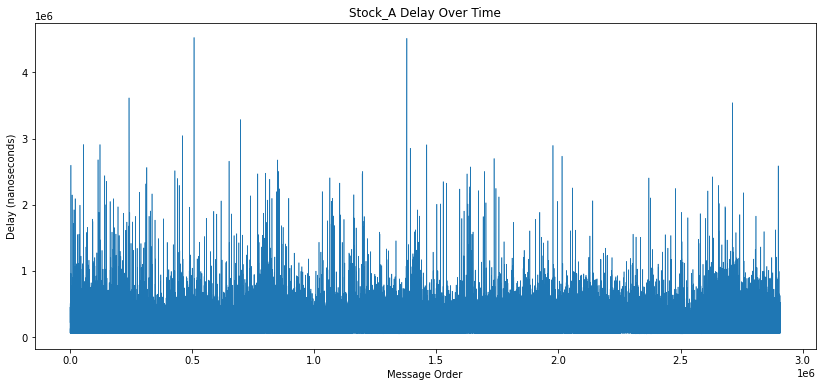

In [85]:
df_a = features_train[(features_train['stock'] == 'A') & (features_train["row_number_in_day"] > 1000)]


plt.figure(figsize=(14,6))

plt.plot(
    np.arange(len(df_a)),
    df_a["delay"],
    linewidth=0.6
)

plt.xlabel("Message Order")
plt.ylabel("Delay (nanoseconds)")
plt.title("Stock_A Delay Over Time")
plt.show()

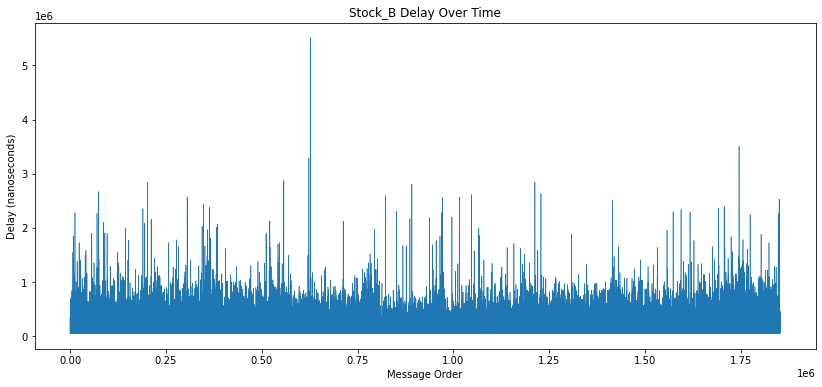

In [87]:
df_b = features_train[(features_train['stock'] == 'B') & (features_train["row_number_in_day"] > 1000)]


plt.figure(figsize=(14,6))

plt.plot(
    np.arange(len(df_b)),
    df_b["delay"],
    linewidth=0.6
)

plt.xlabel("Message Order")
plt.ylabel("Delay (nanoseconds)")
plt.title("Stock_B Delay Over Time")
plt.show()

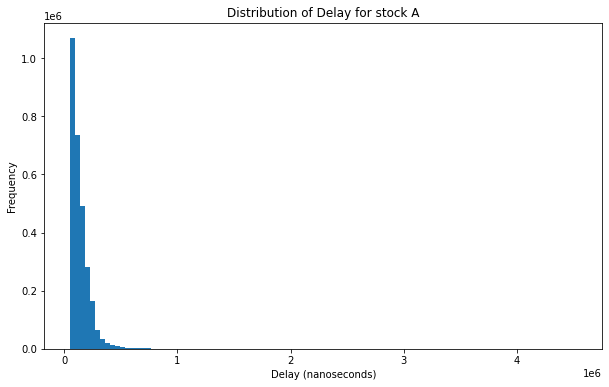

In [88]:
plt.figure(figsize=(10,6))

plt.hist(
    df_a["delay"],
    bins=100
)

plt.xlabel("Delay (nanoseconds)")
plt.ylabel("Frequency")
plt.title("Distribution of Delay for stock A")
plt.show()

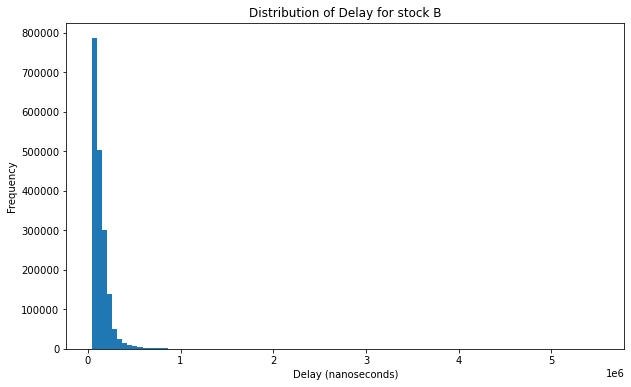

In [89]:
plt.figure(figsize=(10,6))

plt.hist(
    df_b["delay"],
    bins=100
)

plt.xlabel("Delay (nanoseconds)")
plt.ylabel("Frequency")
plt.title("Distribution of Delay for stock B")
plt.show()

In [91]:
from scipy import stats

transformed_delay, best_lambda = stats.boxcox(df_a["delay"])

print("Best Box-Cox lambda (stock A):", best_lambda)

Best Box-Cox lambda (stock A): -0.6347616836997211


In [92]:
transformed_delay, best_lambda = stats.boxcox(df_b["delay"])

print("Best Box-Cox lambda (stock B):", best_lambda)

Best Box-Cox lambda (stock B): -0.6304251095110015


In [93]:
df_a["delay"].describe()
#Stock_A RMSE: 46140.24811376722



count    1.852726e+06
mean     1.372113e+05
std      9.656795e+04
min      4.353500e+04
25%      7.376925e+04
50%      1.128990e+05
75%      1.678600e+05
max      5.513532e+06
Name: delay, dtype: float64

In [94]:
df_b["delay"].describe()
#Stock_B RMSE: 47508.394542438495

count    1.852726e+06
mean     1.372113e+05
std      9.656795e+04
min      4.353500e+04
25%      7.376925e+04
50%      1.128990e+05
75%      1.678600e+05
max      5.513532e+06
Name: delay, dtype: float64

<span style="font-size:18px;">

### Distribution of Delay (Stock A and Stock B)

The distribution of delay for Stock A and stock B is highly right-skewed (positively skewed).

Most observations are concentrated around relatively small delay values, while a small number of observations contain extremely large delays. This creates a long right tail extending toward several million nanoseconds.

Key observations:

- the majority of delays are relatively low
- extreme latency spikes occur infrequently
- the distribution is not symmetric
- variance increases because of large outliers
- the target variable is clearly non-normal

This type of distribution is common in latency and high-frequency trading data, where network conditions are usually stable but occasionally experience large congestion spikes.

The histogram also suggests:
- heavy-tailed behavior
- presence of outliers
- heteroscedasticity (non-constant variability)

Because of this strong skewness, applying a target transformation such as:

```python
log1p(delay) ~ ln(delay+1)
```

where:
- `log` is the natural logarithm
- `1 +` is added to safely handle zero values


was appropriate. The log transformation:
- reduces skewness
- compresses extreme values
- stabilizes variance
- improves model training stability

At the same time, `log1p()` preserves important differences between large delay observations better than stronger transformations such as Box-Cox with λ = −0.63.

</span>


## 3.  XGBoost Model

<span style="font-size:15px;">

### XGBoost Model Development and Feature Selection

Since the target variable (`delay`) is highly skewed and contains significant outliers, I decided to use tree-based models rather than distance-based models such as KNN or standard Linear Regression.

Distance-based models are sensitive to:
- outliers
- skewed distributions
- non-linear relationships
- highly correlated predictors

In contrast, XGBoost handles:
- non-linear interactions
- outliers
- correlated features
- large tabular datasets

very effectively.

Another advantage of XGBoost is that it provides built-in feature importance scores, which allowed me to perform recursive feature selection and reduce model complexity.

---

### Step 1 — Baseline XGBoost Model Using All Features

First, I trained an XGBoost model using all available engineered predictors (78 features).

Training:
- first 9 trading days

Testing:
- 10th trading day (April 17, 2026)

Evaluation metric:
- MSE
- RMSE

Results:

#### Stock A
- MSE: `2,153,242,112`
- RMSE: `46,403.04`

#### Stock B
- MSE: `2,266,337,536`
- RMSE: `47,606.07`

#### Overall
- MSE: `2,199,068,160`
- RMSE: `46,894.22`

This served as the baseline model.

---

### Step 2 — Feature Importance Analysis and Top-40 Feature Model

Next, I examined the feature importance rankings produced by XGBoost.

I selected the top 40 most important predictors and also analyzed their correlation matrix to identify highly correlated variables.

Then, I retrained the XGBoost model using only these 40 features.

Results:

#### Stock A
- MSE: `2,138,851,328`
- RMSE: `46,247.72`

RMSE decreased compared to the full 78-feature model.

#### Stock B
- MSE: `2,267,526,656`
- RMSE: `47,618.55`

RMSE increased slightly compared to the full model.

#### Overall
- MSE: `2,190,990,336`
- RMSE: `46,808.02`

Overall RMSE improved compared to the baseline model.

This suggested that removing less informative features helped reduce noise and mild overfitting.

---

### Step 3 — Top-20 Feature Model

After observing improvement with 40 features, I tested a smaller model using only the top 20 predictors from the feature importance rankings.

Again, I calculated the correlation matrix and retrained the model.

Results:

#### Stock A
- MSE: `2,224,960,000`
- RMSE: `47,169.48`

#### Stock B
- MSE: `2,322,011,136`
- RMSE: `48,187.25`

#### Overall
- MSE: `2,264,285,184`
- RMSE: `47,584.51`

Performance worsened significantly compared to the 40-feature model.

This indicated that reducing the feature set too aggressively removed important predictive information.

---

### Step 4 — Automated Recursive Feature Selection

After manually testing different feature counts, I developed an automated recursive feature selection pipeline.

The idea was:
1. Train a model
2. Extract feature importance rankings
3. Select the top N features
4. Retrain the model
5. Evaluate RMSE
6. Repeat for different feature counts

This automated process allowed me to systematically compare models with:
- 20 features
- 30 features
- 40 features
- 50 features
- 60 features

and identify the feature subset that minimized RMSE.

This became one of the most important improvements in the final solution.

</span>

In [32]:
import os
import gc
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor


WARMUP = 1000

In [33]:
def create_model(random_state=42):
  return XGBRegressor(
            n_estimators=700,
            learning_rate=0.03,
            max_depth=7,
            subsample=0.85,
            colsample_bytree=0.85,
            reg_alpha=0.1,
            reg_lambda=0.3,
            objective="reg:squarederror",
            tree_method="hist",
            device="cuda",
            random_state=random_state,
            n_jobs=-1)



In [34]:

#drop first 1000 rows 

mask_A = (
    (features_train["row_number_in_day"] > WARMUP) &
    (features_train["stock"] == "A")
)

X_train_A = features_train.loc[mask_A, feature_cols].astype("float32")
y_train_A = np.log1p(features_train.loc[mask_A, "delay"].astype("float32"))

print("X_train_A:", X_train_A.shape)
print("y_train_A:", y_train_A.shape)

model_A = create_model(random_state=42)
model_A.fit(X_train_A, y_train_A)

print("Model A trained.")

del X_train_A, y_train_A, mask_A
gc.collect()



X_train_A: (2908399, 78)
y_train_A: (2908399,)
[21:51:53] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1645117948562/work/src/learner.cc:576: 
Parameters: { "device" } might not be used.

  This could be a false alarm, with some parameters getting used by language bindings but
  then being mistakenly passed down to XGBoost core, or some parameter actually being used
  but getting flagged wrongly here. Please open an issue if you find any such cases.


Model A trained.


45

In [35]:
print(type(model_A))

<class 'xgboost.sklearn.XGBRegressor'>


In [28]:
mask_B = (
    (features_train["row_number_in_day"] > WARMUP) &
    (features_train["stock"] == "B")
)

X_train_B = features_train.loc[mask_B, feature_cols].astype("float32")
y_train_B = np.log1p(features_train.loc[mask_B, "delay"].astype("float32"))

print("X_train_B:", X_train_B.shape)
print("y_train_B:", y_train_B.shape)

model_B = create_model(random_state=42)
model_B.fit(X_train_B, y_train_B)

print("Model B trained.")

del X_train_B, y_train_B, mask_B
gc.collect()


X_train_B: (1852726, 78)
y_train_B: (1852726,)
[18:38:56] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1645117948562/work/src/learner.cc:576: 
Parameters: { "device" } might not be used.

  This could be a false alarm, with some parameters getting used by language bindings but
  then being mistakenly passed down to XGBoost core, or some parameter actually being used
  but getting flagged wrongly here. Please open an issue if you find any such cases.


Model B trained.


37

In [29]:
print(type(model_B))

<class 'xgboost.sklearn.XGBRegressor'>


In [29]:

base_dir = "/Users/kamila/Desktop/Barak capital/home_test_Barak"
test_stock_a = base_dir + "/Stock_A_20260415.csv"
test_stock_b = base_dir + "/Stock_B_20260415.csv"

import os
import glob
import argparse
import numpy as np
import pandas as pd
from collections import deque


WARMUP = 1000


def extract_date(path):
    base = os.path.basename(path)
    digits = "".join([c for c in base if c.isdigit()])
    return digits[:8]




def find_matching_files(stock_a_dir, stock_b_dir):
    a_files = sorted(glob.glob(os.path.join(stock_a_dir, "*.csv")))
    b_files = sorted(glob.glob(os.path.join(stock_b_dir, "*.csv")))

    a_by_date = {extract_date(f): f for f in a_files}
    b_by_date = {extract_date(f): f for f in b_files}

    common_dates = sorted(set(a_by_date) & set(b_by_date))

    pairs = []
    for d in common_dates:
        pairs.append((d, a_by_date[d], b_by_date[d]))

    return pairs


def load_csv(path):
    df = pd.read_csv(path)
    df["sending_time"] = df["sending_time"].astype("int64")
    df["arrival_time"] = df["arrival_time"].astype("int64")
    return df


def add_delay(df):
    df = df.copy()
    df["delay"] = df["arrival_time"] - df["sending_time"]
    return df


def encode_message_type(x):
    return 1 if x == "MarketChange" else 0


def build_features_for_one_day_fast(df_a, df_b, date, day_id):
    df_a = add_delay(df_a)
    df_b = add_delay(df_b)

    df_a = add_own_features(df_a)
    df_b = add_own_features(df_b)

    df_a["stock"] = "A"
    df_b["stock"] = "B"

    first_arrival_time = min(df_a["arrival_time"].min(), df_b["arrival_time"].min())

    df_a["seconds_from_day_start"] = (df_a["arrival_time"] - first_arrival_time) / 1_000_000_000
    df_b["seconds_from_day_start"] = (df_b["arrival_time"] - first_arrival_time) / 1_000_000_000

    df_a["minutes_from_day_start"] = df_a["seconds_from_day_start"] / 60
    df_b["minutes_from_day_start"] = df_b["seconds_from_day_start"] / 60

    df_a["date"] = date
    df_b["date"] = date
    df_a["day_id"] = day_id
    df_b["day_id"] = day_id

    state_a = make_state_features_for_other_channel(df_a)
    state_b = make_state_features_for_other_channel(df_b)

    df_a = pd.merge_asof(
        df_a.sort_values("arrival_time"),
        state_b.sort_values("arrival_time"),
        on="arrival_time",
        direction="backward",
        allow_exact_matches=False
    )

    df_b = pd.merge_asof(
        df_b.sort_values("arrival_time"),
        state_a.sort_values("arrival_time"),
        on="arrival_time",
        direction="backward",
        allow_exact_matches=False
    )

    features_day = pd.concat([df_a, df_b], ignore_index=True)
    features_day = features_day.sort_values(["arrival_time", "stock"]).reset_index(drop=True)

    return features_day.fillna(0)



df_test_a = load_csv(test_stock_a)
df_test_b = load_csv(test_stock_b)

features_test = build_features_for_one_day_fast(
    df_a=df_test_a,
    df_b=df_test_b,
    date="test_day",
    day_id=999
)



print("features_test shape:", features_test.shape)

del df_test_a, df_test_b
gc.collect()

features_test shape: (264252, 85)


85

In [36]:
mask_test_A = (
    (features_test["row_number_in_day"] > WARMUP) &
    (features_test["stock"] == "A")
)

X_test_A = features_test.loc[mask_test_A, feature_cols].astype("float32")
y_test_A = features_test.loc[mask_test_A, "delay"].astype("float32")

pred_log_A = model_A.predict(X_test_A)
pred_A = np.expm1(pred_log_A)
pred_A = np.maximum(pred_A, 0)

mse_A = mean_squared_error(y_test_A, pred_A)
rmse_A = np.sqrt(mse_A)

print("Stock_A MSE:", mse_A)
print("Stock_A RMSE:", rmse_A)

Stock_A MSE: 2153242112.0
Stock_A RMSE: 46403.039900420314


In [32]:
mask_test_B = (
    (features_test["row_number_in_day"] > WARMUP) &
    (features_test["stock"] == "B")
)

X_test_B = features_test.loc[mask_test_B, feature_cols].astype("float32")
y_test_B = features_test.loc[mask_test_B, "delay"].astype("float32")

pred_log_B = model_B.predict(X_test_B)
pred_B = np.expm1(pred_log_B)
pred_B = np.maximum(pred_B, 0)

mse_B = mean_squared_error(y_test_B, pred_B)
rmse_B = np.sqrt(mse_B)

print("Stock_B MSE:", mse_B)
print("Stock_B RMSE:", rmse_B)

Stock_B MSE: 2266337536.0
Stock_B RMSE: 47606.066168084086


In [33]:
y_all = np.concatenate([
    y_test_A.values,
    y_test_B.values
])

pred_all = np.concatenate([
    pred_A,
    pred_B
])

overall_mse = mean_squared_error(y_all, pred_all)
overall_rmse = np.sqrt(overall_mse)

print("Overall MSE:", overall_mse)
print("Overall RMSE:", overall_rmse)

Overall MSE: 2199068160.0
Overall RMSE: 46894.223098373215


In [34]:
import matplotlib.pyplot as plt

importance_A = pd.DataFrame({
    "feature": feature_cols,
    "importance": model_A.feature_importances_
}).sort_values("importance", ascending=False)


In [35]:
import matplotlib.pyplot as plt

importance_B = pd.DataFrame({
    "feature": feature_cols,
    "importance": model_B.feature_importances_
}).sort_values("importance", ascending=False)

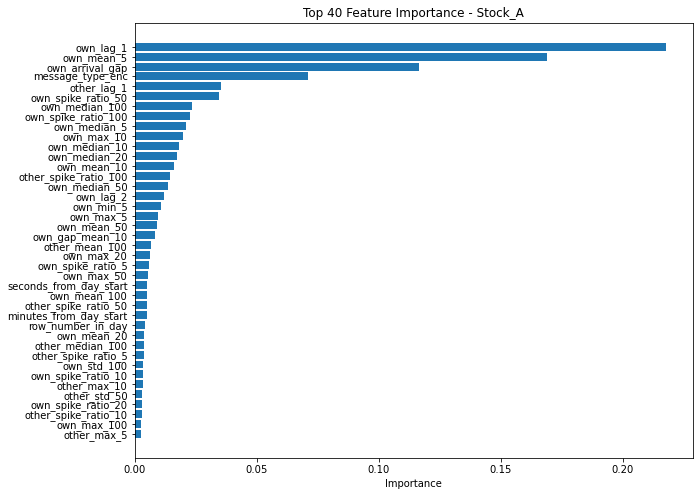

In [36]:
plt.figure(figsize=(10, 8))
plt.barh(
    importance_A["feature"].head(40),
    importance_A["importance"].head(40)
)
plt.gca().invert_yaxis()
plt.title("Top 40 Feature Importance - Stock_A")
plt.xlabel("Importance")
plt.show()

In [37]:
print(list(importance_A["feature"].head(40)))

['own_lag_1', 'own_mean_5', 'own_arrival_gap', 'message_type_enc', 'other_lag_1', 'own_spike_ratio_50', 'own_median_100', 'own_spike_ratio_100', 'own_median_5', 'own_max_10', 'own_median_10', 'own_median_20', 'own_mean_10', 'other_spike_ratio_100', 'own_median_50', 'own_lag_2', 'own_min_5', 'own_max_5', 'own_mean_50', 'own_gap_mean_10', 'other_mean_100', 'own_max_20', 'own_spike_ratio_5', 'own_max_50', 'seconds_from_day_start', 'own_mean_100', 'other_spike_ratio_50', 'minutes_from_day_start', 'row_number_in_day', 'own_mean_20', 'other_median_100', 'other_spike_ratio_5', 'own_std_100', 'own_spike_ratio_10', 'other_max_10', 'other_std_50', 'own_spike_ratio_20', 'other_spike_ratio_10', 'own_max_100', 'other_max_5']


In [38]:

import matplotlib.pyplot as plt
import pandas as pd

# Top 40 most important features from Stock_A
top_features = list(importance_A["feature"].head(40))

print(top_features)

# Use only top important features
corr_df = features_train[ features_train["stock"] == "A"][top_features].copy()


correlation_matrix = corr_df.corr()

print(correlation_matrix)

['own_lag_1', 'own_mean_5', 'own_arrival_gap', 'message_type_enc', 'other_lag_1', 'own_spike_ratio_50', 'own_median_100', 'own_spike_ratio_100', 'own_median_5', 'own_max_10', 'own_median_10', 'own_median_20', 'own_mean_10', 'other_spike_ratio_100', 'own_median_50', 'own_lag_2', 'own_min_5', 'own_max_5', 'own_mean_50', 'own_gap_mean_10', 'other_mean_100', 'own_max_20', 'own_spike_ratio_5', 'own_max_50', 'seconds_from_day_start', 'own_mean_100', 'other_spike_ratio_50', 'minutes_from_day_start', 'row_number_in_day', 'own_mean_20', 'other_median_100', 'other_spike_ratio_5', 'own_std_100', 'own_spike_ratio_10', 'other_max_10', 'other_std_50', 'own_spike_ratio_20', 'other_spike_ratio_10', 'own_max_100', 'other_max_5']
                        own_lag_1  own_mean_5  own_arrival_gap  \
own_lag_1                1.000000    0.776891        -0.068358   
own_mean_5               0.776891    1.000000        -0.058444   
own_arrival_gap         -0.068358   -0.058444         1.000000   
message_type_e

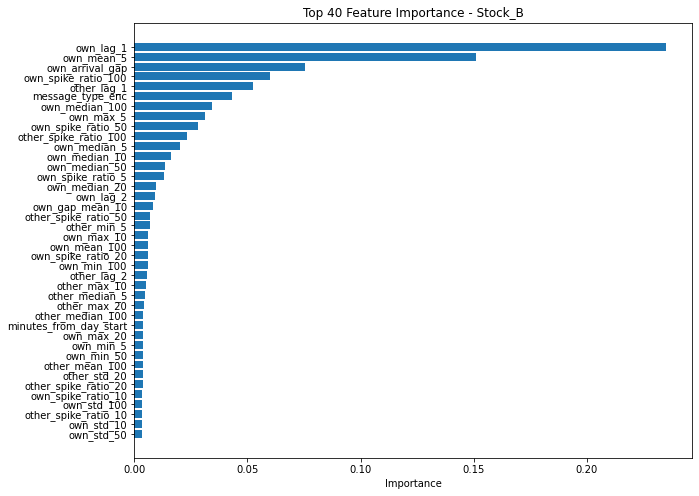

In [39]:
plt.figure(figsize=(10, 8))
plt.barh(
    importance_B["feature"].head(40),
    importance_B["importance"].head(40)
)
plt.gca().invert_yaxis()
plt.title("Top 40 Feature Importance - Stock_B")
plt.xlabel("Importance")
plt.show()

In [40]:
print(list(importance_B["feature"].head(40)))

['own_lag_1', 'own_mean_5', 'own_arrival_gap', 'own_spike_ratio_100', 'other_lag_1', 'message_type_enc', 'own_median_100', 'own_max_5', 'own_spike_ratio_50', 'other_spike_ratio_100', 'own_median_5', 'own_median_10', 'own_median_50', 'own_spike_ratio_5', 'own_median_20', 'own_lag_2', 'own_gap_mean_10', 'other_spike_ratio_50', 'other_min_5', 'own_max_10', 'own_mean_100', 'own_spike_ratio_20', 'own_min_100', 'other_lag_2', 'other_max_10', 'other_median_5', 'other_max_20', 'other_median_100', 'minutes_from_day_start', 'own_max_20', 'own_min_5', 'own_min_50', 'other_mean_100', 'other_std_20', 'other_spike_ratio_20', 'own_spike_ratio_10', 'own_std_100', 'other_spike_ratio_10', 'own_std_10', 'own_std_50']


In [41]:

import matplotlib.pyplot as plt
import pandas as pd

# Top 40 most important features from Stock_B
top_features = list(importance_B["feature"].head(40))

print(top_features)


# Use only top important features
corr_df = features_train[ features_train["stock"] == "B"][top_features].copy()

correlation_matrix = corr_df.corr()

print(correlation_matrix)

['own_lag_1', 'own_mean_5', 'own_arrival_gap', 'own_spike_ratio_100', 'other_lag_1', 'message_type_enc', 'own_median_100', 'own_max_5', 'own_spike_ratio_50', 'other_spike_ratio_100', 'own_median_5', 'own_median_10', 'own_median_50', 'own_spike_ratio_5', 'own_median_20', 'own_lag_2', 'own_gap_mean_10', 'other_spike_ratio_50', 'other_min_5', 'own_max_10', 'own_mean_100', 'own_spike_ratio_20', 'own_min_100', 'other_lag_2', 'other_max_10', 'other_median_5', 'other_max_20', 'other_median_100', 'minutes_from_day_start', 'own_max_20', 'own_min_5', 'own_min_50', 'other_mean_100', 'other_std_20', 'other_spike_ratio_20', 'own_spike_ratio_10', 'own_std_100', 'other_spike_ratio_10', 'own_std_10', 'own_std_50']
                        own_lag_1  own_mean_5  own_arrival_gap  \
own_lag_1                1.000000    0.757399        -0.066810   
own_mean_5               0.757399    1.000000        -0.055413   
own_arrival_gap         -0.066810   -0.055413         1.000000   
own_spike_ratio_100      0.9

### a) Run model using 40 feautures

In [18]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
import numpy as np
import gc


def create_xgb_model(random_state=42):
    return XGBRegressor(
        n_estimators=700,
        learning_rate=0.03,
        max_depth=7,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_alpha=0.1,
        reg_lambda=0.3,
        objective="reg:squarederror",
        tree_method="hist",
        device="cuda",
        random_state=random_state,
        n_jobs=-1
    )




def train_predict_one_stock(
    features_train,
    features_test,
    stock,
    selected_features,
    random_state=42,
    warmup=1000,
    use_log_target=True
):
    # Training masks
    train_mask = (
        (features_train["row_number_in_day"] > warmup) &
        (features_train["stock"] == stock)
    )

    test_mask = (
        (features_test["row_number_in_day"] > warmup) &
        (features_test["stock"] == stock)
    )

    # Prepare training data
    X_train = features_train.loc[train_mask, selected_features].astype("float32")
    y_train_raw = features_train.loc[train_mask, "delay"].astype("float32")

    if use_log_target:
        y_train = np.log1p(y_train_raw)
    else:
        y_train = y_train_raw

    # Prepare test data
    X_test = features_test.loc[test_mask, selected_features].astype("float32")
    y_test = features_test.loc[test_mask, "delay"].astype("float32")

    print(f"Stock {stock}")
    print("X_train:", X_train.shape)
    print("X_test:", X_test.shape)

    # Train
    model = create_xgb_model(random_state=random_state)
    model.fit(X_train, y_train)

    # Predict
    pred = model.predict(X_test)

    if use_log_target:
        pred = np.expm1(pred)

    pred = np.maximum(pred, 0)

    # Metrics
    mse = mean_squared_error(y_test, pred)
    rmse = np.sqrt(mse)

    print(f"Stock_{stock} MSE:", mse)
    print(f"Stock_{stock} RMSE:", rmse)

    # Results dataframe
    results = features_test.loc[
        test_mask,
        ["sending_time", "arrival_time", "delay"]
    ].copy()

    results["prediction"] = pred
    results["error"] = results["prediction"] - results["delay"]
    results["abs_error"] = results["error"].abs()

    # Cleanup
    del X_train, y_train_raw, y_train, X_test, y_test
    gc.collect()

    return model, results, mse, rmse

In [19]:
features_A_40 = [
    'own_mean_5', 'own_lag_1', 'own_arrival_gap', 'own_spike_ratio_100',
    'message_type_enc', 'other_lag_1', 'own_mean_10', 'own_spike_ratio_50',
    'own_max_5', 'own_max_10', 'own_median_100', 'own_min_5',
    'own_median_5', 'own_median_20', 'other_spike_ratio_100',
    'own_median_50', 'own_lag_2', 'own_mean_100', 'own_gap_mean_10',
    'own_median_10', 'other_spike_ratio_50', 'own_spike_ratio_5',
    'own_mean_50', 'own_max_20', 'other_mean_100', 'own_max_50',
    'minutes_from_day_start', 'seconds_from_day_start', 'row_number_in_day',
    'own_spike_ratio_20', 'other_median_100', 'other_max_5',
    'own_mean_20', 'own_max_100', 'own_std_100', 'own_spike_ratio_10',
    'other_std_50', 'other_spike_ratio_20', 'other_spike_ratio_5',
    'other_min_100'
]

features_B_40 = [
    'own_lag_1', 'own_mean_5', 'own_arrival_gap', 'other_lag_1',
    'message_type_enc', 'own_median_100', 'own_spike_ratio_100',
    'other_spike_ratio_100', 'own_median_10', 'own_spike_ratio_50',
    'own_max_5', 'own_median_5', 'own_median_50', 'own_lag_2',
    'own_median_20', 'other_spike_ratio_50', 'own_gap_mean_10',
    'own_mean_10', 'other_mean_5', 'other_min_5', 'own_min_100',
    'other_max_5', 'own_spike_ratio_20', 'own_spike_ratio_5',
    'own_mean_100', 'other_lag_2', 'other_max_10',
    'minutes_from_day_start', 'other_median_100', 'own_max_10',
    'own_min_50', 'other_median_5', 'own_max_20',
    'seconds_from_day_start', 'own_mean_50', 'other_mean_100',
    'own_max_50', 'own_spike_ratio_10', 'own_std_100', 'own_std_10'
]

In [20]:
model_A_40, results_A_40, mse_A_40, rmse_A_40 = train_predict_one_stock(
    features_train=features_train,
    features_test=features_test,
    stock="A",
    selected_features=features_A_40,
    random_state=42,
    warmup=1000,
    use_log_target=True
)

model_B_40, results_B_40, mse_B_40, rmse_B_40 = train_predict_one_stock(
    features_train=features_train,
    features_test=features_test,
    stock="B",
    selected_features=features_B_40,
    random_state=42,
    warmup=1000,
    use_log_target=True
)

Stock A
X_train: (2908399, 40)
X_test: (155988, 40)
[18:33:59] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1645117948562/work/src/learner.cc:576: 
Parameters: { "device" } might not be used.

  This could be a false alarm, with some parameters getting used by language bindings but
  then being mistakenly passed down to XGBoost core, or some parameter actually being used
  but getting flagged wrongly here. Please open an issue if you find any such cases.


Stock_A MSE: 2138851328.0
Stock_A RMSE: 46247.7170031127
Stock B
X_train: (1852726, 40)
X_test: (106264, 40)
[18:34:30] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1645117948562/work/src/learner.cc:576: 
Parameters: { "device" } might not be used.

  This could be a false alarm, with some parameters getting used by language bindings but
  then being mistakenly passed down to XGBoost core, or some parameter actually being used
  but getting flagged wrongly here. Please open an issue if you find any such case

In [21]:
overall_y = np.concatenate([
    results_A_40["delay"].values,
    results_B_40["delay"].values
])

overall_pred = np.concatenate([
    results_A_40["prediction"].values,
    results_B_40["prediction"].values
])

overall_mse = mean_squared_error(overall_y, overall_pred)
overall_rmse = np.sqrt(overall_mse)

print("Overall MSE:", overall_mse)
print("Overall RMSE:", overall_rmse)

Overall MSE: 2190990336.0
Overall RMSE: 46808.015723805256


In [22]:
import matplotlib.pyplot as plt

def feauture_importance(model, feature_cols, n, stock):

  importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": model.feature_importances_
    }).sort_values("importance", ascending=False)

  plt.figure(figsize=(10, 8))
  plt.barh(
    importance_df["feature"].head(n),
    importance_df["importance"].head(n)
    )

  plt.gca().invert_yaxis()
  plt.title(f"Top {n} Feature Importance - Stock {stock}")
  plt.xlabel("Importance")
  plt.show()

  return list(importance_df["feature"].head(n))



def correlation_matrix(data, stock, top_features, threshold=0.95):
    # Filter only one stock
    corr_df = data[
        data["stock"] == stock
    ][top_features].copy()

    # Correlation matrix
    corr = corr_df.corr()

    print("Features used:", len(top_features))
    print("Matrix shape:", corr.shape)
    print("\nFull Correlation Matrix:\n")
    print(corr)

    # -----------------------------------
    # Find highly correlated feature pairs
    # -----------------------------------
    high_corr_pairs = []

    for i in range(len(top_features)):
        for j in range(i + 1, len(top_features)):
            corr_value = corr.iloc[i, j]

            if abs(corr_value) >= threshold:
                high_corr_pairs.append([
                    top_features[i],
                    top_features[j],
                    round(corr_value, 4)
                ])

    high_corr_df = pd.DataFrame(
        high_corr_pairs,
        columns=[
            "Feature_1",
            "Feature_2",
            "Correlation"
        ]
    )

    if len(high_corr_df) > 0:
        high_corr_df = high_corr_df.sort_values(
            by="Correlation",
            ascending=False
        )

        print(f"\nFeature pairs with |correlation| >= {threshold}:\n")
        display(high_corr_df)

    else:
        print(f"\nNo feature pairs found with |correlation| >= {threshold}")





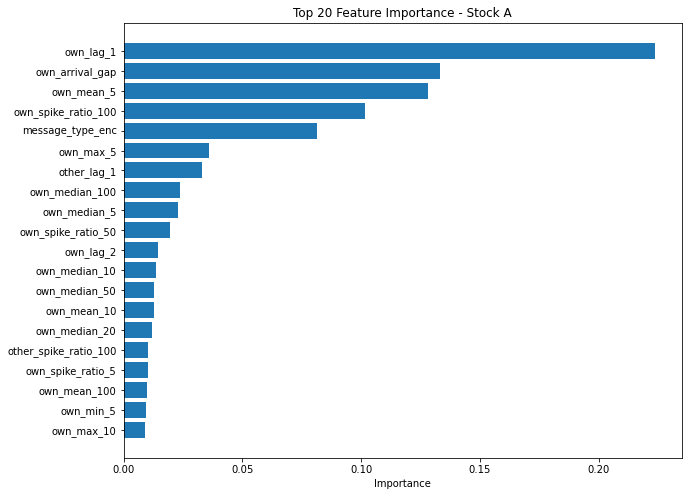

Features used: 20
Matrix shape: (20, 20)

Full Correlation Matrix:

                       own_lag_1  own_arrival_gap  own_mean_5  \
own_lag_1               1.000000        -0.068358    0.776891   
own_arrival_gap        -0.068358         1.000000   -0.058444   
own_mean_5              0.776891        -0.058444    1.000000   
own_spike_ratio_100     0.905561        -0.067615    0.602146   
message_type_enc       -0.025633        -0.006677   -0.008080   
own_max_5               0.702457        -0.056807    0.919941   
other_lag_1             0.363110        -0.038781    0.405527   
own_median_100          0.223178        -0.022035    0.290845   
own_median_5            0.733059        -0.056040    0.962068   
own_spike_ratio_50      0.854347        -0.066620    0.513201   
own_lag_2               0.710706        -0.052523    0.847706   
own_median_10           0.588455        -0.048050    0.858274   
own_median_50           0.280895        -0.029454    0.380702   
own_mean_10           

,Feature_1,Feature_2,Correlation
1,own_spike_ratio_100,own_spike_ratio_50,0.9625
0,own_mean_5,own_median_5,0.9621
2,own_median_10,own_mean_10,0.9588


In [23]:

top_featuresA = feauture_importance(model_A_40, features_A_40, 20, 'A')
correlation_matrix(features_train, 'A', top_featuresA)

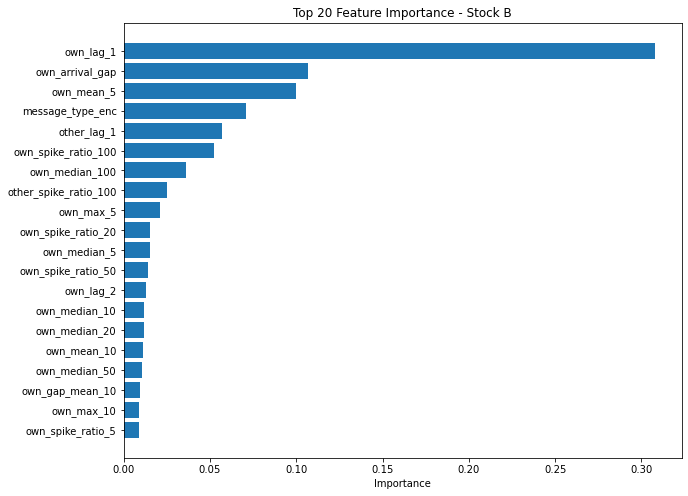

Features used: 20
Matrix shape: (20, 20)

Full Correlation Matrix:

                       own_lag_1  own_arrival_gap  own_mean_5  \
own_lag_1               1.000000        -0.066810    0.757399   
own_arrival_gap        -0.066810         1.000000   -0.055413   
own_mean_5              0.757399        -0.055413    1.000000   
message_type_enc       -0.037579        -0.003737   -0.026530   
other_lag_1             0.442875        -0.071969    0.436236   
own_spike_ratio_100     0.907140        -0.059277    0.593130   
own_median_100          0.252009        -0.042563    0.326757   
other_spike_ratio_100   0.392822        -0.060374    0.370350   
own_max_5               0.678195        -0.052044    0.910210   
own_spike_ratio_20      0.772787        -0.054261    0.346688   
own_median_5            0.706532        -0.052479    0.954128   
own_spike_ratio_50      0.867126        -0.058224    0.517218   
own_lag_2               0.690431        -0.051449    0.835553   
own_median_10         

,Feature_1,Feature_2,Correlation
1,own_spike_ratio_100,own_spike_ratio_50,0.9643
0,own_mean_5,own_median_5,0.9541


In [24]:

top_featuresB = feauture_importance(model_B_40, features_B_40, 20, 'B')
correlation_matrix(features_train, 'B', top_featuresB)

### b) XGBoost Model with 20 features

In [25]:
model_A_20, results_A_20, mse_A_20, rmse_A_20 = train_predict_one_stock(
    features_train=features_train,
    features_test=features_test,
    stock="A",
    selected_features=top_featuresA,
    random_state=42,
    warmup=1000,
    use_log_target=True
)

model_B_20, results_B_20, mse_B_20, rmse_B_20 = train_predict_one_stock(
    features_train=features_train,
    features_test=features_test,
    stock="B",
    selected_features=top_featuresB,
    random_state=42,
    warmup=1000,
    use_log_target=True
)

overall_y = np.concatenate([
    results_A_20["delay"].values,
    results_B_20["delay"].values
])

overall_pred = np.concatenate([
    results_A_20["prediction"].values,
    results_B_20["prediction"].values
])

overall_mse = mean_squared_error(overall_y, overall_pred)
overall_rmse = np.sqrt(overall_mse)

print("Overall MSE:", overall_mse)
print("Overall RMSE:", overall_rmse)


Stock A
X_train: (2908399, 20)
X_test: (155988, 20)
[18:35:34] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1645117948562/work/src/learner.cc:576: 
Parameters: { "device" } might not be used.

  This could be a false alarm, with some parameters getting used by language bindings but
  then being mistakenly passed down to XGBoost core, or some parameter actually being used
  but getting flagged wrongly here. Please open an issue if you find any such cases.


Stock_A MSE: 2224960000.0
Stock_A RMSE: 47169.481659225385
Stock B
X_train: (1852726, 20)
X_test: (106264, 20)
[18:35:59] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1645117948562/work/src/learner.cc:576: 
Parameters: { "device" } might not be used.

  This could be a false alarm, with some parameters getting used by language bindings but
  then being mistakenly passed down to XGBoost core, or some parameter actually being used
  but getting flagged wrongly here. Please open an issue if you find any such ca

### c) Choosing number of features based on the lowest RMSE

<span style="font-size:15px;">

### Automated Feature Selection

After manually comparing models with 78, 40, and 20 features, I decided to automate the feature selection process. The goal was to systematically identify the number of predictors that minimized RMSE for each stock, instead of choosing the feature count manually.

I tested two different feature selection approaches.

---

### Method 1 — Top-N Features from Full Model Importance

In the first approach, I trained a full model using all available features and extracted feature importance from that full model.

Then, for each value of `n` in:

```python
feature_counts = [20, 30, 40, 50, 60]
```

I selected the top `n` features from the full-model feature importance ranking.

The process was:

1. Train a full XGBoost model using all predictors.
2. Extract feature importance separately for Stock A and Stock B.
3. Select the top `n` most important features from the full model.
4. Retrain separate models for Stock A and Stock B using only these selected features.
5. Calculate Stock A RMSE, Stock B RMSE, and overall RMSE.
6. Store the best feature set separately for each stock.

This method allowed me to compare different model sizes while keeping the feature ranking fixed based on the original full model.

The main advantage of this method is that it is simple, stable, and easy to interpret.

However, one limitation is that feature importance can change after removing some predictors. Therefore, the top features from the full model may not always remain the best features after the model is retrained on a smaller feature subset.

---

### Method 2 — Recursive Feature Selection

In the second approach, I used a recursive feature selection method.

Instead of always selecting features from the original full-model importance ranking, I updated feature importance after every retraining step.

The process was:

1. Train the full model using all features.
2. Extract feature importance.
3. Select the top `n` features.
4. Retrain the model using only those top `n` features.
5. Extract a new feature importance ranking from the retrained model.
6. Repeat the process for the next smaller feature count.

For example, I tested:

```python
feature_counts = [60, 50, 40, 30, 20]
```

At each step, the selected features were based on the most recent retrained model, not only on the original full model.

This made the process more adaptive because the model could re-rank features after less useful or redundant features were removed.

---

### Difference Between the Two Methods

The main difference between the two methods is how feature importance is used.

### Method 1

Uses the feature importance from the original full model for all feature counts.

This means the feature ranking stays fixed.

### Method 2

Recalculates feature importance after each retraining step.

This means the feature ranking changes as the feature set becomes smaller.

---

### Why I Tried Both Methods

I tested both methods because feature importance in tree-based models is not fixed. It can change depending on which predictors are included in the model.

For example, if two features are highly correlated, one feature may appear important in the full model, but after removing another correlated variable, its importance may increase or decrease.

Therefore, comparing both approaches helped me understand whether the best feature subset was stable or dependent on the recursive selection process.

---

### Final Reasoning

Automated feature selection improved the modeling process because it allowed me to:

- reduce the number of predictors
- reduce noise from weak features
- compare multiple feature-set sizes systematically
- avoid relying only on manual feature selection
- select different optimal feature sets for Stock A and Stock B

This was important because Stock A and Stock B had different feature importance rankings and different optimal feature counts.

The final selected feature sets were chosen based on the lowest RMSE, not only on feature importance or correlation.

</span>

### 1. From full importnace , then top 20 of full importnace, top 30 of full importnace and so on

In [56]:


import gc
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor

def create_xgb_model(random_state=42):
    return XGBRegressor(
        n_estimators=700,
        learning_rate=0.03,
        max_depth=7,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_alpha=0.1,
        reg_lambda=0.3,
        objective="reg:squarederror",
        tree_method="hist",
        device="cuda",
        random_state=random_state,
        n_jobs=-1
    )



def train_evaluate_stock(
    features_train,
    features_test,
    stock,
    selected_features,
    random_state=42,
    warmup=1000,
    use_log_target=True
):
    train_mask = (
        (features_train["row_number_in_day"] > warmup) &
        (features_train["stock"] == stock)
    )

    test_mask = (
        (features_test["row_number_in_day"] > warmup) &
        (features_test["stock"] == stock)
    )

    X_train = features_train.loc[train_mask, selected_features].astype("float32")
    y_train_raw = features_train.loc[train_mask, "delay"].astype("float32")

    if use_log_target:
        y_train = np.log1p(y_train_raw)
    else:
        y_train = y_train_raw

    X_test = features_test.loc[test_mask, selected_features].astype("float32")
    y_test = features_test.loc[test_mask, "delay"].astype("float32")

    model = create_xgb_model(random_state=random_state)
    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    if use_log_target:
        pred = np.expm1(pred)

    pred = np.maximum(pred, 0)

    mse = mean_squared_error(y_test, pred)
    rmse = np.sqrt(mse)

    importance = pd.DataFrame({
        "feature": selected_features,
        "importance": model.feature_importances_
    }).sort_values("importance", ascending=False)

    results = features_test.loc[
        test_mask,
        ["sending_time", "arrival_time", "delay"]
    ].copy()

    results["prediction"] = pred
    results["error"] = results["prediction"] - results["delay"]
    results["abs_error"] = results["error"].abs()

    del X_train, y_train_raw, y_train, X_test, y_test, pred
    gc.collect()

    return model, importance, results, mse, rmse







In [57]:
def compare_top_n_from_full_importance(
    features_train,
    features_test,
    importance_A_full,
    importance_B_full,
    feature_counts,
    warmup=1000,
    use_log_target=True
):
    rows = []

    best_rmse_A = float("inf")
    best_rmse_B = float("inf")

    best_features_A = None
    best_features_B = None

    best_n_A = None
    best_n_B = None

    for n in feature_counts:
        print("=" * 80)
        print(f"Testing top {n} features from FULL importance")
        print("=" * 80)

        features_A_n = list(importance_A_full["feature"].head(n))
        features_B_n = list(importance_B_full["feature"].head(n))

        model_A, imp_A, res_A, mse_A, rmse_A = train_evaluate_stock(
            features_train=features_train,
            features_test=features_test,
            stock="A",
            selected_features=features_A_n,
            random_state=42,
            warmup=warmup,
            use_log_target=use_log_target
        )

        model_B, imp_B, res_B, mse_B, rmse_B = train_evaluate_stock(
            features_train=features_train,
            features_test=features_test,
            stock="B",
            selected_features=features_B_n,
            random_state=42,
            warmup=warmup,
            use_log_target=use_log_target
        )

        overall_y = np.concatenate([
            res_A["delay"].values,
            res_B["delay"].values
        ])

        overall_pred = np.concatenate([
            res_A["prediction"].values,
            res_B["prediction"].values
        ])

        overall_mse = mean_squared_error(overall_y, overall_pred)
        overall_rmse = np.sqrt(overall_mse)

        if rmse_A < best_rmse_A:
            best_rmse_A = rmse_A
            best_features_A = features_A_n.copy()
            best_n_A = n

        if rmse_B < best_rmse_B:
            best_rmse_B = rmse_B
            best_features_B = features_B_n.copy()
            best_n_B = n

        print(f"Top {n} | Stock_A RMSE: {rmse_A:.4f}")
        print(f"Top {n} | Stock_B RMSE: {rmse_B:.4f}")
        print(f"Top {n} | Overall RMSE: {overall_rmse:.4f}")

        rows.append({
            "n_features": n,
            "stock_A_mse": mse_A,
            "stock_A_rmse": rmse_A,
            "stock_B_mse": mse_B,
            "stock_B_rmse": rmse_B,
            "overall_mse": overall_mse,
            "overall_rmse": overall_rmse
        })

        del model_A, model_B, imp_A, imp_B, res_A, res_B
        gc.collect()

    comparison_df = pd.DataFrame(rows).sort_values("overall_rmse")

    print("\nBest Stock_A feature count:", best_n_A)
    print("Best Stock_A RMSE:", best_rmse_A)
    print("best_features_A:")
    print(best_features_A)

    print("\nBest Stock_B feature count:", best_n_B)
    print("Best Stock_B RMSE:", best_rmse_B)
    print("best_features_B:")
    print(best_features_B)

    return comparison_df, best_features_A, best_features_B

In [58]:
def refine_best_feature_count(
    features_train,
    features_test,
    importance_A_full,
    importance_B_full,
    best_n,
    refined_counts,
    warmup=1000,
    use_log_target=True
):
    print("=" * 80)
    print(f"Refinement step: retrain top {best_n}, get new importance")
    print("=" * 80)

    initial_features_A = list(importance_A_full["feature"].head(best_n))
    initial_features_B = list(importance_B_full["feature"].head(best_n))

    model_A_best, importance_A_refined, results_A_best, mse_A_best, rmse_A_best = train_evaluate_stock(
        features_train=features_train,
        features_test=features_test,
        stock="A",
        selected_features=initial_features_A,
        random_state=42,
        warmup=warmup,
        use_log_target=use_log_target
    )

    model_B_best, importance_B_refined, results_B_best, mse_B_best, rmse_B_best = train_evaluate_stock(
        features_train=features_train,
        features_test=features_test,
        stock="B",
        selected_features=initial_features_B,
        random_state=42,
        warmup=warmup,
        use_log_target=use_log_target
    )

    rows = []

    for n in refined_counts:
        print("=" * 80)
        print(f"Testing refined top {n} features")
        print("=" * 80)

        refined_features_A = list(importance_A_refined["feature"].head(n))
        refined_features_B = list(importance_B_refined["feature"].head(n))

        model_A, imp_A, res_A, mse_A, rmse_A = train_evaluate_stock(
            features_train=features_train,
            features_test=features_test,
            stock="A",
            selected_features=refined_features_A,
            random_state=52,
            warmup=warmup,
            use_log_target=use_log_target
        )

        model_B, imp_B, res_B, mse_B, rmse_B = train_evaluate_stock(
            features_train=features_train,
            features_test=features_test,
            stock="B",
            selected_features=refined_features_B,
            random_state=53,
            warmup=warmup,
            use_log_target=use_log_target
        )

        overall_y = np.concatenate([
            res_A["delay"].values,
            res_B["delay"].values
        ])

        overall_pred = np.concatenate([
            res_A["prediction"].values,
            res_B["prediction"].values
        ])

        overall_mse = mean_squared_error(overall_y, overall_pred)
        overall_rmse = np.sqrt(overall_mse)

        rows.append({
            "refined_n_features": n,
            "stock_A_mse": mse_A,
            "stock_A_rmse": rmse_A,
            "stock_B_mse": mse_B,
            "stock_B_rmse": rmse_B,
            "overall_mse": overall_mse,
            "overall_rmse": overall_rmse
        })

        print(f"Refined top {n} | Stock_A RMSE: {rmse_A:.4f}")
        print(f"Refined top {n} | Stock_B RMSE: {rmse_B:.4f}")
        print(f"Refined top {n} | Overall RMSE: {overall_rmse:.4f}")

        del model_A, model_B, imp_A, imp_B, res_A, res_B
        gc.collect()

    refined_results_df = pd.DataFrame(rows).sort_values("overall_rmse")

    return refined_results_df, importance_A_refined, importance_B_refined

In [59]:
model_A_full, importance_A_full, results_A_full, mse_A_full, rmse_A_full = train_evaluate_stock(
    features_train=features_train,
    features_test=features_test,
    stock="A",
    selected_features=feature_cols,
    random_state=42,
    warmup=1000,
    use_log_target=True
)

model_B_full, importance_B_full, results_B_full, mse_B_full, rmse_B_full = train_evaluate_stock(
    features_train=features_train,
    features_test=features_test,
    stock="B",
    selected_features=feature_cols,
    random_state=42,
    warmup=1000,
    use_log_target=True
)

[19:28:47] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1645117948562/work/src/learner.cc:576: 
Parameters: { "device" } might not be used.

  This could be a false alarm, with some parameters getting used by language bindings but
  then being mistakenly passed down to XGBoost core, or some parameter actually being used
  but getting flagged wrongly here. Please open an issue if you find any such cases.


[19:29:39] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1645117948562/work/src/learner.cc:576: 
Parameters: { "device" } might not be used.

  This could be a false alarm, with some parameters getting used by language bindings but
  then being mistakenly passed down to XGBoost core, or some parameter actually being used
  but getting flagged wrongly here. Please open an issue if you find any such cases.




In [60]:
feature_counts = [20, 30, 40, 50, 60]

comparison_df, best_features_A1, best_features_B1 = compare_top_n_from_full_importance(
    features_train=features_train,
    features_test=features_test,
    importance_A_full=importance_A_full,
    importance_B_full=importance_B_full,
    feature_counts=feature_counts,
    warmup=1000,
    use_log_target=True
)

comparison_df

#best n=50 for A and n = 30 for B as it corresponds to the lowest RMSE and MSE. 
#n=30 stock B RMSE = 47636 which close to n=60 RMSE = 47634, better choose less number of features 

#n=50 for A RMSE = 46140
#n=30 stock B RMSE = 47636



Testing top 20 features from FULL importance
[19:30:25] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1645117948562/work/src/learner.cc:576: 
Parameters: { "device" } might not be used.

  This could be a false alarm, with some parameters getting used by language bindings but
  then being mistakenly passed down to XGBoost core, or some parameter actually being used
  but getting flagged wrongly here. Please open an issue if you find any such cases.


[19:30:49] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1645117948562/work/src/learner.cc:576: 
Parameters: { "device" } might not be used.

  This could be a false alarm, with some parameters getting used by language bindings but
  then being mistakenly passed down to XGBoost core, or some parameter actually being used
  but getting flagged wrongly here. Please open an issue if you find any such cases.


Top 20 | Stock_A RMSE: 47282.6531
Top 20 | Stock_B RMSE: 48196.5071
Top 20 | Overall RMSE: 47655.0512
Testing t

,n_features,stock_A_mse,stock_A_rmse,stock_B_mse,stock_B_rmse,overall_mse,overall_rmse
3,50,2.128922e+09,46140.248114,2.279128e+09,47740.211646,2.189785e+09,46795.142312
2,40,2.139499e+09,46254.715997,2.269959e+09,47644.085803,2.192361e+09,46822.657080
4,60,2.148259e+09,46349.310243,2.268994e+09,47633.953605,2.197180e+09,46874.085634
1,30,2.156335e+09,46436.352656,2.269234e+09,47636.476780,2.202081e+09,46926.336145
0,20,2.235649e+09,47282.653056,2.322903e+09,48196.507093,2.271004e+09,47655.051191


### b) train full model → top 60 → retrain → new importance → top 50 → retrain → new importance → top 40

In [53]:

def train_one_stock(
    features_train,
    features_test,
    stock,
    selected_features,
    random_state=42,
    warmup=1000
):
    train_mask = (
        (features_train["row_number_in_day"] > warmup) &
        (features_train["stock"] == stock)
    )

    test_mask = (
        (features_test["row_number_in_day"] > warmup) &
        (features_test["stock"] == stock)
    )

    X_train = features_train.loc[
        train_mask,
        selected_features
    ].astype("float32")

    y_train = np.log1p(
        features_train.loc[
            train_mask,
            "delay"
        ].astype("float32")
    )

    X_test = features_test.loc[
        test_mask,
        selected_features
    ].astype("float32")

    y_test = features_test.loc[
        test_mask,
        "delay"
    ].astype("float32")

    model = create_xgb_model(random_state=random_state)
    model.fit(X_train, y_train)

    pred = model.predict(X_test)
    pred = np.expm1(pred)
    pred = np.maximum(pred, 0)

    mse = mean_squared_error(y_test, pred)
    rmse = np.sqrt(mse)

    importance = pd.DataFrame({
        "feature": selected_features,
        "importance": model.feature_importances_
    }).sort_values("importance", ascending=False)

    del X_train, X_test, y_train, y_test, pred
    gc.collect()

    return model, importance, mse, rmse



def recursive_feature_selection(
    features_train,
    features_test,
    feature_cols,
    feature_counts=[60, 50, 40, 30, 20],
    warmup=1000
):
    results = []

    # -----------------------------------
    # Store best feature sets separately
    # -----------------------------------
    best_rmse_A = float("inf")
    best_rmse_B = float("inf")

    best_features_A = None
    best_features_B = None

    print("=" * 80)
    print("STEP 1: FULL MODEL TRAINING")
    print("=" * 80)

    # -----------------------------------
    # Initial FULL model
    # -----------------------------------
    model_A, importance_A, mse_A, rmse_A = train_one_stock(
        features_train=features_train,
        features_test=features_test,
        stock="A",
        selected_features=feature_cols,
        random_state=42,
        warmup=warmup
    )

    model_B, importance_B, mse_B, rmse_B = train_one_stock(
        features_train=features_train,
        features_test=features_test,
        stock="B",
        selected_features=feature_cols,
        random_state=42,
        warmup=warmup
    )

    print(f"FULL MODEL A RMSE: {rmse_A:.4f}")
    print(f"FULL MODEL B RMSE: {rmse_B:.4f}")

    # -----------------------------------
    # Recursive shrinking
    # -----------------------------------
    for n in feature_counts:
        print("\n" + "=" * 80)
        print(f"RETRAIN USING TOP {n} FEATURES")
        print("=" * 80)

        # Current feature sets
        features_A = list(
            importance_A["feature"].head(n)
        )

        features_B = list(
            importance_B["feature"].head(n)
        )

        # -------------------------
        # Retrain Stock A
        # -------------------------
        model_A, importance_A, mse_A, rmse_A = train_one_stock(
            features_train=features_train,
            features_test=features_test,
            stock="A",
            selected_features=features_A,
            random_state=42,
            warmup=warmup
        )

        # Save best A features
        if rmse_A < best_rmse_A:
            best_rmse_A = rmse_A
            best_features_A = features_A.copy()

        # -------------------------
        # Retrain Stock B
        # -------------------------
        model_B, importance_B, mse_B, rmse_B = train_one_stock(
            features_train=features_train,
            features_test=features_test,
            stock="B",
            selected_features=features_B,
            random_state=42,
            warmup=warmup
        )

        # Save best B features
        if rmse_B < best_rmse_B:
            best_rmse_B = rmse_B
            best_features_B = features_B.copy()

        avg_rmse = (rmse_A + rmse_B) / 2

        print(f"Stock A RMSE: {rmse_A:.4f}")
        print(f"Stock B RMSE: {rmse_B:.4f}")
        print(f"Average RMSE: {avg_rmse:.4f}")

        results.append({
            "n_features": n,
            "stock_A_mse": mse_A,
            "stock_A_rmse": rmse_A,
            "stock_B_mse": mse_B,
            "stock_B_rmse": rmse_B,
            "avg_rmse": avg_rmse
        })

        gc.collect()

    results_df = pd.DataFrame(results)

    print("\n" + "=" * 80)
    print("BEST FEATURE SETS FOUND")
    print("=" * 80)

    print(f"Best RMSE A: {best_rmse_A:.4f}")
    print(f"Best RMSE B: {best_rmse_B:.4f}")

    print("\nBest Features A:")
    print(best_features_A)

    print("\nBest Features B:")
    print(best_features_B)

    return (
        results_df,
        best_features_A,
        best_features_B
    )

In [54]:
feature_counts = [60, 50, 40, 30, 20]

results_df, best_features_A, best_features_B = recursive_feature_selection(
    features_train=features_train,
    features_test=features_test,
    feature_cols=feature_cols,
    feature_counts=feature_counts,
    warmup=1000
)

STEP 1: FULL MODEL TRAINING
[19:15:17] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1645117948562/work/src/learner.cc:576: 
Parameters: { "device" } might not be used.

  This could be a false alarm, with some parameters getting used by language bindings but
  then being mistakenly passed down to XGBoost core, or some parameter actually being used
  but getting flagged wrongly here. Please open an issue if you find any such cases.


[19:16:06] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1645117948562/work/src/learner.cc:576: 
Parameters: { "device" } might not be used.

  This could be a false alarm, with some parameters getting used by language bindings but
  then being mistakenly passed down to XGBoost core, or some parameter actually being used
  but getting flagged wrongly here. Please open an issue if you find any such cases.


FULL MODEL A RMSE: 46403.0399
FULL MODEL B RMSE: 47606.0662

RETRAIN USING TOP 60 FEATURES
[19:16:41] WARNING: /Users/runner/min

In [55]:
results_df = results_df.sort_values(
    "avg_rmse"
)

display(results_df)

#n=50 for stock A RMSE = 46148 full model RMSE = 46403
#n=40 for stock B RMSE = 47566 full model RMSE = 47606

,n_features,stock_A_mse,stock_A_rmse,stock_B_mse,stock_B_rmse,avg_rmse
2,40,2.143837e+09,46301.583904,2.262517e+09,47565.922592,46933.753248
1,50,2.129626e+09,46147.872237,2.277385e+09,47721.957378,46934.914808
0,60,2.148259e+09,46349.310243,2.268994e+09,47633.953605,46991.631924
3,30,2.152232e+09,46392.153819,2.274853e+09,47695.417642,47043.785730
4,20,2.183706e+09,46730.144104,2.326476e+09,48233.559769,47481.851937


In [61]:
#Method 2
best_features_A

['own_lag_1',
 'own_mean_5',
 'own_arrival_gap',
 'message_type_enc',
 'own_spike_ratio_100',
 'other_lag_1',
 'own_spike_ratio_50',
 'own_mean_10',
 'own_max_5',
 'own_median_100',
 'other_spike_ratio_100',
 'own_median_5',
 'own_lag_2',
 'own_median_20',
 'own_median_50',
 'own_min_5',
 'own_max_10',
 'own_gap_mean_10',
 'own_median_10',
 'own_mean_100',
 'own_mean_50',
 'own_spike_ratio_5',
 'other_mean_100',
 'seconds_from_day_start',
 'own_max_50',
 'minutes_from_day_start',
 'own_max_20',
 'row_number_in_day',
 'other_spike_ratio_50',
 'own_mean_20',
 'other_median_100',
 'own_std_100',
 'own_spike_ratio_10',
 'other_max_5',
 'other_spike_ratio_5',
 'own_max_100',
 'other_std_50',
 'other_spike_ratio_20',
 'own_spike_ratio_20',
 'own_std_50',
 'other_std_20',
 'other_spike_ratio_10',
 'own_min_100',
 'other_min_100',
 'own_std_5',
 'other_lag_2',
 'other_std_100',
 'other_mean_50',
 'other_max_20',
 'other_max_10']

In [62]:
best_features_B

['own_lag_1',
 'own_arrival_gap',
 'own_spike_ratio_50',
 'own_mean_5',
 'other_lag_1',
 'message_type_enc',
 'own_max_5',
 'own_median_100',
 'own_spike_ratio_100',
 'other_spike_ratio_100',
 'own_mean_10',
 'own_median_5',
 'own_median_50',
 'own_median_10',
 'own_lag_2',
 'own_median_20',
 'own_gap_mean_10',
 'own_spike_ratio_20',
 'other_min_5',
 'own_min_100',
 'other_lag_2',
 'other_max_5',
 'own_std_50',
 'own_spike_ratio_5',
 'own_spike_ratio_10',
 'own_mean_100',
 'own_max_10',
 'minutes_from_day_start',
 'other_max_20',
 'other_median_100',
 'own_min_50',
 'other_mean_100',
 'other_max_10',
 'other_median_5',
 'own_max_20',
 'own_std_10',
 'seconds_from_day_start',
 'other_spike_ratio_20',
 'own_std_100',
 'own_std_5']

In [63]:
#Method 1
best_features_A1

['own_lag_1',
 'own_mean_5',
 'own_arrival_gap',
 'message_type_enc',
 'other_lag_1',
 'own_spike_ratio_50',
 'own_median_100',
 'own_spike_ratio_100',
 'own_median_5',
 'own_max_10',
 'own_median_10',
 'own_median_20',
 'own_mean_10',
 'other_spike_ratio_100',
 'own_median_50',
 'own_lag_2',
 'own_min_5',
 'own_max_5',
 'own_mean_50',
 'own_gap_mean_10',
 'other_mean_100',
 'own_max_20',
 'own_spike_ratio_5',
 'own_max_50',
 'seconds_from_day_start',
 'own_mean_100',
 'other_spike_ratio_50',
 'minutes_from_day_start',
 'row_number_in_day',
 'own_mean_20',
 'other_median_100',
 'other_spike_ratio_5',
 'own_std_100',
 'own_spike_ratio_10',
 'other_max_10',
 'other_std_50',
 'own_spike_ratio_20',
 'other_spike_ratio_10',
 'own_max_100',
 'other_max_5',
 'other_spike_ratio_20',
 'other_min_100',
 'own_std_50',
 'other_std_20',
 'other_lag_2',
 'other_max_20',
 'own_min_100',
 'other_std_100',
 'own_std_5',
 'other_median_5']

In [64]:
 best_features_B1

['own_lag_1',
 'own_mean_5',
 'own_arrival_gap',
 'own_spike_ratio_100',
 'other_lag_1',
 'message_type_enc',
 'own_median_100',
 'own_max_5',
 'own_spike_ratio_50',
 'other_spike_ratio_100',
 'own_median_5',
 'own_median_10',
 'own_median_50',
 'own_spike_ratio_5',
 'own_median_20',
 'own_lag_2',
 'own_gap_mean_10',
 'other_spike_ratio_50',
 'other_min_5',
 'own_max_10',
 'own_mean_100',
 'own_spike_ratio_20',
 'own_min_100',
 'other_lag_2',
 'other_max_10',
 'other_median_5',
 'other_max_20',
 'other_median_100',
 'minutes_from_day_start',
 'own_max_20',
 'own_min_5',
 'own_min_50',
 'other_mean_100',
 'other_std_20',
 'other_spike_ratio_20',
 'own_spike_ratio_10',
 'own_std_100',
 'other_spike_ratio_10',
 'own_std_10',
 'own_std_50',
 'seconds_from_day_start',
 'other_max_5',
 'own_min_20',
 'other_mean_5',
 'row_number_in_day',
 'own_max_50',
 'own_std_5',
 'other_spike_ratio_5',
 'own_std_20',
 'other_max_50',
 'other_std_100',
 'other_min_100',
 'other_max_100',
 'other_std_50',





<span style="font-size:15px;">
    
    
### Feature selection   
### Method 1 — Top-N Features from Full Model Importance

Best Results (Lowest RMSE)
    
- Stock A: RMSE = 46140 for n=50
- Stock B: RMSE = 47636 for n=30 (RMSE = 47634 for n=60) --> proceeded with 30 feautures, as RMSE difference is not significant large, less features better interpretability of the model. 
    
---

### Method 2 — Recursive Feature Selection
    
Best Results (Lowest RMSE)

- Stock A: RMSE = 46148 for n=50
- Stock B: RMSE = 47566 for n=40 

---

### Conclusion 
    
- Use 50 predictors from Method 1 for Stock A (RMSE = 46140)
- Use 40 predictors from Method 2 for Stock B (RMSE = 47566)




</span>

### d) Look for feature importance and correlation matrix for the best set of features. 

In [66]:

best_model_A_50, results_A_50, mse_A_50, rmse_A_50 = train_predict_one_stock(
    features_train=features_train,
    features_test=features_test,
    stock="A",
    selected_features= best_features_A1,
    random_state=42,
    warmup=1000,
    use_log_target=True
)

best_model_B_40, results_B_40, mse_B_40, rmse_B_40 = train_predict_one_stock(
    features_train=features_train,
    features_test=features_test,
    stock="B",
    selected_features=best_features_B,
    random_state=42,
    warmup=1000,
    use_log_target=True
)



Stock A
X_train: (2908399, 50)
X_test: (155988, 50)
[19:42:54] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1645117948562/work/src/learner.cc:576: 
Parameters: { "device" } might not be used.

  This could be a false alarm, with some parameters getting used by language bindings but
  then being mistakenly passed down to XGBoost core, or some parameter actually being used
  but getting flagged wrongly here. Please open an issue if you find any such cases.


Stock_A MSE: 2128922496.0
Stock_A RMSE: 46140.24811376722
Stock B
X_train: (1852726, 40)
X_test: (106264, 40)
[19:43:33] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1645117948562/work/src/learner.cc:576: 
Parameters: { "device" } might not be used.

  This could be a false alarm, with some parameters getting used by language bindings but
  then being mistakenly passed down to XGBoost core, or some parameter actually being used
  but getting flagged wrongly here. Please open an issue if you find any such cas

In [69]:
def correlation_matrix(data, stock, top_features, threshold=0.95):
    # Filter only one stock
    corr_df = data[
        data["stock"] == stock
    ][top_features].copy()

    # Correlation matrix
    corr = corr_df.corr()

    print("Features used:", len(top_features))
    print("Matrix shape:", corr.shape)
    print("\nFull Correlation Matrix:\n")
    print(corr)

    # -----------------------------------
    # Find highly correlated feature pairs
    # -----------------------------------
    high_corr_pairs = []

    for i in range(len(top_features)):
        for j in range(i + 1, len(top_features)):
            corr_value = corr.iloc[i, j]

            if abs(corr_value) >= threshold:
                high_corr_pairs.append([
                    top_features[i],
                    top_features[j],
                    round(corr_value, 4)
                ])

    high_corr_df = pd.DataFrame(
        high_corr_pairs,
        columns=[
            "Feature_1",
            "Feature_2",
            "Correlation"
        ]
    )

    if len(high_corr_df) > 0:
        high_corr_df = high_corr_df.sort_values(
            by="Correlation",
            ascending=False
        )

        print(f"\nFeature pairs with |correlation| >= {threshold}:\n")
        display(high_corr_df)

    else:
        print(f"\nNo feature pairs found with |correlation| >= {threshold}")



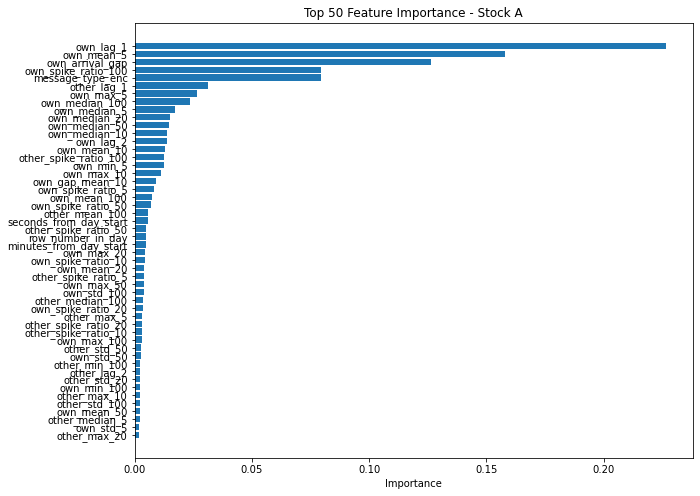

Features used: 50
Matrix shape: (50, 50)

Full Correlation Matrix:

                        own_lag_1  own_mean_5  own_arrival_gap  \
own_lag_1                1.000000    0.776891        -0.068358   
own_mean_5               0.776891    1.000000        -0.058444   
own_arrival_gap         -0.068358   -0.058444         1.000000   
own_spike_ratio_100      0.905561    0.602146        -0.067615   
message_type_enc        -0.025633   -0.008080        -0.006677   
other_lag_1              0.363110    0.405527        -0.038781   
own_max_5                0.702457    0.919941        -0.056807   
own_median_100           0.223178    0.290845        -0.022035   
own_median_5             0.733059    0.962068        -0.056040   
own_median_20            0.424181    0.615337        -0.038199   
own_median_50            0.280895    0.380702        -0.029454   
own_median_10            0.588455    0.858274        -0.048050   
own_lag_2                0.710706    0.847706        -0.052523   
own_mean

,Feature_1,Feature_2,Correlation
4,seconds_from_day_start,minutes_from_day_start,1.0000
5,other_std_20,other_max_20,0.9667
3,other_spike_ratio_100,other_spike_ratio_50,0.9653
1,own_spike_ratio_100,own_spike_ratio_50,0.9625
0,own_mean_5,own_median_5,0.9621
2,own_median_10,own_mean_10,0.9588


In [70]:

top_featuresA = feauture_importance(best_model_A_50, best_features_A1, 50, 'A')
correlation_matrix(features_train, 'A', top_featuresA)


<span style="font-size:16px;">
    
    
Best Results (Lowest RMSE)

- Stock A: RMSE = 46148 for n=50
    
---    
    
Look at correlation matrix, drop one of the predictors where the correlation > 0.95. 

* cor(seconds_from_day_start, minutes_from_day_start) = 1.000 --> drop minutes_from_day_start as it has lower feature importance
* cor(other_std_20, other_max_20) = 0.967 --> drop other_max_20 as it has lower feature importance
* cor(other_spike_ratio_100, other_spike_ratio_50) = 0.965 --> drop other_spike_ratio_50 as it has lower feature importance
* cor(own_spike_ratio_100, own_spike_ratio_50) = 0.963 --> drop own_spike_ratio_50 as it has lower feature importance
* cor(own_mean_5, own_median_5) = 0.962 --> drop own_median_5 as it has lower feature importance
* cor(own_median_10, own_mean_10) = 0.959 --> drop own_mean_10 as it has lower feature importance

</span>

In [ ]:
#stock A

# seconds_from_day_start	minutes_from_day_start	1.0000 --> drop minutes_from_day_start
# other_std_20	other_max_20	0.9667 --> drop other_max_20
# other_spike_ratio_100	other_spike_ratio_50	0.9653 --> drop other_spike_ratio_50
# own_spike_ratio_100	own_spike_ratio_50	0.9625 --> drop own_spike_ratio_50
# own_mean_5	own_median_5	0.9621 --> drop own_median_5
# own_median_10	own_mean_10	0.9588 --> drop own_mean_10
 


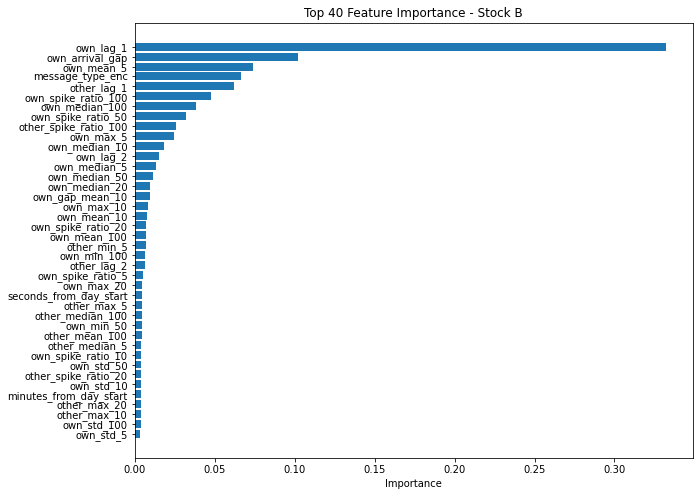

Features used: 40
Matrix shape: (40, 40)

Full Correlation Matrix:

                        own_lag_1  own_arrival_gap  own_mean_5  \
own_lag_1                1.000000        -0.066810    0.757399   
own_arrival_gap         -0.066810         1.000000   -0.055413   
own_mean_5               0.757399        -0.055413    1.000000   
message_type_enc        -0.037579        -0.003737   -0.026530   
other_lag_1              0.442875        -0.071969    0.436236   
own_spike_ratio_100      0.907140        -0.059277    0.593130   
own_median_100           0.252009        -0.042563    0.326757   
own_spike_ratio_50       0.867126        -0.058224    0.517218   
other_spike_ratio_100    0.392822        -0.060374    0.370350   
own_max_5                0.678195        -0.052044    0.910210   
own_median_10            0.555398        -0.045201    0.839832   
own_lag_2                0.690431        -0.051449    0.835553   
own_median_5             0.706532        -0.052479    0.954128   
own_medi

,Feature_1,Feature_2,Correlation
3,seconds_from_day_start,minutes_from_day_start,1.0000
1,own_spike_ratio_100,own_spike_ratio_50,0.9643
0,own_mean_5,own_median_5,0.9541
2,own_max_10,own_std_10,0.9513


In [71]:

top_featuresB = feauture_importance(best_model_B_40, best_features_B, 40, 'B')
correlation_matrix(features_train, 'B', top_featuresB)

In [ ]:
#stock B

# seconds_from_day_start	minutes_from_day_start	1.0000 --> drop minutes_from_day_start
# own_spike_ratio_100 	own_spike_ratio_50	0.9643 --> drop own_spike_ratio_50
# own_mean_5	own_median_5	0.9541 --> drop own_median_5
# own_max_10	own_std_10	0.9513 --> drop own_std_10




<span style="font-size:15px;">
    
    
Best Results (Lowest RMSE)

- Stock B: RMSE = 47566 for n=40 
    
---    
    
Look at correlation matrix, drop one of the predictors where the correlation > 0.95. 

* cor(seconds_from_day_start, minutes_from_day_start) = 1.000 --> drop minutes_from_day_start as it has lower feature importance
* cor(own_spike_ratio_100, own_spike_ratio_50) = 0.964 --> drop own_spike_ratio_50 as it has lower feature importance
* cor(own_mean_5, own_median_5) = 0.954 --> drop own_median_5 as it has lower feature importance
* cor(own_max_10, own_std_10) = 0.951 --> drop own_std_10 as it has lower feature importance


</span>

In [72]:
#old

best_model_A_50, results_A_50, mse_A_50, rmse_A_50 = train_predict_one_stock(
    features_train=features_train,
    features_test=features_test,
    stock="A",
    selected_features= best_features_A1,
    random_state=42,
    warmup=1000,
    use_log_target=True
)


#new

features_to_drop_A = {
    "minutes_from_day_start",
    "other_max_20",
    "other_spike_ratio_50",
    "own_spike_ratio_50",
    "own_median_5",
    "own_mean_10"
}

best_features_A2 = [
    f for f in best_features_A1
    if f not in features_to_drop_A
]


best_model_A_44, results_A_44, mse_A_44, rmse_A_44 = train_predict_one_stock(
    features_train=features_train,
    features_test=features_test,
    stock="A",
    selected_features= best_features_A2,
    random_state=42,
    warmup=1000,
    use_log_target=True
)





Stock A
X_train: (2908399, 50)
X_test: (155988, 50)
[20:53:33] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1645117948562/work/src/learner.cc:576: 
Parameters: { "device" } might not be used.

  This could be a false alarm, with some parameters getting used by language bindings but
  then being mistakenly passed down to XGBoost core, or some parameter actually being used
  but getting flagged wrongly here. Please open an issue if you find any such cases.


Stock_A MSE: 2128922496.0
Stock_A RMSE: 46140.24811376722
Stock A
X_train: (2908399, 44)
X_test: (155988, 44)
[20:54:10] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1645117948562/work/src/learner.cc:576: 
Parameters: { "device" } might not be used.

  This could be a false alarm, with some parameters getting used by language bindings but
  then being mistakenly passed down to XGBoost core, or some parameter actually being used
  but getting flagged wrongly here. Please open an issue if you find any such cas

In [73]:

#old


best_model_B_40, results_B_40, mse_B_40, rmse_B_40 = train_predict_one_stock(
    features_train=features_train,
    features_test=features_test,
    stock="B",
    selected_features=best_features_B,
    random_state=42,
    warmup=1000,
    use_log_target=True
)


features_to_drop_B = {
    "minutes_from_day_start",
    "own_spike_ratio_50",
    "own_median_5",
    "own_std_10"
}

#new

best_features_B2 = [
    f for f in best_features_B
    if f not in features_to_drop_B
]

best_model_B_36, results_B_36, mse_B_36, rmse_B_36 = train_predict_one_stock(
    features_train=features_train,
    features_test=features_test,
    stock="B",
    selected_features=best_features_B2,
    random_state=42,
    warmup=1000,
    use_log_target=True
)


Stock B
X_train: (1852726, 40)
X_test: (106264, 40)
[20:54:43] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1645117948562/work/src/learner.cc:576: 
Parameters: { "device" } might not be used.

  This could be a false alarm, with some parameters getting used by language bindings but
  then being mistakenly passed down to XGBoost core, or some parameter actually being used
  but getting flagged wrongly here. Please open an issue if you find any such cases.


Stock_B MSE: 2262516992.0
Stock_B RMSE: 47565.92259170424
Stock B
X_train: (1852726, 36)
X_test: (106264, 36)
[20:55:05] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1645117948562/work/src/learner.cc:576: 
Parameters: { "device" } might not be used.

  This could be a false alarm, with some parameters getting used by language bindings but
  then being mistakenly passed down to XGBoost core, or some parameter actually being used
  but getting flagged wrongly here. Please open an issue if you find any such cas


<span style="font-size:15px;">

## Results
    
Best Results (Lowest RMSE)

- Stock A: RMSE = 46140 for n=50
- Stock B: RMSE = 47566 for n=40 
    
---    
    
Dropped predictors:
    
- Stock A: minutes_from_day_start, other_max_20, other_spike_ratio_50, own_spike_ratio_50, own_median_5, own_mean_10
- Stock B: minutes_from_day_start, own_spike_ratio_50, own_median_5, own_std_10


---

New set of predictors:
- Stock A: RMSE = 46271 for n=44 (increased)
- Stock B: RMSE = 47508 for n=36 (decreased)

</span>

In [74]:
best_features_B2

['own_lag_1',
 'own_arrival_gap',
 'own_mean_5',
 'other_lag_1',
 'message_type_enc',
 'own_max_5',
 'own_median_100',
 'own_spike_ratio_100',
 'other_spike_ratio_100',
 'own_mean_10',
 'own_median_50',
 'own_median_10',
 'own_lag_2',
 'own_median_20',
 'own_gap_mean_10',
 'own_spike_ratio_20',
 'other_min_5',
 'own_min_100',
 'other_lag_2',
 'other_max_5',
 'own_std_50',
 'own_spike_ratio_5',
 'own_spike_ratio_10',
 'own_mean_100',
 'own_max_10',
 'other_max_20',
 'other_median_100',
 'own_min_50',
 'other_mean_100',
 'other_max_10',
 'other_median_5',
 'own_max_20',
 'seconds_from_day_start',
 'other_spike_ratio_20',
 'own_std_100',
 'own_std_5']

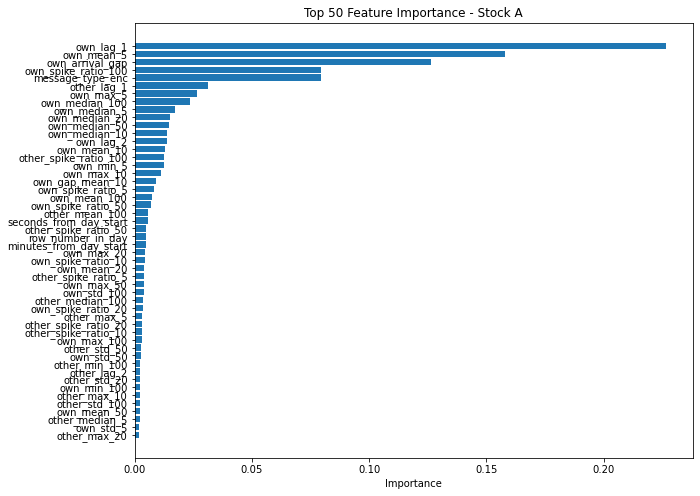

Features used: 50
Matrix shape: (50, 50)

Full Correlation Matrix:

                        own_lag_1  own_mean_5  own_arrival_gap  \
own_lag_1                1.000000    0.776891        -0.068358   
own_mean_5               0.776891    1.000000        -0.058444   
own_arrival_gap         -0.068358   -0.058444         1.000000   
own_spike_ratio_100      0.905561    0.602146        -0.067615   
message_type_enc        -0.025633   -0.008080        -0.006677   
other_lag_1              0.363110    0.405527        -0.038781   
own_max_5                0.702457    0.919941        -0.056807   
own_median_100           0.223178    0.290845        -0.022035   
own_median_5             0.733059    0.962068        -0.056040   
own_median_20            0.424181    0.615337        -0.038199   
own_median_50            0.280895    0.380702        -0.029454   
own_median_10            0.588455    0.858274        -0.048050   
own_lag_2                0.710706    0.847706        -0.052523   
own_mean

,Feature_1,Feature_2,Correlation
4,seconds_from_day_start,minutes_from_day_start,1.0000
5,other_std_20,other_max_20,0.9667
3,other_spike_ratio_100,other_spike_ratio_50,0.9653
1,own_spike_ratio_100,own_spike_ratio_50,0.9625
0,own_mean_5,own_median_5,0.9621
2,own_median_10,own_mean_10,0.9588


In [75]:

top_featuresA = feauture_importance(best_model_A_50, best_features_A1, 50, 'A')
correlation_matrix(features_train, 'A', top_featuresA)

In [77]:
#old

best_model_A_50, results_A_50, mse_A_50, rmse_A_50 = train_predict_one_stock(
    features_train=features_train,
    features_test=features_test,
    stock="A",
    selected_features= best_features_A1,
    random_state=42,
    warmup=1000,
    use_log_target=True
)


#new

features_to_drop_A = {
#     "other_max_20",
    "minutes_from_day_start",
#     "other_spike_ratio_50",
#     "own_spike_ratio_50",
#     "own_mean_10",
#     "own_median_5"


}

best_features_A3 = [
    f for f in best_features_A1
    if f not in features_to_drop_A
]


best_model_A_48, results_A_48, mse_A_48, rmse_A_48 = train_predict_one_stock(
    features_train=features_train,
    features_test=features_test,
    stock="A",
    selected_features= best_features_A3,
    random_state=42,
    warmup=1000,
    use_log_target=True
)

Stock A
X_train: (2908399, 50)
X_test: (155988, 50)
[21:11:24] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1645117948562/work/src/learner.cc:576: 
Parameters: { "device" } might not be used.

  This could be a false alarm, with some parameters getting used by language bindings but
  then being mistakenly passed down to XGBoost core, or some parameter actually being used
  but getting flagged wrongly here. Please open an issue if you find any such cases.


Stock_A MSE: 2128922496.0
Stock_A RMSE: 46140.24811376722
Stock A
X_train: (2908399, 49)
X_test: (155988, 49)
[21:12:03] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1645117948562/work/src/learner.cc:576: 
Parameters: { "device" } might not be used.

  This could be a false alarm, with some parameters getting used by language bindings but
  then being mistakenly passed down to XGBoost core, or some parameter actually being used
  but getting flagged wrongly here. Please open an issue if you find any such cas

In [78]:
#old

best_model_A_50, results_A_50, mse_A_50, rmse_A_50 = train_predict_one_stock(
    features_train=features_train,
    features_test=features_test,
    stock="A",
    selected_features= best_features_A1,
    random_state=42,
    warmup=1000,
    use_log_target=True
)


#new

features_to_drop_A = {
    "other_max_20"
#     "minutes_from_day_start",
#     "other_spike_ratio_50",
#     "own_spike_ratio_50",
#     "own_mean_10",
#     "own_median_5"


}

best_features_A3 = [
    f for f in best_features_A1
    if f not in features_to_drop_A
]


best_model_A_48, results_A_48, mse_A_48, rmse_A_48 = train_predict_one_stock(
    features_train=features_train,
    features_test=features_test,
    stock="A",
    selected_features= best_features_A3,
    random_state=42,
    warmup=1000,
    use_log_target=True
)

Stock A
X_train: (2908399, 50)
X_test: (155988, 50)
[21:17:21] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1645117948562/work/src/learner.cc:576: 
Parameters: { "device" } might not be used.

  This could be a false alarm, with some parameters getting used by language bindings but
  then being mistakenly passed down to XGBoost core, or some parameter actually being used
  but getting flagged wrongly here. Please open an issue if you find any such cases.


Stock_A MSE: 2128922496.0
Stock_A RMSE: 46140.24811376722
Stock A
X_train: (2908399, 49)
X_test: (155988, 49)
[21:17:59] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1645117948562/work/src/learner.cc:576: 
Parameters: { "device" } might not be used.

  This could be a false alarm, with some parameters getting used by language bindings but
  then being mistakenly passed down to XGBoost core, or some parameter actually being used
  but getting flagged wrongly here. Please open an issue if you find any such cas

<span style="font-size:15px;">

## Results
    
Best Results (Lowest RMSE)

- Stock A: RMSE = 46140 for n=50
- Stock B: RMSE = 47566 for n=40 
    
---    
    
Dropped predictors:
    
- Stock A: minutes_from_day_start, other_max_20, other_spike_ratio_50, own_spike_ratio_50, own_median_5, own_mean_10
- Stock B: minutes_from_day_start, own_spike_ratio_50, own_median_5, own_std_10


---

New set of predictors:
    
- Stock A: RMSE = 46271 for n=44 (increased)
- Stock B: RMSE = 47508 for n=36 (decreased)
    
    
---    
    
Dropped predictors:
    
- Stock A: minutes_from_day_start
    
---

New set of predictors:
- Stock A: RMSE = 46210 for n=49 (increased in comparision with the best model)

---    
    
Dropped predictors:
    
- Stock A: other_max_20
    
---

New set of predictors:
    
- Stock A: RMSE = 46140 for n=49 (increased in comparision with the best model)

    

</span>


<span style="font-size:15px;">

## Conclusion
    
Best Results (Lowest RMSE)

- Stock A: RMSE = 46140 for n=50
- Stock B: RMSE = 47508 for n=36

    
---    
    
Final set of predictors:
    
- Stock A: own_lag_1, own_mean_5, own_arrival_gap, message_type_enc, other_lag_1, own_spike_ratio_50, own_median_100, own_spike_ratio_100, own_median_5, own_max_10, own_median_10, own_median_20, own_mean_10,
other_spike_ratio_100, own_median_50, own_lag_2, own_min_5, own_max_5, own_mean_50, own_gap_mean_10, other_mean_100, own_max_20, own_spike_ratio_5, own_max_50, seconds_from_day_start, own_mean_100, other_spike_ratio_50, minutes_from_day_start, row_number_in_day, own_mean_20, other_median_100, other_spike_ratio_5, own_std_100, own_spike_ratio_10, other_max_10, other_std_50, own_spike_ratio_20, other_spike_ratio_10, own_max_100, other_max_5, other_spike_ratio_20, other_min_100, own_std_50,
other_std_20, other_lag_2, other_max_20, own_min_100, other_std_100, own_std_5, other_median_5
    <br>
    
- Stock B: own_lag_1, own_arrival_gap, own_mean_5, other_lag_1, message_type_enc, own_max_5, own_median_100,
own_spike_ratio_100, other_spike_ratio_100, own_mean_10, own_median_50, own_median_10, own_lag_2, own_median_20,
own_gap_mean_10, own_spike_ratio_20, other_min_5, own_min_100, other_lag_2, other_max_5, own_std_50, own_spike_ratio_5, own_spike_ratio_10, own_mean_100, own_max_10, other_max_20, other_median_100, own_min_50,
other_mean_100, other_max_10, other_median_5, own_max_20, seconds_from_day_start, other_spike_ratio_20, own_std_100, own_std_5


</span>







## e) XGBoost - Parameter tunning


<span style="font-size:15px;">


### Hyperparameter Tuning

After selecting the optimal feature subsets, I performed hyperparameter tuning to improve model performance further and reduce RMSE.

The goal of hyperparameter tuning was to find the combination of model parameters that produced the best generalization performance on the test day.

---

### XGBoost Hyperparameter Tuning

For XGBoost, I used **Grid Search**.

Grid Search systematically tests every possible combination of parameters from a predefined parameter grid.

The process was:

1. Define a set of candidate parameter values.
2. Generate all possible parameter combinations using `ParameterGrid`.
3. Train a separate XGBoost model for every combination.
4. Predict delays on the test set.
5. Calculate RMSE for each model.
6. Select the parameter combination with the lowest RMSE.

The parameter grid used was:

```python
param_grid = {
    "n_estimators": [600, 700, 800],
    "max_depth": [6, 7],
    "learning_rate": [0.02, 0.03],
    "subsample": [0.80, 0.85],
    "colsample_bytree": [0.80, 0.85],
    "reg_alpha": [0.05, 0.10],
    "reg_lambda": [0.20, 0.30]
}
```

---

### Meaning of Tuned Parameters

### `n_estimators`
Controls the number of boosting trees.

- Larger values can improve performance
- Too many trees may cause overfitting
- Also increases training time

---

### `max_depth`
Controls the maximum depth of each decision tree.

- Larger depth captures more complex relationships
- Very deep trees may overfit noise

---

### `learning_rate`
Controls how much each tree contributes to the final prediction.

- Smaller learning rates are usually more stable
- Requires more trees
- Helps reduce overfitting

---

### `subsample`
Controls the fraction of training observations used for each tree.

- Helps reduce overfitting
- Adds randomness to the model

---

### `colsample_bytree`
Controls the fraction of features sampled for each tree.

- Helps reduce correlation between trees
- Improves generalization

---

### `reg_alpha`
L1 regularization parameter.

- Encourages sparsity
- Helps reduce overfitting
- Can reduce the influence of weak predictors

---

### `reg_lambda`
L2 regularization parameter.

- Stabilizes model weights
- Helps improve generalization performance



</span>


In [95]:
import gc
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import ParameterGrid
from xgboost import XGBRegressor


def xgb_grid_search(
    features_train,
    features_test,
    stock,
    selected_features,
    param_grid,
    warmup=1000,
    use_log_target=True
):
    """
    Grid search for XGBoost parameters for one stock.

    Returns:
        results_df
        best_params
        best_model
    """

    # -----------------------------
    # Prepare train/test
    # -----------------------------
    train_mask = (
        (features_train["row_number_in_day"] > warmup) &
        (features_train["stock"] == stock)
    )

    test_mask = (
        (features_test["row_number_in_day"] > warmup) &
        (features_test["stock"] == stock)
    )

    X_train = features_train.loc[
        train_mask,
        selected_features
    ].astype("float32")

    X_test = features_test.loc[
        test_mask,
        selected_features
    ].astype("float32")

    y_train_raw = features_train.loc[
        train_mask,
        "delay"
    ].astype("float32")

    y_test = features_test.loc[
        test_mask,
        "delay"
    ].astype("float32")

    if use_log_target:
        y_train = np.log1p(y_train_raw)
    else:
        y_train = y_train_raw.copy()

    # -----------------------------
    # Grid search
    # -----------------------------
    rows = []

    best_rmse = float("inf")
    best_model = None
    best_params = None

    all_params = list(ParameterGrid(param_grid))

    print(f"Total combinations to test: {len(all_params)}")

    for i, params in enumerate(all_params, 1):
        print("=" * 80)
        print(f"Running combination {i}/{len(all_params)}")
        print(params)

        model = XGBRegressor(
            objective="reg:squarederror",
            tree_method="hist",
            device="cuda",
            random_state=42,
            n_jobs=-1,
            **params
        )

        model.fit(X_train, y_train)

        pred = model.predict(X_test)

        if use_log_target:
            pred = np.expm1(pred)

        pred = np.maximum(pred, 0)

        mse = mean_squared_error(y_test, pred)
        rmse = np.sqrt(mse)

        print(f"RMSE: {rmse:.4f}")

        rows.append({
            **params,
            "mse": mse,
            "rmse": rmse
        })

        if rmse < best_rmse:
            best_rmse = rmse
            best_params = params
            best_model = model

        gc.collect()

    results_df = pd.DataFrame(rows).sort_values("rmse")

    print("\n" + "=" * 80)
    print("BEST PARAMETERS FOUND")
    print("=" * 80)
    print(best_params)
    print(f"Best RMSE: {best_rmse:.4f}")

    return results_df, best_params, best_model

In [98]:


param_grid = {
    "n_estimators": [600, 700, 800],
    "max_depth": [6, 7],
    "learning_rate": [0.02, 0.03],
    "subsample": [0.80, 0.85],
    "colsample_bytree": [0.80, 0.85],
    "reg_alpha": [0.05, 0.10],
    "reg_lambda": [0.20, 0.30]
}

In [99]:
best_features_A1 = ['own_lag_1',
 'own_mean_5',
 'own_arrival_gap',
 'message_type_enc',
 'other_lag_1',
 'own_spike_ratio_50',
 'own_median_100',
 'own_spike_ratio_100',
 'own_median_5',
 'own_max_10',
 'own_median_10',
 'own_median_20',
 'own_mean_10',
 'other_spike_ratio_100',
 'own_median_50',
 'own_lag_2',
 'own_min_5',
 'own_max_5',
 'own_mean_50',
 'own_gap_mean_10',
 'other_mean_100',
 'own_max_20',
 'own_spike_ratio_5',
 'own_max_50',
 'seconds_from_day_start',
 'own_mean_100',
 'other_spike_ratio_50',
 'minutes_from_day_start',
 'row_number_in_day',
 'own_mean_20',
 'other_median_100',
 'other_spike_ratio_5',
 'own_std_100',
 'own_spike_ratio_10',
 'other_max_10',
 'other_std_50',
 'own_spike_ratio_20',
 'other_spike_ratio_10',
 'own_max_100',
 'other_max_5',
 'other_spike_ratio_20',
 'other_min_100',
 'own_std_50',
 'other_std_20',
 'other_lag_2',
 'other_max_20',
 'own_min_100',
 'other_std_100',
 'own_std_5',
 'other_median_5']



results_A, best_params_A, best_model_A = xgb_grid_search(
    features_train=features_train,
    features_test=features_test,
    stock="A",
    selected_features=best_features_A1,
    param_grid=param_grid,
    warmup=1000,
    use_log_target=True
)

Total combinations to test: 192
Running combination 1/192
{'colsample_bytree': 0.8, 'learning_rate': 0.02, 'max_depth': 6, 'n_estimators': 600, 'reg_alpha': 0.05, 'reg_lambda': 0.2, 'subsample': 0.8}
[22:31:54] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1645117948562/work/src/learner.cc:576: 
Parameters: { "device" } might not be used.

  This could be a false alarm, with some parameters getting used by language bindings but
  then being mistakenly passed down to XGBoost core, or some parameter actually being used
  but getting flagged wrongly here. Please open an issue if you find any such cases.


RMSE: 46943.4356
Running combination 2/192
{'colsample_bytree': 0.8, 'learning_rate': 0.02, 'max_depth': 6, 'n_estimators': 600, 'reg_alpha': 0.05, 'reg_lambda': 0.2, 'subsample': 0.85}
[22:32:21] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1645117948562/work/src/learner.cc:576: 
Parameters: { "device" } might not be used.

  This could be a false alarm, with so

RMSE: 46759.9391
Running combination 13/192
{'colsample_bytree': 0.8, 'learning_rate': 0.02, 'max_depth': 6, 'n_estimators': 700, 'reg_alpha': 0.1, 'reg_lambda': 0.2, 'subsample': 0.8}
[22:37:27] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1645117948562/work/src/learner.cc:576: 
Parameters: { "device" } might not be used.

  This could be a false alarm, with some parameters getting used by language bindings but
  then being mistakenly passed down to XGBoost core, or some parameter actually being used
  but getting flagged wrongly here. Please open an issue if you find any such cases.


RMSE: 46933.4548
Running combination 14/192
{'colsample_bytree': 0.8, 'learning_rate': 0.02, 'max_depth': 6, 'n_estimators': 700, 'reg_alpha': 0.1, 'reg_lambda': 0.2, 'subsample': 0.85}
[22:37:57] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1645117948562/work/src/learner.cc:576: 
Parameters: { "device" } might not be used.

  This could be a false alarm, with some parameters g

RMSE: 46742.1646
Running combination 25/192
{'colsample_bytree': 0.8, 'learning_rate': 0.02, 'max_depth': 7, 'n_estimators': 600, 'reg_alpha': 0.05, 'reg_lambda': 0.2, 'subsample': 0.8}
[22:44:29] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1645117948562/work/src/learner.cc:576: 
Parameters: { "device" } might not be used.

  This could be a false alarm, with some parameters getting used by language bindings but
  then being mistakenly passed down to XGBoost core, or some parameter actually being used
  but getting flagged wrongly here. Please open an issue if you find any such cases.


RMSE: 46601.5787
Running combination 26/192
{'colsample_bytree': 0.8, 'learning_rate': 0.02, 'max_depth': 7, 'n_estimators': 600, 'reg_alpha': 0.05, 'reg_lambda': 0.2, 'subsample': 0.85}
[22:45:04] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1645117948562/work/src/learner.cc:576: 
Parameters: { "device" } might not be used.

  This could be a false alarm, with some parameters

RMSE: 46486.4822
Running combination 37/192
{'colsample_bytree': 0.8, 'learning_rate': 0.02, 'max_depth': 7, 'n_estimators': 700, 'reg_alpha': 0.1, 'reg_lambda': 0.2, 'subsample': 0.8}
[22:51:56] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1645117948562/work/src/learner.cc:576: 
Parameters: { "device" } might not be used.

  This could be a false alarm, with some parameters getting used by language bindings but
  then being mistakenly passed down to XGBoost core, or some parameter actually being used
  but getting flagged wrongly here. Please open an issue if you find any such cases.


RMSE: 46490.3066
Running combination 38/192
{'colsample_bytree': 0.8, 'learning_rate': 0.02, 'max_depth': 7, 'n_estimators': 700, 'reg_alpha': 0.1, 'reg_lambda': 0.2, 'subsample': 0.85}
[22:52:37] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1645117948562/work/src/learner.cc:576: 
Parameters: { "device" } might not be used.

  This could be a false alarm, with some parameters g

RMSE: 46293.7017
Running combination 49/192
{'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 6, 'n_estimators': 600, 'reg_alpha': 0.05, 'reg_lambda': 0.2, 'subsample': 0.8}
[23:00:39] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1645117948562/work/src/learner.cc:576: 
Parameters: { "device" } might not be used.

  This could be a false alarm, with some parameters getting used by language bindings but
  then being mistakenly passed down to XGBoost core, or some parameter actually being used
  but getting flagged wrongly here. Please open an issue if you find any such cases.


RMSE: 46481.9029
Running combination 50/192
{'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 6, 'n_estimators': 600, 'reg_alpha': 0.05, 'reg_lambda': 0.2, 'subsample': 0.85}
[23:01:08] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1645117948562/work/src/learner.cc:576: 
Parameters: { "device" } might not be used.

  This could be a false alarm, with some parameters

...

RMSE: 46259.5737
Running combination 145/192
{'colsample_bytree': 0.85, 'learning_rate': 0.03, 'max_depth': 6, 'n_estimators': 600, 'reg_alpha': 0.05, 'reg_lambda': 0.2, 'subsample': 0.8}
[23:55:57] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1645117948562/work/src/learner.cc:576: 
Parameters: { "device" } might not be used.

  This could be a false alarm, with some parameters getting used by language bindings but
  then being mistakenly passed down to XGBoost core, or some parameter actually being used
  but getting flagged wrongly here. Please open an issue if you find any such cases.


RMSE: 46519.8865
Running combination 146/192
{'colsample_bytree': 0.85, 'learning_rate': 0.03, 'max_depth': 6, 'n_estimators': 600, 'reg_alpha': 0.05, 'reg_lambda': 0.2, 'subsample': 0.85}
[23:56:23] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1645117948562/work/src/learner.cc:576: 
Parameters: { "device" } might not be used.

  This could be a false alarm, with some parame

RMSE: 46445.7292
Running combination 157/192
{'colsample_bytree': 0.85, 'learning_rate': 0.03, 'max_depth': 6, 'n_estimators': 700, 'reg_alpha': 0.1, 'reg_lambda': 0.2, 'subsample': 0.8}
[00:01:42] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1645117948562/work/src/learner.cc:576: 
Parameters: { "device" } might not be used.

  This could be a false alarm, with some parameters getting used by language bindings but
  then being mistakenly passed down to XGBoost core, or some parameter actually being used
  but getting flagged wrongly here. Please open an issue if you find any such cases.


RMSE: 46398.3172
Running combination 158/192
{'colsample_bytree': 0.85, 'learning_rate': 0.03, 'max_depth': 6, 'n_estimators': 700, 'reg_alpha': 0.1, 'reg_lambda': 0.2, 'subsample': 0.85}
[00:02:13] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1645117948562/work/src/learner.cc:576: 
Parameters: { "device" } might not be used.

  This could be a false alarm, with some paramete

RMSE: 46305.2895
Running combination 169/192
{'colsample_bytree': 0.85, 'learning_rate': 0.03, 'max_depth': 7, 'n_estimators': 600, 'reg_alpha': 0.05, 'reg_lambda': 0.2, 'subsample': 0.8}
[00:08:19] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1645117948562/work/src/learner.cc:576: 
Parameters: { "device" } might not be used.

  This could be a false alarm, with some parameters getting used by language bindings but
  then being mistakenly passed down to XGBoost core, or some parameter actually being used
  but getting flagged wrongly here. Please open an issue if you find any such cases.


RMSE: 46268.3360
Running combination 170/192
{'colsample_bytree': 0.85, 'learning_rate': 0.03, 'max_depth': 7, 'n_estimators': 600, 'reg_alpha': 0.05, 'reg_lambda': 0.2, 'subsample': 0.85}
[00:08:54] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1645117948562/work/src/learner.cc:576: 
Parameters: { "device" } might not be used.

  This could be a false alarm, with some parame

RMSE: 46192.3810
Running combination 181/192
{'colsample_bytree': 0.85, 'learning_rate': 0.03, 'max_depth': 7, 'n_estimators': 700, 'reg_alpha': 0.1, 'reg_lambda': 0.2, 'subsample': 0.8}
[00:15:32] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1645117948562/work/src/learner.cc:576: 
Parameters: { "device" } might not be used.

  This could be a false alarm, with some parameters getting used by language bindings but
  then being mistakenly passed down to XGBoost core, or some parameter actually being used
  but getting flagged wrongly here. Please open an issue if you find any such cases.


RMSE: 46244.0538
Running combination 182/192
{'colsample_bytree': 0.85, 'learning_rate': 0.03, 'max_depth': 7, 'n_estimators': 700, 'reg_alpha': 0.1, 'reg_lambda': 0.2, 'subsample': 0.85}
[00:16:11] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1645117948562/work/src/learner.cc:576: 
Parameters: { "device" } might not be used.

  This could be a false alarm, with some paramete

RMSE: 46073.2217

BEST PARAMETERS FOUND
{'colsample_bytree': 0.85, 'learning_rate': 0.03, 'max_depth': 7, 'n_estimators': 800, 'reg_alpha': 0.05, 'reg_lambda': 0.2, 'subsample': 0.85}
Best RMSE: 46018.9526


In [100]:
display(results_A.head(20))

#Stock_A RMSE: 46140.24811376722
#Stock_B RMSE: 47508.394542438495


#Best parameters for stock A

# colsample_bytree	learning_rate	max_depth	n_estimators	reg_alpha	reg_lambda	subsample	mse	rmse
# 0.85	0.03	7	800	0.05	0.2	0.85	2.117744e+09	46018.952617

#XGBoost Stock A RMSE: 46018.952617

,colsample_bytree,learning_rate,max_depth,n_estimators,reg_alpha,reg_lambda,subsample,mse,rmse
185,0.85,0.03,7,800,0.05,0.2,0.85,2.117744e+09,46018.952617
95,0.80,0.03,7,800,0.10,0.3,0.85,2.122544e+09,46071.076914
191,0.85,0.03,7,800,0.10,0.3,0.85,2.122742e+09,46073.221724
177,0.85,0.03,7,700,0.05,0.2,0.85,2.124510e+09,46092.402498
87,0.80,0.03,7,700,0.10,0.3,0.85,2.126598e+09,46115.047783
169,0.85,0.03,7,600,0.05,0.2,0.85,2.128772e+09,46138.612723
183,0.85,0.03,7,700,0.10,0.3,0.85,2.128922e+09,46140.248114
187,0.85,0.03,7,800,0.05,0.3,0.85,2.129491e+09,46146.413252
89,0.80,0.03,7,800,0.05,0.2,0.85,2.129509e+09,46146.601868
184,0.85,0.03,7,800,0.05,0.2,0.80,2.130620e+09,46158.641228


In [101]:

best_features_B2 = ['own_lag_1',
 'own_arrival_gap',
 'own_mean_5',
 'other_lag_1',
 'message_type_enc',
 'own_max_5',
 'own_median_100',
 'own_spike_ratio_100',
 'other_spike_ratio_100',
 'own_mean_10',
 'own_median_50',
 'own_median_10',
 'own_lag_2',
 'own_median_20',
 'own_gap_mean_10',
 'own_spike_ratio_20',
 'other_min_5',
 'own_min_100',
 'other_lag_2',
 'other_max_5',
 'own_std_50',
 'own_spike_ratio_5',
 'own_spike_ratio_10',
 'own_mean_100',
 'own_max_10',
 'other_max_20',
 'other_median_100',
 'own_min_50',
 'other_mean_100',
 'other_max_10',
 'other_median_5',
 'own_max_20',
 'seconds_from_day_start',
 'other_spike_ratio_20',
 'own_std_100',
 'own_std_5']

results_B, best_params_B, best_model_B = xgb_grid_search(
    features_train=features_train,
    features_test=features_test,
    stock="B",
    selected_features=best_features_B2,
    param_grid=param_grid,
    warmup=1000,
    use_log_target=True
)


#Stock_A RMSE: 46140.24811376722
#Stock_B RMSE: 47508.394542438495

Total combinations to test: 192
Running combination 1/192
{'colsample_bytree': 0.8, 'learning_rate': 0.02, 'max_depth': 6, 'n_estimators': 600, 'reg_alpha': 0.05, 'reg_lambda': 0.2, 'subsample': 0.8}
[00:23:13] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1645117948562/work/src/learner.cc:576: 
Parameters: { "device" } might not be used.

  This could be a false alarm, with some parameters getting used by language bindings but
  then being mistakenly passed down to XGBoost core, or some parameter actually being used
  but getting flagged wrongly here. Please open an issue if you find any such cases.


RMSE: 47972.1919
Running combination 2/192
{'colsample_bytree': 0.8, 'learning_rate': 0.02, 'max_depth': 6, 'n_estimators': 600, 'reg_alpha': 0.05, 'reg_lambda': 0.2, 'subsample': 0.85}
[00:23:30] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1645117948562/work/src/learner.cc:576: 
Parameters: { "device" } might not be used.

  This could be a false alarm, with so

RMSE: 47916.6797
Running combination 13/192
{'colsample_bytree': 0.8, 'learning_rate': 0.02, 'max_depth': 6, 'n_estimators': 700, 'reg_alpha': 0.1, 'reg_lambda': 0.2, 'subsample': 0.8}
[00:26:30] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1645117948562/work/src/learner.cc:576: 
Parameters: { "device" } might not be used.

  This could be a false alarm, with some parameters getting used by language bindings but
  then being mistakenly passed down to XGBoost core, or some parameter actually being used
  but getting flagged wrongly here. Please open an issue if you find any such cases.


RMSE: 47853.3707
Running combination 14/192
{'colsample_bytree': 0.8, 'learning_rate': 0.02, 'max_depth': 6, 'n_estimators': 700, 'reg_alpha': 0.1, 'reg_lambda': 0.2, 'subsample': 0.85}
[00:26:50] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1645117948562/work/src/learner.cc:576: 
Parameters: { "device" } might not be used.

  This could be a false alarm, with some parameters g

RMSE: 47859.1159
Running combination 25/192
{'colsample_bytree': 0.8, 'learning_rate': 0.02, 'max_depth': 7, 'n_estimators': 600, 'reg_alpha': 0.05, 'reg_lambda': 0.2, 'subsample': 0.8}
[00:30:28] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1645117948562/work/src/learner.cc:576: 
Parameters: { "device" } might not be used.

  This could be a false alarm, with some parameters getting used by language bindings but
  then being mistakenly passed down to XGBoost core, or some parameter actually being used
  but getting flagged wrongly here. Please open an issue if you find any such cases.


RMSE: 47642.4013
Running combination 26/192
{'colsample_bytree': 0.8, 'learning_rate': 0.02, 'max_depth': 7, 'n_estimators': 600, 'reg_alpha': 0.05, 'reg_lambda': 0.2, 'subsample': 0.85}
[00:30:45] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1645117948562/work/src/learner.cc:576: 
Parameters: { "device" } might not be used.

  This could be a false alarm, with some parameters

RMSE: 47615.1263
Running combination 37/192
{'colsample_bytree': 0.8, 'learning_rate': 0.02, 'max_depth': 7, 'n_estimators': 700, 'reg_alpha': 0.1, 'reg_lambda': 0.2, 'subsample': 0.8}
[00:34:08] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1645117948562/work/src/learner.cc:576: 
Parameters: { "device" } might not be used.

  This could be a false alarm, with some parameters getting used by language bindings but
  then being mistakenly passed down to XGBoost core, or some parameter actually being used
  but getting flagged wrongly here. Please open an issue if you find any such cases.


RMSE: 47616.2285
Running combination 38/192
{'colsample_bytree': 0.8, 'learning_rate': 0.02, 'max_depth': 7, 'n_estimators': 700, 'reg_alpha': 0.1, 'reg_lambda': 0.2, 'subsample': 0.85}
[00:34:29] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1645117948562/work/src/learner.cc:576: 
Parameters: { "device" } might not be used.

  This could be a false alarm, with some parameters g

RMSE: 47566.7406
Running combination 49/192
{'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 6, 'n_estimators': 600, 'reg_alpha': 0.05, 'reg_lambda': 0.2, 'subsample': 0.8}
[00:38:55] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1645117948562/work/src/learner.cc:576: 
Parameters: { "device" } might not be used.

  This could be a false alarm, with some parameters getting used by language bindings but
  then being mistakenly passed down to XGBoost core, or some parameter actually being used
  but getting flagged wrongly here. Please open an issue if you find any such cases.


RMSE: 47866.7083
Running combination 50/192
{'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 6, 'n_estimators': 600, 'reg_alpha': 0.05, 'reg_lambda': 0.2, 'subsample': 0.85}
[00:39:12] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1645117948562/work/src/learner.cc:576: 
Parameters: { "device" } might not be used.

  This could be a false alarm, with some parameters

...

RMSE: 47598.2682
Running combination 145/192
{'colsample_bytree': 0.85, 'learning_rate': 0.03, 'max_depth': 6, 'n_estimators': 600, 'reg_alpha': 0.05, 'reg_lambda': 0.2, 'subsample': 0.8}
[01:12:35] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1645117948562/work/src/learner.cc:576: 
Parameters: { "device" } might not be used.

  This could be a false alarm, with some parameters getting used by language bindings but
  then being mistakenly passed down to XGBoost core, or some parameter actually being used
  but getting flagged wrongly here. Please open an issue if you find any such cases.


RMSE: 47788.7967
Running combination 146/192
{'colsample_bytree': 0.85, 'learning_rate': 0.03, 'max_depth': 6, 'n_estimators': 600, 'reg_alpha': 0.05, 'reg_lambda': 0.2, 'subsample': 0.85}
[01:12:50] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1645117948562/work/src/learner.cc:576: 
Parameters: { "device" } might not be used.

  This could be a false alarm, with some parame

RMSE: 47780.5999
Running combination 157/192
{'colsample_bytree': 0.85, 'learning_rate': 0.03, 'max_depth': 6, 'n_estimators': 700, 'reg_alpha': 0.1, 'reg_lambda': 0.2, 'subsample': 0.8}
[01:15:39] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1645117948562/work/src/learner.cc:576: 
Parameters: { "device" } might not be used.

  This could be a false alarm, with some parameters getting used by language bindings but
  then being mistakenly passed down to XGBoost core, or some parameter actually being used
  but getting flagged wrongly here. Please open an issue if you find any such cases.


RMSE: 47715.4284
Running combination 158/192
{'colsample_bytree': 0.85, 'learning_rate': 0.03, 'max_depth': 6, 'n_estimators': 700, 'reg_alpha': 0.1, 'reg_lambda': 0.2, 'subsample': 0.85}
[01:15:54] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1645117948562/work/src/learner.cc:576: 
Parameters: { "device" } might not be used.

  This could be a false alarm, with some paramete

RMSE: 47727.0131
Running combination 169/192
{'colsample_bytree': 0.85, 'learning_rate': 0.03, 'max_depth': 7, 'n_estimators': 600, 'reg_alpha': 0.05, 'reg_lambda': 0.2, 'subsample': 0.8}
[01:19:17] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1645117948562/work/src/learner.cc:576: 
Parameters: { "device" } might not be used.

  This could be a false alarm, with some parameters getting used by language bindings but
  then being mistakenly passed down to XGBoost core, or some parameter actually being used
  but getting flagged wrongly here. Please open an issue if you find any such cases.


RMSE: 47486.2938
Running combination 170/192
{'colsample_bytree': 0.85, 'learning_rate': 0.03, 'max_depth': 7, 'n_estimators': 600, 'reg_alpha': 0.05, 'reg_lambda': 0.2, 'subsample': 0.85}
[01:19:35] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1645117948562/work/src/learner.cc:576: 
Parameters: { "device" } might not be used.

  This could be a false alarm, with some parame

RMSE: 47499.1389
Running combination 181/192
{'colsample_bytree': 0.85, 'learning_rate': 0.03, 'max_depth': 7, 'n_estimators': 700, 'reg_alpha': 0.1, 'reg_lambda': 0.2, 'subsample': 0.8}
[01:23:03] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1645117948562/work/src/learner.cc:576: 
Parameters: { "device" } might not be used.

  This could be a false alarm, with some parameters getting used by language bindings but
  then being mistakenly passed down to XGBoost core, or some parameter actually being used
  but getting flagged wrongly here. Please open an issue if you find any such cases.


RMSE: 47505.7271
Running combination 182/192
{'colsample_bytree': 0.85, 'learning_rate': 0.03, 'max_depth': 7, 'n_estimators': 700, 'reg_alpha': 0.1, 'reg_lambda': 0.2, 'subsample': 0.85}
[01:23:25] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1645117948562/work/src/learner.cc:576: 
Parameters: { "device" } might not be used.

  This could be a false alarm, with some paramete

RMSE: 47561.8106

BEST PARAMETERS FOUND
{'colsample_bytree': 0.85, 'learning_rate': 0.03, 'max_depth': 7, 'n_estimators': 800, 'reg_alpha': 0.1, 'reg_lambda': 0.3, 'subsample': 0.8}
Best RMSE: 47409.6551


In [102]:
display(results_B.head(20))

#best
#	colsample_bytree	learning_rate	max_depth	n_estimators	reg_alpha	reg_lambda	subsample	mse	rmse
# 0.85	0.03	7	800	0.10	0.3	0.80	2.247675e+09	47409.655050

#before hyperparameters tuning
#Stock_A RMSE: 46140.24811376722
#Stock_B RMSE: 47508.394542438495


#after hyperparameters tuning
#XGBoost Stock A RMSE: 46018.952617
#XGBoost Stock B RMSE: 47409.655050

,colsample_bytree,learning_rate,max_depth,n_estimators,reg_alpha,reg_lambda,subsample,mse,rmse
190,0.85,0.03,7,800,0.10,0.3,0.80,2.247675e+09,47409.655050
182,0.85,0.03,7,700,0.10,0.3,0.80,2.248825e+09,47421.781325
186,0.85,0.03,7,800,0.05,0.3,0.80,2.248891e+09,47422.475009
178,0.85,0.03,7,700,0.05,0.3,0.80,2.249794e+09,47431.993928
184,0.85,0.03,7,800,0.05,0.2,0.80,2.249804e+09,47432.101872
88,0.80,0.03,7,800,0.05,0.2,0.80,2.251719e+09,47452.285762
176,0.85,0.03,7,700,0.05,0.2,0.80,2.252203e+09,47457.378267
80,0.80,0.03,7,700,0.05,0.2,0.80,2.252315e+09,47458.556910
174,0.85,0.03,7,600,0.10,0.3,0.80,2.252550e+09,47461.035471
170,0.85,0.03,7,600,0.05,0.3,0.80,2.253884e+09,47475.089889


<span style="font-size:15px;">


### Final XGBoost Model — Stock A

The best-performing XGBoost model for Stock A used 50 predictors.

### Best Parameters

```python
{
    'colsample_bytree': 0.85,
    'learning_rate': 0.03,
    'max_depth': 7,
    'n_estimators': 800,
    'reg_alpha': 0.05,
    'reg_lambda': 0.2,
    'subsample': 0.85
}
```

### Final Performance

- Final RMSE: 46019
- Number of predictors: 50

### Comparison Before Hyperparameter Tuning

Before tuning:
    
- Stock A RMSE = 46140



### Final XGBoost Model — Stock B

The best-performing XGBoost model for Stock B used 36 predictors.

### Best Parameters

```python
{
    'colsample_bytree': 0.85,
    'learning_rate': 0.03,
    'max_depth': 7,
    'n_estimators': 800,
    'reg_alpha': 0.10,
    'reg_lambda': 0.3,
    'subsample': 0.80
}
```

### Final Performance

- Final RMSE: 47410
- Number of predictors: 36

### Comparison Before Hyperparameter Tuning

Before tuning:

Stock B RMSE = 47508



</span>

## 4. LightGBM Model

In [37]:
!pip install lightgbm

In [72]:
import gc
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error
from lightgbm import LGBMRegressor

def create_lgbm_model(random_state=42):
    return LGBMRegressor(
        n_estimators=700,
        learning_rate=0.03,
        max_depth=7,
        num_leaves=63,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_alpha=0.1,
        reg_lambda=0.3,
        min_child_samples=80,
        objective="regression",
        random_state=random_state,
        n_jobs=-1
    )


def train_predict_one_stock_lgbm(
    features_train,
    features_test,
    stock,
    selected_features,
    random_state=42,
    warmup=1000,
    use_log_target=True
):
    train_mask = (
        (features_train["row_number_in_day"] > warmup) &
        (features_train["stock"] == stock)
    )

    test_mask = (
        (features_test["row_number_in_day"] > warmup) &
        (features_test["stock"] == stock)
    )

    X_train = features_train.loc[train_mask, selected_features].astype("float32")
    y_train_raw = features_train.loc[train_mask, "delay"].astype("float32")

    y_train = np.log1p(y_train_raw) if use_log_target else y_train_raw

    X_test = features_test.loc[test_mask, selected_features].astype("float32")
    y_test = features_test.loc[test_mask, "delay"].astype("float32")

    model = create_lgbm_model(random_state=random_state)
    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    if use_log_target:
        pred = np.expm1(pred)

    pred = np.maximum(pred, 0)

    mse = mean_squared_error(y_test, pred)
    rmse = np.sqrt(mse)

    print(f"Stock_{stock} MSE:", mse)
    print(f"Stock_{stock} RMSE:", rmse)

    results = features_test.loc[
        test_mask,
        ["sending_time", "arrival_time", "delay"]
    ].copy()

    results["prediction"] = pred
    results["error"] = results["prediction"] - results["delay"]
    results["abs_error"] = results["error"].abs()

    del X_train, y_train_raw, y_train, X_test, y_test
    gc.collect()

    return model, results, mse, rmse

In [73]:
feature_cols = [

    "message_type_enc",

    "own_lag_1", "own_lag_2", "own_lag_3", "own_lag_5", "own_lag_10", "own_lag_20",

    "own_mean_5", "own_mean_10", "own_mean_20", "own_mean_50", "own_mean_100",
    "own_std_5", "own_std_10", "own_std_20", "own_std_50", "own_std_100",
    "own_median_5", "own_median_10", "own_median_20", "own_median_50", "own_median_100",
    "own_max_5", "own_max_10", "own_max_20", "own_max_50", "own_max_100",
    "own_min_5", "own_min_10", "own_min_20", "own_min_50", "own_min_100",

    "own_arrival_gap", "own_gap_mean_10",
    "own_spike_ratio_5", "own_spike_ratio_10", "own_spike_ratio_20",
    "own_spike_ratio_50", "own_spike_ratio_100",

    "other_lag_1", "other_lag_2", "other_lag_3", "other_lag_5",
    "other_lag_10", "other_lag_20",

    "other_mean_5", "other_mean_10", "other_mean_20", "other_mean_50", "other_mean_100",
    "other_std_5", "other_std_10", "other_std_20", "other_std_50", "other_std_100",
    "other_median_5", "other_median_10", "other_median_20", "other_median_50", "other_median_100",
    "other_max_5", "other_max_10", "other_max_20", "other_max_50", "other_max_100",
    "other_min_5", "other_min_10", "other_min_20", "other_min_50", "other_min_100",

    "other_spike_ratio_5", "other_spike_ratio_10", "other_spike_ratio_20",
    "other_spike_ratio_50", "other_spike_ratio_100",

    "seconds_from_day_start",
    "minutes_from_day_start",
    "row_number_in_day",
]

model_A_all, results_A_all, mse_A_all, rmse_A_all = train_predict_one_stock_lgbm(
    features_train=features_train,
    features_test=features_test,
    stock="A",
    selected_features= feature_cols,
    random_state=42,
    warmup=1000,
    use_log_target=True
)


#before hyperparameters tuning
#XGBoost Stock_A RMSE: 46140.24811376722
#XGBoost Stock_B RMSE: 47508.394542438495


#after hyperparameters tuning
#XGBoost Stock A RMSE: 46018.952617
#XGBoost Stock B RMSE: 47409.655050


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.067531 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 19637
[LightGBM] [Info] Number of data points in the train set: 2908399, number of used features: 78
[LightGBM] [Info] Start training from score 11.697691
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Stock_A MSE: 2168139615.4413095
Stock_A RMSE: 46563.286132330795


In [74]:
model_B_all, results_B_all, mse_B_all, rmse_B_all = train_predict_one_stock_lgbm(
    features_train=features_train,
    features_test=features_test,
    stock="B",
    selected_features= feature_cols,
    random_state=43,
    warmup=1000,
    use_log_target=True
)





[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.044978 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 19637
[LightGBM] [Info] Number of data points in the train set: 1852726, number of used features: 78
[LightGBM] [Info] Start training from score 11.675697
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Stock_B MSE: 2283763818.1702433
Stock_B RMSE: 47788.74154202267


<span style="font-size:15px;">


### LightGBM Model for 78 initial predictors.

- Stock A MSE: 2168139615
- Stock A RMSE: 46563
<br>
<br>
- Stock B MSE: 2283763818
- Stock B RMSE: 47789

### Hyperparameter Tunned best XGBoost model
    
- Stock A RMSE: 46019
- Number of predictors: 50
<br>
<br>
- Stock B RMSE: 47410
- Number of predictors: 36


</span>



### a) Feature Selection

#### Choosing number of features based on the lowest RMSE

#### 1. From full importnace , then top 20 of full importnace, top 30 of full importnace and so on


In [69]:

def train_evaluate_stock_lgbm(
    features_train,
    features_test,
    stock,
    selected_features,
    random_state=42,
    warmup=1000,
    use_log_target=True
):
    train_mask = (
        (features_train["row_number_in_day"] > warmup) &
        (features_train["stock"] == stock)
    )

    test_mask = (
        (features_test["row_number_in_day"] > warmup) &
        (features_test["stock"] == stock)
    )

    X_train = features_train.loc[train_mask, selected_features].astype("float32")
    y_train_raw = features_train.loc[train_mask, "delay"].astype("float32")

    y_train = np.log1p(y_train_raw) if use_log_target else y_train_raw

    X_test = features_test.loc[test_mask, selected_features].astype("float32")
    y_test = features_test.loc[test_mask, "delay"].astype("float32")

    model = create_lgbm_model(random_state=random_state)
    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    if use_log_target:
        pred = np.expm1(pred)

    pred = np.maximum(pred, 0)

    mse = mean_squared_error(y_test, pred)
    rmse = np.sqrt(mse)

    importance = pd.DataFrame({
        "feature": selected_features,
        "importance": model.feature_importances_
    }).sort_values("importance", ascending=False)

    results = features_test.loc[
        test_mask,
        ["sending_time", "arrival_time", "delay"]
    ].copy()

    results["prediction"] = pred
    results["error"] = results["prediction"] - results["delay"]
    results["abs_error"] = results["error"].abs()

    del X_train, y_train_raw, y_train, X_test, y_test, pred
    gc.collect()

    return model, importance, results, mse, rmse



def compare_top_n_from_full_importance_lgbm(
    features_train,
    features_test,
    importance_A_full,
    importance_B_full,
    feature_counts,
    warmup=1000,
    use_log_target=True
):
    rows = []

    best_rmse_A = float("inf")
    best_rmse_B = float("inf")

    best_features_A = None
    best_features_B = None

    best_n_A = None
    best_n_B = None

    for n in feature_counts:
        print("=" * 80)
        print(f"Testing top {n} features from FULL LightGBM importance")
        print("=" * 80)

        features_A_n = list(importance_A_full["feature"].head(n))
        features_B_n = list(importance_B_full["feature"].head(n))

        model_A, imp_A, res_A, mse_A, rmse_A = train_evaluate_stock_lgbm(
            features_train=features_train,
            features_test=features_test,
            stock="A",
            selected_features=features_A_n,
            random_state=42,
            warmup=warmup,
            use_log_target=use_log_target
        )

        model_B, imp_B, res_B, mse_B, rmse_B = train_evaluate_stock_lgbm(
            features_train=features_train,
            features_test=features_test,
            stock="B",
            selected_features=features_B_n,
            random_state=42,
            warmup=warmup,
            use_log_target=use_log_target
        )

        overall_y = np.concatenate([
            res_A["delay"].values,
            res_B["delay"].values
        ])

        overall_pred = np.concatenate([
            res_A["prediction"].values,
            res_B["prediction"].values
        ])

        overall_mse = mean_squared_error(overall_y, overall_pred)
        overall_rmse = np.sqrt(overall_mse)

        if rmse_A < best_rmse_A:
            best_rmse_A = rmse_A
            best_features_A = features_A_n.copy()
            best_n_A = n

        if rmse_B < best_rmse_B:
            best_rmse_B = rmse_B
            best_features_B = features_B_n.copy()
            best_n_B = n

        print(f"Top {n} | Stock_A RMSE: {rmse_A:.4f}")
        print(f"Top {n} | Stock_B RMSE: {rmse_B:.4f}")
        print(f"Top {n} | Overall RMSE: {overall_rmse:.4f}")

        rows.append({
            "n_features": n,
            "stock_A_mse": mse_A,
            "stock_A_rmse": rmse_A,
            "stock_B_mse": mse_B,
            "stock_B_rmse": rmse_B,
            "overall_mse": overall_mse,
            "overall_rmse": overall_rmse
        })

        del model_A, model_B, imp_A, imp_B, res_A, res_B
        gc.collect()

    comparison_df = pd.DataFrame(rows).sort_values("overall_rmse")

    print("\nBest Stock_A feature count:", best_n_A)
    print("Best Stock_A RMSE:", best_rmse_A)
    print("best_features_A_lgbm:")
    print(best_features_A)

    print("\nBest Stock_B feature count:", best_n_B)
    print("Best Stock_B RMSE:", best_rmse_B)
    print("best_features_B_lgbm:")
    print(best_features_B)

    return comparison_df, best_features_A, best_features_B










In [78]:
model_A_full_lgbm, importance_A_full_lgbm, results_A_full_lgbm, mse_A_full_lgbm, rmse_A_full_lgbm = train_evaluate_stock_lgbm(
    features_train=features_train,
    features_test=features_test,
    stock="A",
    selected_features=feature_cols,
    random_state=42,
    warmup=1000,
    use_log_target=True
)

model_B_full_lgbm, importance_B_full_lgbm, results_B_full_lgbm, mse_B_full_lgbm, rmse_B_full_lgbm = train_evaluate_stock_lgbm(
    features_train=features_train,
    features_test=features_test,
    stock="B",
    selected_features=feature_cols,
    random_state=43,
    warmup=1000,
    use_log_target=True
)




[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.071704 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 19637
[LightGBM] [Info] Number of data points in the train set: 2908399, number of used features: 78
[LightGBM] [Info] Start training from score 11.697691
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.044535 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 19637
[LightGBM] [Info] Number of data points in the train set: 1852726, number of used features: 78
[LightGBM] [Info] Start training from score 11.675697
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No furthe

In [79]:
feature_counts = [20, 30, 40, 50, 60]

comparison_df_lgbm, best_features_A_lgbm, best_features_B_lgbm = compare_top_n_from_full_importance_lgbm(
    features_train=features_train,
    features_test=features_test,
    importance_A_full=importance_A_full_lgbm,
    importance_B_full=importance_B_full_lgbm,
    feature_counts=feature_counts,
    warmup=1000,
    use_log_target=True
)

comparison_df_lgbm

#full model
#Stock_A RMSE: 46563.286132330795
#Stock_B RMSE: 47788.74154202267

#short model
#Stock_A RMSE: 46239 n=60
#Stock_B RMSE: 47658 n=60




Testing top 20 features from FULL LightGBM importance
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.022165 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4847
[LightGBM] [Info] Number of data points in the train set: 2908399, number of used features: 20
[LightGBM] [Info] Start training from score 11.697691
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.012372 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4847
[LightGBM] [Info] Number of data points in the train set: 1852726, number of used features: 20
[LightGBM] [Info] Start training from score 11.675697
[LightGBM] [Warning] No further splits with positive 

,n_features,stock_A_mse,stock_A_rmse,stock_B_mse,stock_B_rmse,overall_mse,overall_rmse
4,60,2.138026e+09,46238.790229,2.271322e+09,47658.389808,2.192037e+09,46819.196518
2,40,2.150258e+09,46370.877219,2.282515e+09,47775.678137,2.203849e+09,46945.165895
3,50,2.159347e+09,46468.771843,2.285776e+09,47809.787402,2.210576e+09,47016.758155
1,30,2.236463e+09,47291.257223,2.296509e+09,47921.900109,2.260793e+09,47547.800471
0,20,2.244596e+09,47377.170405,2.354727e+09,48525.529355,2.289221e+09,47845.804732


### 2. train full model → top 60 → retrain → new importance → top 50 → retrain → new importance → top 40

In [80]:
import gc
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error
from lightgbm import LGBMRegressor

def create_lgbm_model(random_state=42):
    return LGBMRegressor(
        n_estimators=700,
        learning_rate=0.03,
        max_depth=7,
        num_leaves=63,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_alpha=0.1,
        reg_lambda=0.3,
        min_child_samples=80,
        objective="regression",
        random_state=random_state,
        n_jobs=-1
    )


def train_one_stock_lgbm(
    features_train,
    features_test,
    stock,
    selected_features,
    random_state=42,
    warmup=1000
):
    train_mask = (
        (features_train["row_number_in_day"] > warmup) &
        (features_train["stock"] == stock)
    )

    test_mask = (
        (features_test["row_number_in_day"] > warmup) &
        (features_test["stock"] == stock)
    )

    X_train = features_train.loc[
        train_mask,
        selected_features
    ].astype("float32")

    y_train = np.log1p(
        features_train.loc[
            train_mask,
            "delay"
        ].astype("float32")
    )

    X_test = features_test.loc[
        test_mask,
        selected_features
    ].astype("float32")

    y_test = features_test.loc[
        test_mask,
        "delay"
    ].astype("float32")

    model = create_lgbm_model(random_state=random_state)
    model.fit(X_train, y_train)

    pred = model.predict(X_test)
    pred = np.expm1(pred)
    pred = np.maximum(pred, 0)

    mse = mean_squared_error(y_test, pred)
    rmse = np.sqrt(mse)

    importance = pd.DataFrame({
        "feature": selected_features,
        "importance": model.feature_importances_
    }).sort_values("importance", ascending=False)

    del X_train, X_test, y_train, y_test, pred
    gc.collect()

    return model, importance, mse, rmse



def recursive_feature_selection_lgbm(
    features_train,
    features_test,
    feature_cols,
    feature_counts=[60, 50, 40, 30, 20],
    warmup=1000
):
    results = []

    best_rmse_A = float("inf")
    best_rmse_B = float("inf")

    best_features_A = None
    best_features_B = None

    print("=" * 80)
    print("STEP 1: FULL LIGHTGBM MODEL TRAINING")
    print("=" * 80)

    model_A, importance_A, mse_A, rmse_A = train_one_stock_lgbm(
        features_train=features_train,
        features_test=features_test,
        stock="A",
        selected_features=feature_cols,
        random_state=42,
        warmup=warmup
    )

    model_B, importance_B, mse_B, rmse_B = train_one_stock_lgbm(
        features_train=features_train,
        features_test=features_test,
        stock="B",
        selected_features=feature_cols,
        random_state=43,
        warmup=warmup
    )

    print(f"FULL LIGHTGBM MODEL A RMSE: {rmse_A:.4f}")
    print(f"FULL LIGHTGBM MODEL B RMSE: {rmse_B:.4f}")

    for n in feature_counts:
        print("\n" + "=" * 80)
        print(f"RETRAIN LIGHTGBM USING TOP {n} FEATURES")
        print("=" * 80)

        features_A = list(importance_A["feature"].head(n))
        features_B = list(importance_B["feature"].head(n))

        model_A, importance_A, mse_A, rmse_A = train_one_stock_lgbm(
            features_train=features_train,
            features_test=features_test,
            stock="A",
            selected_features=features_A,
            random_state=42,
            warmup=warmup
        )

        if rmse_A < best_rmse_A:
            best_rmse_A = rmse_A
            best_features_A = features_A.copy()

        model_B, importance_B, mse_B, rmse_B = train_one_stock_lgbm(
            features_train=features_train,
            features_test=features_test,
            stock="B",
            selected_features=features_B,
            random_state=43,
            warmup=warmup
        )

        if rmse_B < best_rmse_B:
            best_rmse_B = rmse_B
            best_features_B = features_B.copy()

        avg_rmse = (rmse_A + rmse_B) / 2

        print(f"Stock A RMSE: {rmse_A:.4f}")
        print(f"Stock B RMSE: {rmse_B:.4f}")
        print(f"Average RMSE: {avg_rmse:.4f}")

        results.append({
            "n_features": n,
            "stock_A_mse": mse_A,
            "stock_A_rmse": rmse_A,
            "stock_B_mse": mse_B,
            "stock_B_rmse": rmse_B,
            "avg_rmse": avg_rmse
        })

        gc.collect()

    results_df = pd.DataFrame(results)

    print("\n" + "=" * 80)
    print("BEST LIGHTGBM FEATURE SETS FOUND")
    print("=" * 80)

    print(f"Best RMSE A: {best_rmse_A:.4f}")
    print(f"Best RMSE B: {best_rmse_B:.4f}")

    print("\nBest Features A:")
    print(best_features_A)

    print("\nBest Features B:")
    print(best_features_B)

    return results_df, best_features_A, best_features_B

In [81]:
feature_counts = [60, 50, 40, 30, 20]

results_df_lgbm, best_features_A_lgbm2, best_features_B_lgbm2 = recursive_feature_selection_lgbm(
    features_train=features_train,
    features_test=features_test,
    feature_cols=feature_cols,
    feature_counts=feature_counts,
    warmup=1000
)

results_df_lgbm = results_df_lgbm.sort_values("avg_rmse")
display(results_df_lgbm)

STEP 1: FULL LIGHTGBM MODEL TRAINING
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.062286 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 19637
[LightGBM] [Info] Number of data points in the train set: 2908399, number of used features: 78
[LightGBM] [Info] Start training from score 11.697691
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.044660 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 19637
[LightGBM] [Info] Number of data points in the train set: 1852726, number of used features: 78
[LightGBM] [Info] Start training from score 11.675697
[LightGBM] [Warning] No further splits with positive gain, best gain

,n_features,stock_A_mse,stock_A_rmse,stock_B_mse,stock_B_rmse,avg_rmse
0,60,2.138026e+09,46238.790229,2.271322e+09,47658.389808,46948.590019
2,40,2.159308e+09,46468.350450,2.285748e+09,47809.491911,47138.921180
1,50,2.168491e+09,46567.057429,2.285463e+09,47806.512975,47186.785202
3,30,2.184610e+09,46739.815832,2.287714e+09,47830.052643,47284.934238
4,20,2.194498e+09,46845.464132,2.337905e+09,48351.890559,47598.677346


In [ ]:
#full model
#Stock_A RMSE: 46563.286132330795
#Stock_B RMSE: 47788.74154202267

#short model - method 1 
#Stock_A RMSE: 46239 n=60
#Stock_B RMSE: 47658 n=60


#short model - method 2
#Stock_A RMSE: 46239 n=60
#Stock_B RMSE: 47658 n=60







<span style="font-size:15px;">
    
    
### Feature selection   
### Method 1 — Top-N Features from Full Model Importance

Best Results (Lowest RMSE)
    
- Stock A: RMSE = 46239 n=60
- Stock B: RMSE = 47658 n=60 
    
---

### Method 2 — Recursive Feature Selection
    
Best Results (Lowest RMSE)

- Stock A: RMSE = 46239 n = 60
- Stock B: RMSE = 47658 n = 60

---

### Full model (n=78)
- Stock_A RMSE: 46563
- Stock_B RMSE: 47789

---

### Conclusion 
    
- The same set of predictors for stock A from 2 methods. The same set of predictors for stock B from 2 methods. 
Use 60 predictors. 


</span>

In [49]:
 best_features_A_lgbm2 ==  best_features_A_lgbm

True

In [50]:
best_features_B_lgbm2 == best_features_B_lgbm

True

In [51]:
#exactly the same set of features from both methods
best_features_A_lgbm

['own_arrival_gap',
 'own_lag_1',
 'own_gap_mean_10',
 'other_lag_1',
 'own_lag_2',
 'own_median_100',
 'row_number_in_day',
 'seconds_from_day_start',
 'own_spike_ratio_5',
 'other_median_100',
 'own_spike_ratio_100',
 'message_type_enc',
 'own_max_5',
 'other_spike_ratio_100',
 'own_std_5',
 'own_mean_100',
 'own_min_5',
 'own_spike_ratio_10',
 'other_min_100',
 'own_median_5',
 'own_mean_5',
 'other_spike_ratio_50',
 'other_mean_100',
 'own_min_100',
 'own_spike_ratio_50',
 'own_spike_ratio_20',
 'other_spike_ratio_5',
 'minutes_from_day_start',
 'other_min_5',
 'own_median_50',
 'own_std_100',
 'other_spike_ratio_20',
 'own_lag_3',
 'other_spike_ratio_10',
 'own_max_50',
 'other_lag_2',
 'other_median_50',
 'own_max_10',
 'own_max_20',
 'own_max_100',
 'other_max_5',
 'own_median_20',
 'own_median_10',
 'other_std_5',
 'own_lag_5',
 'other_std_100',
 'own_std_10',
 'other_min_10',
 'own_mean_50',
 'own_std_50',
 'own_min_50',
 'other_median_5',
 'other_std_50',
 'other_min_50',
 'o

In [57]:
len(best_features_A_lgbm)

60

In [55]:
best_features_B_lgbm

['own_arrival_gap',
 'own_lag_1',
 'own_gap_mean_10',
 'other_lag_1',
 'own_median_100',
 'own_lag_2',
 'other_spike_ratio_100',
 'own_spike_ratio_100',
 'row_number_in_day',
 'other_median_100',
 'seconds_from_day_start',
 'message_type_enc',
 'own_min_100',
 'own_mean_100',
 'own_spike_ratio_5',
 'other_lag_2',
 'other_spike_ratio_20',
 'other_spike_ratio_50',
 'own_max_5',
 'other_spike_ratio_10',
 'own_spike_ratio_50',
 'other_min_100',
 'own_std_100',
 'other_mean_100',
 'other_min_5',
 'own_median_50',
 'other_spike_ratio_5',
 'own_median_5',
 'own_min_5',
 'own_std_5',
 'own_spike_ratio_20',
 'own_spike_ratio_10',
 'other_median_50',
 'other_median_5',
 'other_max_5',
 'own_max_10',
 'own_lag_3',
 'own_std_10',
 'own_median_20',
 'own_std_50',
 'own_min_50',
 'other_min_50',
 'other_min_10',
 'own_max_20',
 'own_mean_5',
 'other_std_5',
 'other_median_20',
 'own_median_10',
 'own_mean_50',
 'other_mean_5',
 'own_std_20',
 'other_min_20',
 'other_std_100',
 'own_max_50',
 'own_la

In [56]:
len(best_features_B_lgbm)

60

### 3. Find correlated variables and try to drop them

In [82]:

def correlation_matrix(data, stock, top_features, threshold=0.95):
    # Filter only one stock
    corr_df = data[
        data["stock"] == stock
    ][top_features].copy()

    # Correlation matrix
    corr = corr_df.corr()

    print("Features used:", len(top_features))
    print("Matrix shape:", corr.shape)
    print("\nFull Correlation Matrix:\n")
    print(corr)

    # -----------------------------------
    # Find highly correlated feature pairs
    # -----------------------------------
    high_corr_pairs = []

    for i in range(len(top_features)):
        for j in range(i + 1, len(top_features)):
            corr_value = corr.iloc[i, j]

            if abs(corr_value) >= threshold:
                high_corr_pairs.append([
                    top_features[i],
                    top_features[j],
                    round(corr_value, 4)
                ])

    high_corr_df = pd.DataFrame(
        high_corr_pairs,
        columns=[
            "Feature_1",
            "Feature_2",
            "Correlation"
        ]
    )

    if len(high_corr_df) > 0:
        high_corr_df = high_corr_df.sort_values(
            by="Correlation",
            ascending=False
        )

        print(f"\nFeature pairs with |correlation| >= {threshold}:\n")
        display(high_corr_df)

    else:
        print(f"\nNo feature pairs found with |correlation| >= {threshold}")



In [60]:
model_A_60_lgbm, results_A_60_lgbm, mse_A_60_lgbm, rmse_A_60_lgbm = train_predict_one_stock_lgbm(
    features_train=features_train,
    features_test=features_test,
    stock="A",
    selected_features=best_features_A_lgbm,
    random_state=42,
    warmup=1000,
    use_log_target=True
)








#full model
#Stock_A RMSE: 46563
#Stock_B RMSE: 47789


#short model - method 1
#Stock_A RMSE: 46239 n=60
#Stock_B RMSE: 47658 n=60


#short model - method 2
#Stock_A RMSE A: 46239 n = 60
#Stock_B RMSE: 47658 n = 60



[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.060780 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 15047
[LightGBM] [Info] Number of data points in the train set: 2908399, number of used features: 60
[LightGBM] [Info] Start training from score 11.697691
Stock_A MSE: 2138025721.8286614
Stock_A RMSE: 46238.79022886154


In [83]:
model_B_60_lgbm, results_B_60_lgbm, mse_B_60_lgbm, rmse_B_60_lgbm = train_predict_one_stock_lgbm(
    features_train=features_train,
    features_test=features_test,
    stock="B",
    selected_features=best_features_B_lgbm,
    random_state=43,
    warmup=1000,
    use_log_target=True
)




[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.033243 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 15047
[LightGBM] [Info] Number of data points in the train set: 1852726, number of used features: 60
[LightGBM] [Info] Start training from score 11.675697
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Stock_B MSE: 2271322119.112018
Stock_B RMSE: 47658.38980821759


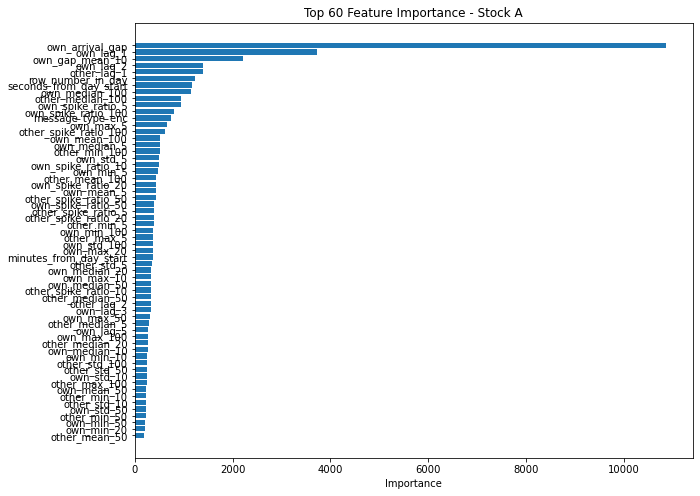

Features used: 60
Matrix shape: (60, 60)

Full Correlation Matrix:

                        own_arrival_gap  own_lag_1  own_gap_mean_10  \
own_arrival_gap                1.000000  -0.068358         0.432316   
own_lag_1                     -0.068358   1.000000        -0.075481   
own_gap_mean_10                0.432316  -0.075481         1.000000   
own_lag_2                     -0.052523   0.710706        -0.084755   
other_lag_1                   -0.038781   0.363110        -0.064182   
row_number_in_day             -0.005769  -0.042911        -0.012567   
seconds_from_day_start         0.018931  -0.038250         0.040958   
own_median_100                -0.022035   0.223178        -0.056651   
other_median_100              -0.020614   0.021932        -0.048395   
own_spike_ratio_5             -0.039782   0.523065         0.021520   
own_spike_ratio_100           -0.067615   0.905561        -0.055305   
message_type_enc              -0.006677  -0.025633        -0.021202   
own_max_5

,Feature_1,Feature_2,Correlation
0,seconds_from_day_start,minutes_from_day_start,1.0000
2,other_spike_ratio_100,other_spike_ratio_50,0.9653
1,own_spike_ratio_100,own_spike_ratio_50,0.9625
3,own_median_5,own_mean_5,0.9621


In [122]:
top_featuresA = feauture_importance(model_A_60_lgbm, best_features_A_lgbm, 60, 'A')
correlation_matrix(features_train, 'A', top_featuresA)



#Stock A

# seconds_from_day_start	minutes_from_day_start	1.0000 --> drop minutes_from_day_start
# other_spike_ratio_100	other_spike_ratio_50	0.9653 --> drop other_spike_ratio_50
# own_spike_ratio_100	own_spike_ratio_50	0.9625 --> drop own_spike_ratio_50
# own_median_5	own_mean_5	0.9621  --> drop own_mean_5


<span style="font-size:15px;">
    
    
Current Best Results (Lowest RMSE)

- Stock A: RMSE = 46239 n=60
    
---    
    
Look at correlation matrix, drop one of the predictors where the correlation > 0.95. 

* cor(seconds_from_day_start, minutes_from_day_start) = 1.000 --> drop minutes_from_day_start as it has lower feature importance
* cor( other_spike_ratio_100, other_spike_ratio_50) = 0.965 --> drop other_spike_ratio_50 as it has lower feature importance
* cor(own_spike_ratio_100, own_spike_ratio_50) = 0.953 --> drop own_spike_ratio_50 as it has lower feature importance
* cor(own_median_5, own_mean_5) = 0.962 --> drop own_mean_5 as it has lower feature importance


</span>

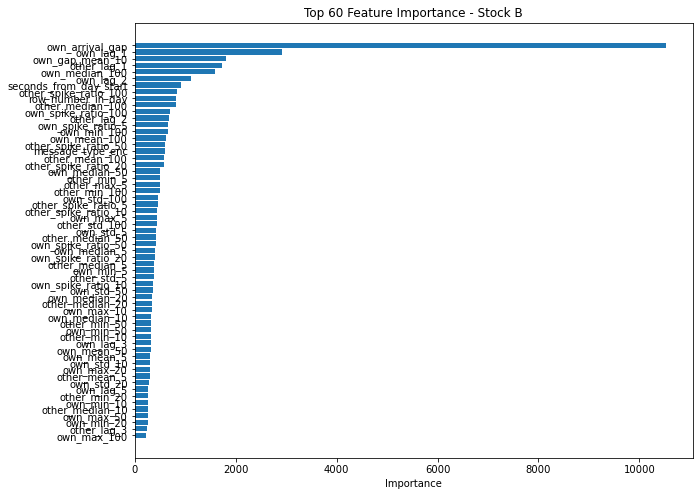

Features used: 60
Matrix shape: (60, 60)

Full Correlation Matrix:

                        own_arrival_gap  own_lag_1  own_gap_mean_10  \
own_arrival_gap                1.000000  -0.066810         0.445301   
own_lag_1                     -0.066810   1.000000        -0.085206   
own_gap_mean_10                0.445301  -0.085206         1.000000   
other_lag_1                   -0.071969   0.442875        -0.083627   
own_median_100                -0.042563   0.252009        -0.095076   
own_lag_2                     -0.051449   0.690431        -0.092284   
seconds_from_day_start         0.062075  -0.027314         0.131137   
other_spike_ratio_100         -0.060374   0.392822        -0.049183   
row_number_in_day              0.041783  -0.001749         0.088178   
other_median_100              -0.052700   0.024861        -0.115274   
own_spike_ratio_100           -0.059277   0.907140        -0.054633   
other_lag_2                   -0.070619   0.375262        -0.089340   
own_spike

,Feature_1,Feature_2,Correlation
0,other_spike_ratio_100,other_spike_ratio_50,0.9664
1,own_spike_ratio_100,own_spike_ratio_50,0.9643
5,own_max_20,own_std_20,0.9637
3,other_median_5,other_mean_5,0.9563
2,own_median_5,own_mean_5,0.9541
4,own_max_10,own_std_10,0.9513


In [123]:
top_featuresB = feauture_importance(model_B_60_lgbm, best_features_B_lgbm, 60, 'B')
correlation_matrix(features_train, 'B', top_featuresB)

#Stock B


# other_spike_ratio_100	other_spike_ratio_50	0.9664  --> drop other_spike_ratio_50
# own_spike_ratio_100	own_spike_ratio_50	0.9643  --> drop own_spike_ratio_50
# own_max_20	own_std_20	0.9637  --> drop own_std_20 (low)
# other_median_5	other_mean_5	0.9563  --> drop other_mean_5 (low)
# own_median_5	own_mean_5	0.9541  --> drop own_mean_5 (low)
# own_max_10	own_std_10	0.9513  --> drop own_std_10(low)


<span style="font-size:15px;">
    
    
Current Best Results (Lowest RMSE)

- Stock B: RMSE = 47658 n=60
    
---    
    
Look at correlation matrix, drop one of the predictors where the correlation > 0.95. 

* cor(other_spike_ratio_100, other_spike_ratio_50) = 0.966 --> drop minutes_from_day_start as it has lower feature importance
* cor(own_spike_ratio_100, own_spike_ratio_50) = 0.964 --> drop own_spike_ratio_50 as it has lower feature importance
* cor(own_max_20, own_std_20) = 0.964 --> drop own_std_20 as it has lower feature importance
* cor(other_median_5, other_mean_5) = 0.956 --> drop other_mean_5 as it has lower feature importance
* cor(own_median_5, own_mean_5) = 0.954 --> drop own_mean_5 as it has lower feature importance
* cor(own_max_10, own_std_10) = 0.951 --> drop own_std_10 as it has lower feature importance


</span>

In [ ]:
#full model
#Stock_A RMSE: 46563
#Stock_B RMSE: 47789


#short model - method 1
#Stock_A RMSE: 46239 n=60
#Stock_B RMSE: 47658 n=60


#short model - method 2
#Stock_A RMSE A: 46239 n = 60
#Stock_B RMSE: 47658 n = 60


In [62]:
#old

model_A_60_lgbm, results_A_60_lgbm, mse_A_60_lgbm, rmse_A_60_lgbm = train_predict_one_stock_lgbm(
    features_train=features_train,
    features_test=features_test,
    stock="A",
    selected_features=best_features_A_lgbm,
    random_state=42,
    warmup=1000,
    use_log_target=True
)


#new

features_to_drop_A = {
    "minutes_from_day_start",
    "other_spike_ratio_50",
    "own_spike_ratio_50",
    "own_mean_5"
}




best_features_A2 = [
    f for f in best_features_A_lgbm
    if f not in features_to_drop_A
]


best_model_A_56, results_A_56, mse_A_56, rmse_A_56 = train_predict_one_stock_lgbm(
    features_train=features_train,
    features_test=features_test,
    stock="A",
    selected_features= best_features_A2,
    random_state=42,
    warmup=1000,
    use_log_target=True
)



[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.059672 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 15047
[LightGBM] [Info] Number of data points in the train set: 2908399, number of used features: 60
[LightGBM] [Info] Start training from score 11.697691
Stock_A MSE: 2138025721.8286614
Stock_A RMSE: 46238.79022886154
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.048079 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 14027
[LightGBM] [Info] Number of data points in the train set: 2908399, number of used features: 56
[LightGBM] [Info] Start training from score 11.697691
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Stock_A MSE: 2155127494.788601
Stock_A RM

In [126]:
#old

model_A_60_lgbm, results_A_60_lgbm, mse_A_60_lgbm, rmse_A_60_lgbm = train_predict_one_stock_lgbm(
    features_train=features_train,
    features_test=features_test,
    stock="A",
    selected_features=best_features_A_lgbm,
    random_state=42,
    warmup=1000,
    use_log_target=True
)


#new

features_to_drop_A = {
#     "minutes_from_day_start",
    "other_spike_ratio_50",
    "own_spike_ratio_50",
    "own_mean_5"
}




best_features_A2 = [
    f for f in best_features_A_lgbm
    if f not in features_to_drop_A
]


best_model_A_56, results_A_56, mse_A_56, rmse_A_56 = train_predict_one_stock_lgbm(
    features_train=features_train,
    features_test=features_test,
    stock="A",
    selected_features= best_features_A2,
    random_state=42,
    warmup=1000,
    use_log_target=True
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.062231 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 15047
[LightGBM] [Info] Number of data points in the train set: 2908399, number of used features: 60
[LightGBM] [Info] Start training from score 11.697691
Stock_A MSE: 2138025721.8286614
Stock_A RMSE: 46238.79022886154
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.050618 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 14282
[LightGBM] [Info] Number of data points in the train set: 2908399, number of used features: 57
[LightGBM] [Info] Start training from score 11.697691
Stock_A MSE: 2152185024.289548
Stock_A RMSE: 46391.64821699643


In [64]:
len(best_features_B_lgbm)

60

In [84]:
#old

model_B_60_lgbm, results_B_60_lgbm, mse_B_60_lgbm, rmse_B_60_lgbm = train_predict_one_stock_lgbm(
    features_train=features_train,
    features_test=features_test,
    stock="B",
    selected_features=best_features_B_lgbm,
    random_state=43,
    warmup=1000,
    use_log_target=True
)


#new

features_to_drop_B = {
    "other_spike_ratio_50",
    "own_spike_ratio_50",
    "own_std_20",
    "other_mean_5",
    "own_mean_5",
    "own_std_10"
}




best_features_B2 = [
    f for f in best_features_B_lgbm
    if f not in features_to_drop_B
]


best_model_B_54, results_B_54, mse_B_54, rmse_B_54 = train_predict_one_stock_lgbm(
    features_train=features_train,
    features_test=features_test,
    stock="B",
    selected_features= best_features_B2,
    random_state=43,
    warmup=1000,
    use_log_target=True
)

#full model
#Stock_B RMSE: 47789


#short model - method 1
#Stock_B RMSE: 47658 n=60


#short model 
#Stock_B RMSE: 47663 n = 54




[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.036034 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 15047
[LightGBM] [Info] Number of data points in the train set: 1852726, number of used features: 60
[LightGBM] [Info] Start training from score 11.675697
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Stock_B MSE: 2271322119.112018
Stock_B RMSE: 47658.38980821759
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of tes

In [ ]:
#before hyperparameters tuning
#XGBoost Stock_A RMSE: 46140.24811376722
#XGBoost Stock_B RMSE: 47508.394542438495

#before hyperparameters tuning
#LightGBM Stock_A RMSE: 46239
#LightGBM Stock_B RMSE: 47818



#after hyperparameters tuning
#XGBoost Stock A RMSE: 46018.952617
#XGBoost Stock B RMSE: 47409.655050

In [129]:
best_features_A_lgbm

['own_arrival_gap',
 'own_lag_1',
 'own_gap_mean_10',
 'other_lag_1',
 'own_lag_2',
 'own_median_100',
 'row_number_in_day',
 'seconds_from_day_start',
 'own_spike_ratio_5',
 'other_median_100',
 'own_spike_ratio_100',
 'message_type_enc',
 'own_max_5',
 'other_spike_ratio_100',
 'own_std_5',
 'own_mean_100',
 'own_min_5',
 'own_spike_ratio_10',
 'other_min_100',
 'own_median_5',
 'own_mean_5',
 'other_spike_ratio_50',
 'other_mean_100',
 'own_min_100',
 'own_spike_ratio_50',
 'own_spike_ratio_20',
 'other_spike_ratio_5',
 'minutes_from_day_start',
 'other_min_5',
 'own_median_50',
 'own_std_100',
 'other_spike_ratio_20',
 'own_lag_3',
 'other_spike_ratio_10',
 'own_max_50',
 'other_lag_2',
 'other_median_50',
 'own_max_10',
 'own_max_20',
 'own_max_100',
 'other_max_5',
 'own_median_20',
 'own_median_10',
 'other_std_5',
 'own_lag_5',
 'other_std_100',
 'own_std_10',
 'other_min_10',
 'own_mean_50',
 'own_std_50',
 'own_min_50',
 'other_median_5',
 'other_std_50',
 'other_min_50',
 'o

In [86]:
len(best_features_A_lgbm)

60

In [128]:
best_features_B2

['own_arrival_gap',
 'own_lag_1',
 'own_gap_mean_10',
 'other_lag_1',
 'own_median_100',
 'own_lag_2',
 'other_spike_ratio_100',
 'own_spike_ratio_100',
 'row_number_in_day',
 'other_median_100',
 'seconds_from_day_start',
 'message_type_enc',
 'own_min_100',
 'own_mean_100',
 'own_spike_ratio_5',
 'other_lag_2',
 'other_spike_ratio_20',
 'own_max_5',
 'other_spike_ratio_10',
 'other_min_100',
 'own_std_100',
 'other_mean_100',
 'other_min_5',
 'own_median_50',
 'other_spike_ratio_5',
 'own_median_5',
 'own_min_5',
 'own_std_5',
 'own_spike_ratio_20',
 'own_spike_ratio_10',
 'other_median_50',
 'other_median_5',
 'other_max_5',
 'own_max_10',
 'own_lag_3',
 'own_median_20',
 'own_std_50',
 'own_min_50',
 'other_min_50',
 'other_min_10',
 'own_max_20',
 'other_std_5',
 'other_median_20',
 'own_median_10',
 'own_mean_50',
 'other_min_20',
 'other_std_100',
 'own_max_50',
 'own_lag_5',
 'own_max_100',
 'own_min_10',
 'own_min_20',
 'other_lag_3',
 'other_median_10']

In [85]:
len(best_features_B2)

54

<span style="font-size:15px;">

## Results
    
Best Results (Lowest RMSE)

- Stock A: RMSE = 46239 for n=60
- Stock B: RMSE = 47658 for n=60
    
---    
    
Dropped predictors:
    
- Stock A: minutes_from_day_start, other_spike_ratio_50, own_spike_ratio_50, own_mean_5
- Stock B: other_spike_ratio_50, own_spike_ratio_50, own_std_20, other_mean_5, own_mean_5, own_std_10


---

New set of predictors:
    
- Stock A: RMSE = 46423 for n=56 (increased significantly)
- Stock B: RMSE = 47663 for n=54 (very small increase) --> choose 54 predictors instead of 60
    
---    
    
Dropped predictors:
    
- Stock A: other_spike_ratio_50, own_spike_ratio_50, own_mean_5
    
---

New set of predictors:
    
- Stock A: RMSE = 46392 for n=57 (increased in comparision with the best model)



</span>


<span style="font-size:15px;">

## Conclusion
    
Best Results (Lowest RMSE)

- Stock A: RMSE = 46239 for n=60
- Stock B: RMSE = 47663 for n=54
    
    
---    
    
Final set of predictors:
    
- Stock A: own_arrival_gap, own_lag_1, own_gap_mean_10, other_lag_1, own_lag_2, own_median_100, row_number_in_day,
 seconds_from_day_start, own_spike_ratio_5, other_median_100, own_spike_ratio_100, message_type_enc, own_max_5,
 other_spike_ratio_100, own_std_5, own_mean_100, own_min_5, own_spike_ratio_10, other_min_100, own_median_5,
 own_mean_5, other_spike_ratio_50, other_mean_100, own_min_100, own_spike_ratio_50, own_spike_ratio_20,
 other_spike_ratio_5, minutes_from_day_start, other_min_5, own_median_50, own_std_100, other_spike_ratio_20,
 own_lag_3, other_spike_ratio_10, own_max_50, other_lag_2, other_median_50, own_max_10, own_max_20,
 own_max_100, other_max_5, own_median_20, own_median_10, other_std_5, own_lag_5, other_std_100,
 own_std_10, other_min_10, own_mean_50, own_std_50, own_min_50, other_median_5, other_std_50,
 other_min_50, own_min_10, other_mean_50, other_max_100, own_min_20, other_std_10, other_median_20
    <br>
    
- Stock B: own_arrival_gap, own_lag_1, own_gap_mean_10, other_lag_1, own_lag_2, own_median_100, row_number_in_day,
 seconds_from_day_start, other_median_100, own_spike_ratio_100, message_type_enc, own_max_5,
 other_spike_ratio_100, own_std_5, own_mean_100, own_min_5, own_spike_ratio_10, other_min_100, own_median_5, 
other_mean_100, own_min_100, own_spike_ratio_20, other_spike_ratio_5, other_min_5, own_median_50, own_std_100, 
other_spike_ratio_20, own_lag_3, other_spike_ratio_10, own_max_50, other_lag_2, other_median_50, own_max_10, own_max_20,
 own_max_100, other_max_5, own_median_20, own_median_10, other_std_5, own_lag_5, other_std_100,
 other_min_10, other_min_50, own_min_10, own_min_20, other_median_20, own_spike_ratio_5, other_min_20, other_lag_3, other_median_10
    
    


</span>


## b) LightGBM - Parameter tunning

<span style="font-size:15px;">

### LightGBM Hyperparameter Tuning

For LightGBM, I used **Random Search** instead of Grid Search.

Random Search randomly samples parameter combinations from predefined parameter distributions rather than evaluating every possible combination.

This approach is computationally more efficient when:
- the parameter space is large
- the model training time is expensive
- the number of hyperparameters increases

Since LightGBM contains several important tuning parameters, Random Search allowed broader exploration of the parameter space within a reasonable computation time.

The process was:

1. Define parameter distributions.
2. Randomly sample parameter combinations using `ParameterSampler`.
3. Train a separate LightGBM model for each sampled combination.
4. Predict delays on the test set.
5. Calculate RMSE for each model.
6. Select the parameter combination with the lowest RMSE.
   <br> 

The parameter grid used was:

```python
    
param_dist = {
    "n_estimators": [300, 500, 700, 900, 1200],
    "learning_rate": [0.01, 0.02, 0.03, 0.05],
    "max_depth": [5, 7, 9, 12, -1],
    "num_leaves": [31, 63, 127, 255],
    "subsample": [0.70, 0.80, 0.85, 0.90, 1.00],
    "colsample_bytree": [0.70, 0.80, 0.85, 0.90, 1.00],
    "min_child_samples": [20, 50, 80, 120, 200],
    "reg_alpha": [0.0, 0.05, 0.1, 0.3, 1.0],
    "reg_lambda": [0.1, 0.3, 0.5, 1.0, 3.0]
}


```

---


### Meaning of Tuned Parameters

### `n_estimators`

Controls the number of boosting trees.

- More trees can improve predictive performance
- Too many trees may increase overfitting
- Also increases training time

---

### `learning_rate`

Controls how much each tree contributes to the final prediction.

- Smaller values make learning more stable
- Requires more boosting trees
- Helps improve generalization

---

### `max_depth`

Controls the maximum depth of trees.

- Larger depth captures more complex interactions
- Excessively deep trees may overfit noisy patterns

In LightGBM:

```python
max_depth = -1
```

means no explicit depth restriction.

---

### `num_leaves`

Controls the maximum number of leaves in each tree.

This is one of the most important LightGBM parameters.

- Larger values allow more complex tree structures
- Can improve accuracy
- Very large values may overfit

Because LightGBM grows trees leaf-wise rather than level-wise, `num_leaves` strongly affects model complexity.

---

### `min_child_samples`

Controls the minimum number of observations required in a leaf.

- Larger values make the model more conservative
- Helps reduce overfitting
- Prevents overly specific splits

---

### `subsample`

Controls the fraction of training observations sampled for each tree.

- Adds randomness
- Helps reduce overfitting
- Improves generalization performance

---

### `colsample_bytree`

Controls the fraction of features sampled for each tree.

- Reduces correlation between trees
- Helps improve robustness
- Prevents over-reliance on a few predictors

---

### `reg_alpha`

L1 regularization parameter.

- Encourages sparsity
- Helps reduce the impact of weak/noisy predictors
- Can improve generalization

---

### `reg_lambda`

L2 regularization parameter.

- Stabilizes model weights
- Reduces overfitting
- Helps improve model robustness

</span>

In [135]:
import gc
import random
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import ParameterSampler
from lightgbm import LGBMRegressor

In [136]:
def lgbm_random_search(
    features_train,
    features_test,
    stock,
    selected_features,
    param_dist,
    n_iter=30,
    warmup=1000,
    use_log_target=True,
    random_state=42
):
    """
    Random search for LightGBM parameters for one stock.

    Returns:
        results_df
        best_params
        best_model
    """

    train_mask = (
        (features_train["row_number_in_day"] > warmup) &
        (features_train["stock"] == stock)
    )

    test_mask = (
        (features_test["row_number_in_day"] > warmup) &
        (features_test["stock"] == stock)
    )

    X_train = features_train.loc[
        train_mask,
        selected_features
    ].astype("float32")

    X_test = features_test.loc[
        test_mask,
        selected_features
    ].astype("float32")

    y_train_raw = features_train.loc[
        train_mask,
        "delay"
    ].astype("float32")

    y_test = features_test.loc[
        test_mask,
        "delay"
    ].astype("float32")

    if use_log_target:
        y_train = np.log1p(y_train_raw)
    else:
        y_train = y_train_raw.copy()

    rows = []

    best_rmse = float("inf")
    best_model = None
    best_params = None

    sampled_params = list(
        ParameterSampler(
            param_dist,
            n_iter=n_iter,
            random_state=random_state
        )
    )

    print(f"Total random combinations to test: {len(sampled_params)}")

    for i, params in enumerate(sampled_params, 1):
        print("=" * 80)
        print(f"Running random combination {i}/{len(sampled_params)}")
        print(params)

        model = LGBMRegressor(
            objective="regression",
            random_state=random_state,
            n_jobs=-1,
            verbosity=-1,
            **params
        )

        model.fit(X_train, y_train)

        pred = model.predict(X_test)

        if use_log_target:
            pred = np.expm1(pred)

        pred = np.maximum(pred, 0)

        mse = mean_squared_error(y_test, pred)
        rmse = np.sqrt(mse)

        print(f"RMSE: {rmse:.4f}")

        rows.append({
            **params,
            "mse": mse,
            "rmse": rmse
        })

        if rmse < best_rmse:
            best_rmse = rmse
            best_params = params
            best_model = model

        gc.collect()

    results_df = pd.DataFrame(rows).sort_values("rmse")

    print("\n" + "=" * 80)
    print("BEST LIGHTGBM PARAMETERS FOUND")
    print("=" * 80)
    print(best_params)
    print(f"Best RMSE: {best_rmse:.4f}")

    return results_df, best_params, best_model

In [138]:

param_dist = {
    "n_estimators": [300, 500, 700, 900, 1200],
    "learning_rate": [0.01, 0.02, 0.03, 0.05],
    "max_depth": [5, 7, 9, 12, -1],
    "num_leaves": [31, 63, 127, 255],
    "subsample": [0.70, 0.80, 0.85, 0.90, 1.00],
    "colsample_bytree": [0.70, 0.80, 0.85, 0.90, 1.00],
    "min_child_samples": [20, 50, 80, 120, 200],
    "reg_alpha": [0.0, 0.05, 0.1, 0.3, 1.0],
    "reg_lambda": [0.1, 0.3, 0.5, 1.0, 3.0]
}



best_features_A = ['own_arrival_gap',
 'own_lag_1',
 'own_gap_mean_10',
 'other_lag_1',
 'own_lag_2',
 'own_median_100',
 'row_number_in_day',
 'seconds_from_day_start',
 'own_spike_ratio_5',
 'other_median_100',
 'own_spike_ratio_100',
 'message_type_enc',
 'own_max_5',
 'other_spike_ratio_100',
 'own_std_5',
 'own_mean_100',
 'own_min_5',
 'own_spike_ratio_10',
 'other_min_100',
 'own_median_5',
 'own_mean_5',
 'other_spike_ratio_50',
 'other_mean_100',
 'own_min_100',
 'own_spike_ratio_50',
 'own_spike_ratio_20',
 'other_spike_ratio_5',
 'minutes_from_day_start',
 'other_min_5',
 'own_median_50',
 'own_std_100',
 'other_spike_ratio_20',
 'own_lag_3',
 'other_spike_ratio_10',
 'own_max_50',
 'other_lag_2',
 'other_median_50',
 'own_max_10',
 'own_max_20',
 'own_max_100',
 'other_max_5',
 'own_median_20',
 'own_median_10',
 'other_std_5',
 'own_lag_5',
 'other_std_100',
 'own_std_10',
 'other_min_10',
 'own_mean_50',
 'own_std_50',
 'own_min_50',
 'other_median_5',
 'other_std_50',
 'other_min_50',
 'own_min_10',
 'other_mean_50',
 'other_max_100',
 'own_min_20',
 'other_std_10',
 'other_median_20']


results_A, best_params_A, best_model_A = lgbm_random_search(
    features_train=features_train,
    features_test=features_test,
    stock="A",
    selected_features=best_features_A,
    param_dist=param_dist,
    n_iter=30,
    warmup=1000,
    use_log_target=True,
    random_state=42
)

#before hyperparameters tuning
#XGBoost Stock_A RMSE: 46140.24811376722
#XGBoost Stock_B RMSE: 47508.394542438495

#before hyperparameters tuning
#LightGBM Stock_A RMSE: 46239
#LightGBM Stock_B RMSE: 47818


Total random combinations to test: 30
Running random combination 1/30
{'subsample': 0.9, 'reg_lambda': 0.3, 'reg_alpha': 0.3, 'num_leaves': 255, 'n_estimators': 900, 'min_child_samples': 120, 'max_depth': -1, 'learning_rate': 0.02, 'colsample_bytree': 0.7}
RMSE: 46375.7358
Running random combination 2/30
{'subsample': 0.7, 'reg_lambda': 0.3, 'reg_alpha': 0.05, 'num_leaves': 63, 'n_estimators': 700, 'min_child_samples': 120, 'max_depth': 12, 'learning_rate': 0.03, 'colsample_bytree': 0.85}
RMSE: 46480.0404
Running random combination 3/30
{'subsample': 0.85, 'reg_lambda': 0.3, 'reg_alpha': 0.1, 'num_leaves': 255, 'n_estimators': 900, 'min_child_samples': 80, 'max_depth': 5, 'learning_rate': 0.03, 'colsample_bytree': 0.7}
RMSE: 46909.9064
Running random combination 4/30
{'subsample': 0.9, 'reg_lambda': 0.1, 'reg_alpha': 0.1, 'num_leaves': 63, 'n_estimators': 900, 'min_child_samples': 120, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.8}
RMSE: 47859.7170
Running random combi

RMSE: 46378.7481
Running random combination 27/30
{'subsample': 0.7, 'reg_lambda': 0.3, 'reg_alpha': 1.0, 'num_leaves': 63, 'n_estimators': 900, 'min_child_samples': 80, 'max_depth': 9, 'learning_rate': 0.03, 'colsample_bytree': 0.7}
RMSE: 46276.2977
Running random combination 28/30
{'subsample': 1.0, 'reg_lambda': 0.1, 'reg_alpha': 0.3, 'num_leaves': 31, 'n_estimators': 500, 'min_child_samples': 200, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
RMSE: 46710.2195
Running random combination 29/30
{'subsample': 0.8, 'reg_lambda': 0.5, 'reg_alpha': 0.1, 'num_leaves': 127, 'n_estimators': 1200, 'min_child_samples': 50, 'max_depth': 9, 'learning_rate': 0.03, 'colsample_bytree': 0.85}
RMSE: 46329.9807
Running random combination 30/30
{'subsample': 0.7, 'reg_lambda': 0.5, 'reg_alpha': 0.05, 'num_leaves': 31, 'n_estimators': 1200, 'min_child_samples': 20, 'max_depth': 9, 'learning_rate': 0.01, 'colsample_bytree': 0.85}
RMSE: 47540.7716

BEST LIGHTGBM PARAMETERS FOUND
{'subsam

In [139]:
display(results_A.head(20))

,subsample,reg_lambda,reg_alpha,num_leaves,n_estimators,min_child_samples,max_depth,learning_rate,colsample_bytree,mse,rmse
22,1.00,0.1,0.05,127,1200,120,-1,0.03,0.70,2.135002e+09,46206.081633
26,0.70,0.3,1.00,63,900,80,9,0.03,0.70,2.141496e+09,46276.297747
28,0.80,0.5,0.10,127,1200,50,9,0.03,0.85,2.146467e+09,46329.980749
8,0.70,1.0,0.00,255,1200,200,-1,0.05,0.90,2.146979e+09,46335.506028
24,0.85,0.3,1.00,63,700,200,12,0.05,0.80,2.149369e+09,46361.283755
5,0.70,0.3,0.10,63,1200,80,12,0.05,0.85,2.149944e+09,46367.493369
0,0.90,0.3,0.30,255,900,120,-1,0.02,0.70,2.150709e+09,46375.735829
25,0.70,1.0,0.05,31,1200,50,12,0.03,0.90,2.150988e+09,46378.748144
21,0.70,0.3,1.00,127,500,50,12,0.02,0.70,2.154866e+09,46420.529192
23,0.80,0.5,0.10,255,900,20,-1,0.05,0.90,2.159527e+09,46470.710123


In [140]:
best_features_B = ['own_arrival_gap',
 'own_lag_1',
 'own_gap_mean_10',
 'other_lag_1',
 'own_median_100',
 'own_lag_2',
 'other_spike_ratio_100',
 'own_spike_ratio_100',
 'row_number_in_day',
 'other_median_100',
 'seconds_from_day_start',
 'message_type_enc',
 'own_min_100',
 'own_mean_100',
 'own_spike_ratio_5',
 'other_lag_2',
 'other_spike_ratio_20',
 'own_max_5',
 'other_spike_ratio_10',
 'other_min_100',
 'own_std_100',
 'other_mean_100',
 'other_min_5',
 'own_median_50',
 'other_spike_ratio_5',
 'own_median_5',
 'own_min_5',
 'own_std_5',
 'own_spike_ratio_20',
 'own_spike_ratio_10',
 'other_median_50',
 'other_median_5',
 'other_max_5',
 'own_max_10',
 'own_lag_3',
 'own_median_20',
 'own_std_50',
 'own_min_50',
 'other_min_50',
 'other_min_10',
 'own_max_20',
 'other_std_5',
 'other_median_20',
 'own_median_10',
 'own_mean_50',
 'other_min_20',
 'other_std_100',
 'own_max_50',
 'own_lag_5',
 'own_max_100',
 'own_min_10',
 'own_min_20',
 'other_lag_3',
 'other_median_10']


results_B, best_params_B, best_model_B = lgbm_random_search(
    features_train=features_train,
    features_test=features_test,
    stock="B",
    selected_features=best_features_B,
    param_dist=param_dist,
    n_iter=30,
    warmup=1000,
    use_log_target=True,
    random_state=42
)

Total random combinations to test: 30
Running random combination 1/30
{'subsample': 0.9, 'reg_lambda': 0.3, 'reg_alpha': 0.3, 'num_leaves': 255, 'n_estimators': 900, 'min_child_samples': 120, 'max_depth': -1, 'learning_rate': 0.02, 'colsample_bytree': 0.7}
RMSE: 47484.7801
Running random combination 2/30
{'subsample': 0.7, 'reg_lambda': 0.3, 'reg_alpha': 0.05, 'num_leaves': 63, 'n_estimators': 700, 'min_child_samples': 120, 'max_depth': 12, 'learning_rate': 0.03, 'colsample_bytree': 0.85}
RMSE: 47738.0959
Running random combination 3/30
{'subsample': 0.85, 'reg_lambda': 0.3, 'reg_alpha': 0.1, 'num_leaves': 255, 'n_estimators': 900, 'min_child_samples': 80, 'max_depth': 5, 'learning_rate': 0.03, 'colsample_bytree': 0.7}
RMSE: 48263.7546
Running random combination 4/30
{'subsample': 0.9, 'reg_lambda': 0.1, 'reg_alpha': 0.1, 'num_leaves': 63, 'n_estimators': 900, 'min_child_samples': 120, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.8}
RMSE: 48829.1439
Running random combi

RMSE: 47901.6807
Running random combination 27/30
{'subsample': 0.7, 'reg_lambda': 0.3, 'reg_alpha': 1.0, 'num_leaves': 63, 'n_estimators': 900, 'min_child_samples': 80, 'max_depth': 9, 'learning_rate': 0.03, 'colsample_bytree': 0.7}
RMSE: 47851.9431
Running random combination 28/30
{'subsample': 1.0, 'reg_lambda': 0.1, 'reg_alpha': 0.3, 'num_leaves': 31, 'n_estimators': 500, 'min_child_samples': 200, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
RMSE: 48087.5259
Running random combination 29/30
{'subsample': 0.8, 'reg_lambda': 0.5, 'reg_alpha': 0.1, 'num_leaves': 127, 'n_estimators': 1200, 'min_child_samples': 50, 'max_depth': 9, 'learning_rate': 0.03, 'colsample_bytree': 0.85}
RMSE: 47447.1811
Running random combination 30/30
{'subsample': 0.7, 'reg_lambda': 0.5, 'reg_alpha': 0.05, 'num_leaves': 31, 'n_estimators': 1200, 'min_child_samples': 20, 'max_depth': 9, 'learning_rate': 0.01, 'colsample_bytree': 0.85}
RMSE: 48288.1086

BEST LIGHTGBM PARAMETERS FOUND
{'subsam

In [141]:
display(results_B.head(20))

,subsample,reg_lambda,reg_alpha,num_leaves,n_estimators,min_child_samples,max_depth,learning_rate,colsample_bytree,mse,rmse
16,0.80,3.0,0.00,255,500,20,-1,0.02,1.00,2.234533e+09,47270.842843
6,0.85,0.5,0.30,255,500,50,12,0.02,1.00,2.238333e+09,47311.021489
28,0.80,0.5,0.10,127,1200,50,9,0.03,0.85,2.251235e+09,47447.181129
0,0.90,0.3,0.30,255,900,120,-1,0.02,0.70,2.254804e+09,47484.780079
10,0.80,0.3,0.00,127,300,20,12,0.03,0.90,2.261048e+09,47550.482358
15,0.70,1.0,1.00,127,900,50,7,0.02,0.80,2.262101e+09,47561.551774
5,0.70,0.3,0.10,63,1200,80,12,0.05,0.85,2.263860e+09,47580.042013
22,1.00,0.1,0.05,127,1200,120,-1,0.03,0.70,2.268547e+09,47629.267806
23,0.80,0.5,0.10,255,900,20,-1,0.05,0.90,2.269353e+09,47637.724184
24,0.85,0.3,1.00,63,700,200,12,0.05,0.80,2.272658e+09,47672.404233


In [ ]:
#before hyperparameters tuning
#XGBoost Stock_A RMSE: 46140.24811376722
#XGBoost Stock_B RMSE: 47508.394542438495

#after hyperparameters tuning
#XGBoost Stock A RMSE: 46018.952617
#XGBoost Stock B RMSE: 47409.655050

#before hyperparameters tuning
#LightGBM Stock_A RMSE: 46239
#LightGBM Stock_B RMSE: 47818

#after hyperparameters tuning
#LightGBM Stock_A RMSE: 46206
#LightGBM Stock_B RMSE: 47271


#XGBoost for Stock A RMSE: 46018.952617
#LightGBM for stock B RMSE: 47271



In [89]:
len(best_features_A)

60

In [90]:
len(best_features_B)

54

<span style="font-size:15px;">


### Final LightGBM Model — Stock A

The best-performing LightGBM model for Stock A used 60 predictors.

### Best Parameters

```python
{
    'subsample': 1.00,
    'reg_lambda': 0.1,
    'reg_alpha': 0.05,
    'num_leaves': 127,
    'n_estimators': 1200,
    'min_child_samples': 120,
    'max_depth': -1,
    'learning_rate': 0.03,
    'colsample_bytree': 0.70
}
```

### Final Performance

- Final RMSE: 46206
- Number of predictors: 60

### Comparison Before Hyperparameter Tuning

Before tuning:
    
- RMSE = 46239 


### Final LightGBM Model — Stock B

The best-performing XGBoost model for Stock B used 54 predictors.

### Best Parameters

```python
{
    'subsample': 0.80,
    'reg_lambda': 3.0,
    'reg_alpha': 0.00,
    'num_leaves': 255,
    'n_estimators': 500,
    'min_child_samples': 20,
    'max_depth': -1,
    'learning_rate': 0.02,
    'colsample_bytree': 1.00
}
```


### Final Performance

- Final RMSE: 47271
- Number of predictors: 54

### Comparison Before Hyperparameter Tuning

Before tuning:

- RMSE = 47663 



</span>

## 5. Final models

<span style="font-size:15px;">

## Final Tuned Models Comparison

After feature selection and hyperparameter tuning, I compared the final XGBoost and LightGBM models separately for each stock.

The comparison included:
- RMSE
- Number of predictors
- Hyperparameter settings

The final model for each stock was selected based on the lowest RMSE.

---

### Stock A — Final Model Comparison

| Model | RMSE | Number of Predictors |
|---|---|---|
| XGBoost | 46019 | 50 |
| LightGBM | 46206 | 60 |

---

### Best Model for Stock A

The best-performing model for Stock A was **XGBoost**, because it achieved the lowest RMSE.

### Final XGBoost Hyperparameters — Stock A

```python
{
    'colsample_bytree': 0.85,
    'learning_rate': 0.03,
    'max_depth': 7,
    'n_estimators': 800,
    'reg_alpha': 0.05,
    'reg_lambda': 0.2,
    'subsample': 0.85
}
```

### Final Performance — Stock A

- Final RMSE: 46019
- Number of predictors: 50

---

### Stock B — Final Model Comparison

| Model | RMSE | Number of Predictors |
|---|---|---|
| XGBoost | 47410 | 36 |
| LightGBM | 47271 | 54 |

---

### Best Model for Stock B

The best-performing model for Stock B was **LightGBM**, because it achieved the lowest RMSE.

### Final LightGBM Hyperparameters — Stock B

```python
{
    'subsample': 0.80,
    'reg_lambda': 3.0,
    'reg_alpha': 0.00,
    'num_leaves': 255,
    'n_estimators': 500,
    'min_child_samples': 20,
    'max_depth': -1,
    'learning_rate': 0.02,
    'colsample_bytree': 1.00
}
```

### Final Performance — Stock B

- Final RMSE: 47271
- Number of predictors: 54

---

### Final Selected Models

| Stock | Selected Model | Final RMSE |
|---|---|---|
| Stock A | XGBoost | 46019 |
| Stock B | LightGBM | 47271 |

The final submission therefore used:
- XGBoost for Stock A
- LightGBM for Stock B

because these models achieved the best predictive performance on the validation day.

</span>

In [149]:
#LightGBM for stock B


best_features_B = ['own_arrival_gap',
 'own_lag_1',
 'own_gap_mean_10',
 'other_lag_1',
 'own_median_100',
 'own_lag_2',
 'other_spike_ratio_100',
 'own_spike_ratio_100',
 'row_number_in_day',
 'other_median_100',
 'seconds_from_day_start',
 'message_type_enc',
 'own_min_100',
 'own_mean_100',
 'own_spike_ratio_5',
 'other_lag_2',
 'other_spike_ratio_20',
 'own_max_5',
 'other_spike_ratio_10',
 'other_min_100',
 'own_std_100',
 'other_mean_100',
 'other_min_5',
 'own_median_50',
 'other_spike_ratio_5',
 'own_median_5',
 'own_min_5',
 'own_std_5',
 'own_spike_ratio_20',
 'own_spike_ratio_10',
 'other_median_50',
 'other_median_5',
 'other_max_5',
 'own_max_10',
 'own_lag_3',
 'own_median_20',
 'own_std_50',
 'own_min_50',
 'other_min_50',
 'other_min_10',
 'own_max_20',
 'other_std_5',
 'other_median_20',
 'own_median_10',
 'own_mean_50',
 'other_min_20',
 'other_std_100',
 'own_max_50',
 'own_lag_5',
 'own_max_100',
 'own_min_10',
 'own_min_20',
 'other_lag_3',
 'other_median_10']



best_params_B, best_model_B

({'subsample': 0.8,
  'reg_lambda': 3.0,
  'reg_alpha': 0.0,
  'num_leaves': 255,
  'n_estimators': 500,
  'min_child_samples': 20,
  'max_depth': -1,
  'learning_rate': 0.02,
  'colsample_bytree': 1.0},
 LGBMRegressor(learning_rate=0.02, n_estimators=500, n_jobs=-1, num_leaves=255,
               objective='regression', random_state=42, reg_lambda=3.0,
               subsample=0.8, verbosity=-1))

In [150]:
#XGBoost for Stock A

best_features_A1 = ['own_lag_1',
 'own_mean_5',
 'own_arrival_gap',
 'message_type_enc',
 'other_lag_1',
 'own_spike_ratio_50',
 'own_median_100',
 'own_spike_ratio_100',
 'own_median_5',
 'own_max_10',
 'own_median_10',
 'own_median_20',
 'own_mean_10',
 'other_spike_ratio_100',
 'own_median_50',
 'own_lag_2',
 'own_min_5',
 'own_max_5',
 'own_mean_50',
 'own_gap_mean_10',
 'other_mean_100',
 'own_max_20',
 'own_spike_ratio_5',
 'own_max_50',
 'seconds_from_day_start',
 'own_mean_100',
 'other_spike_ratio_50',
 'minutes_from_day_start',
 'row_number_in_day',
 'own_mean_20',
 'other_median_100',
 'other_spike_ratio_5',
 'own_std_100',
 'own_spike_ratio_10',
 'other_max_10',
 'other_std_50',
 'own_spike_ratio_20',
 'other_spike_ratio_10',
 'own_max_100',
 'other_max_5',
 'other_spike_ratio_20',
 'other_min_100',
 'own_std_50',
 'other_std_20',
 'other_lag_2',
 'other_max_20',
 'own_min_100',
 'other_std_100',
 'own_std_5',
 'other_median_5']

params = {'colsample_bytree': 0.85, 'learning_rate': 0.03, 'max_depth': 7, 'n_estimators': 800, 
 'reg_alpha': 0.05, 'reg_lambda': 0.2, 'subsample': 0.85}
# Best RMSE: 46018.9526



In [144]:
base_dir = "/Users/kamila/Desktop/Barak capital/home_test_Barak/data"
stock_a_dir = base_dir + "/Stock_A"
stock_b_dir = base_dir + "/Stock_B"


pairs = find_matching_files(stock_a_dir, stock_b_dir)

start = time.time()

for day_id, (date, a_path, b_path) in enumerate(pairs):
    t0 = time.time()
    print(f"Creating fast features for {date}...")

    df_a = load_csv(a_path)
    df_b = load_csv(b_path)

    features_day = build_features_for_one_day_fast(
        df_a=df_a,
        df_b=df_b,
        date=date,
        day_id=day_id
    )

    feature_dfs.append(features_day)

    print(f"Done {date}: {features_day.shape}, time: {(time.time() - t0) / 60:.2f} min")

features_train = pd.concat(feature_dfs, ignore_index=True)

print("features_train shape:", features_train.shape)
print("Total time:", (time.time() - start) / 60, "minutes")

Creating fast features for 20260303...
Done 20260303: (719464, 85), time: 0.10 min
Creating fast features for 20260305...
Done 20260305: (571580, 85), time: 0.05 min
Creating fast features for 20260309...
Done 20260309: (486938, 85), time: 0.04 min
Creating fast features for 20260311...
Done 20260311: (457818, 85), time: 0.04 min
Creating fast features for 20260316...
Done 20260316: (412815, 85), time: 0.03 min
Creating fast features for 20260320...
Done 20260320: (590171, 85), time: 0.05 min
Creating fast features for 20260323...
Done 20260323: (487791, 85), time: 0.04 min
Creating fast features for 20260401...
Done 20260401: (530565, 85), time: 0.05 min
Creating fast features for 20260407...
Done 20260407: (521983, 85), time: 0.05 min
Creating fast features for 20260415...
Done 20260415: (264252, 85), time: 0.02 min
features_train shape: (9822502, 85)
Total time: 2.034429196516673 minutes


In [145]:
features_train.head()

,message_type,sending_time,arrival_time,delay,message_type_enc,own_lag_1,own_lag_2,own_lag_3,own_lag_5,own_lag_10,...,other_mean_100,other_std_100,other_median_100,other_max_100,other_min_100,other_spike_ratio_5,other_spike_ratio_10,other_spike_ratio_20,other_spike_ratio_50,other_spike_ratio_100
0,MarketChange,1772528580002900000,1772528580002977224,77224,1,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,MarketChange,1772528580078028000,1772528580078101554,73554,1,77224.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,MarketChange,1772528580078346000,1772528580078408925,62925,1,73554.0,77224.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Ticker,1772528580078627000,1772528580078717564,90564,0,62925.0,73554.0,77224.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,MarketChange,1772528580078627000,1772528580078717564,90564,1,90564.0,62925.0,73554.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [146]:
features_train.columns

Index(['message_type', 'sending_time', 'arrival_time', 'delay',
       'message_type_enc', 'own_lag_1', 'own_lag_2', 'own_lag_3', 'own_lag_5',
       'own_lag_10', 'own_lag_20', 'own_mean_5', 'own_std_5', 'own_median_5',
       'own_max_5', 'own_min_5', 'own_mean_10', 'own_std_10', 'own_median_10',
       'own_max_10', 'own_min_10', 'own_mean_20', 'own_std_20',
       'own_median_20', 'own_max_20', 'own_min_20', 'own_mean_50',
       'own_std_50', 'own_median_50', 'own_max_50', 'own_min_50',
       'own_mean_100', 'own_std_100', 'own_median_100', 'own_max_100',
       'own_min_100', 'own_arrival_gap', 'own_gap_mean_10',
       'own_spike_ratio_5', 'own_spike_ratio_10', 'own_spike_ratio_20',
       'own_spike_ratio_50', 'own_spike_ratio_100', 'row_number_in_day',
       'stock', 'seconds_from_day_start', 'minutes_from_day_start', 'date',
       'day_id', 'other_lag_1', 'other_lag_2', 'other_lag_3', 'other_lag_5',
       'other_lag_10', 'other_lag_20', 'other_mean_5', 'other_std_5',
    

In [147]:
features_train['date'].unique()

array(['20260303', '20260305', '20260309', '20260311', '20260316',
       '20260320', '20260323', '20260401', '20260407', '20260415'],
      dtype=object)

In [148]:
features_train['stock'].unique()

array(['A', 'B'], dtype=object)

In [151]:
import os
import gc
import joblib
import numpy as np
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

output_dir = "/Users/kamila/Desktop/Barak capital/home_test_Barak/output"
os.makedirs(output_dir, exist_ok=True)

In [152]:
params_A = {
    "colsample_bytree": 0.85,
    "learning_rate": 0.03,
    "max_depth": 7,
    "n_estimators": 800,
    "reg_alpha": 0.05,
    "reg_lambda": 0.2,
    "subsample": 0.85
}



mask_A = (
    (features_train["row_number_in_day"] > 1000) &
    (features_train["stock"] == "A")
)

X_train_A = features_train.loc[mask_A, best_features_A1].astype("float32")
y_train_A = np.log1p(features_train.loc[mask_A, "delay"].astype("float32"))

model_A_final = XGBRegressor(
    objective="reg:squarederror",
    tree_method="hist",
    random_state=42,
    n_jobs=-1,
    **params_A
)

model_A_final.fit(X_train_A, y_train_A)

print("Final XGBoost Stock A model trained.")

joblib.dump(model_A_final, output_dir + "/model_A_xgboost.pkl")
joblib.dump(best_features_A1, output_dir + "/features_A.pkl")

print("Saved Stock A model and features.")

del X_train_A, y_train_A, mask_A
gc.collect()

Final XGBoost Stock A model trained.
Saved Stock A model and features.


37

In [153]:
params_B = {
    "subsample": 0.8,
    "reg_lambda": 3.0,
    "reg_alpha": 0.0,
    "num_leaves": 255,
    "n_estimators": 500,
    "min_child_samples": 20,
    "max_depth": -1,
    "learning_rate": 0.02,
    "colsample_bytree": 1.0
}

mask_B = (
    (features_train["row_number_in_day"] > 1000) &
    (features_train["stock"] == "B")
)

X_train_B = features_train.loc[mask_B, best_features_B].astype("float32")
y_train_B = np.log1p(features_train.loc[mask_B, "delay"].astype("float32"))

model_B_final = LGBMRegressor(
    objective="regression",
    random_state=42,
    n_jobs=-1,
    verbosity=-1,
    **params_B
)

model_B_final.fit(X_train_B, y_train_B)

print("Final LightGBM Stock B model trained.")

joblib.dump(model_B_final, output_dir + "/model_B_lightgbm.pkl")
joblib.dump(best_features_B, output_dir + "/features_B.pkl")

print("Saved Stock B model and features.")

del X_train_B, y_train_B, mask_B
gc.collect()

Final LightGBM Stock B model trained.
Saved Stock B model and features.


41

<span style="font-size:15px;">

## What I Would Improve With More Time

---

### A. Better Evaluation Strategy 

Currently, I used a single train/test split:
- first 9 days for training,
- last day for testing.

While this approach is realistic and computationally efficient, it may still depend too heavily on one specific validation day.

With more time, I would implement a more robust evaluation framework using:

### Rolling Time-Series Cross Validation

Instead of one holdout day, I would use multiple rolling validation windows, for example:

| Train Days | Validation Day |
|---|---|
| 1–6 | 7 |
| 1–7 | 8 |
| 1–8 | 9 |
| 1–9 | 10 |

This would provide:
- more stable RMSE estimates,
- better robustness across different market conditions,
- lower risk of overfitting to one particular day.

---

### B. Better Hyperparameter Optimization
    
I used Grid Search and Random Search for parameter tuning. With more time, I would explore a wider parameter range and also use Bayesian Optimization. This would search the parameter space more efficiently and could potentially improve RMSE further.

---
    
### C. Advanced Feature Engineering

With more time, I would create additional advanced time-series and interaction-based features that could help the model capture more complex market behavior and latency dynamics.

Potential improvements include:

---

### 1. Interaction Features

Interaction features combine two or more variables together.

Examples:
- `own_lag_1 × own_arrival_gap`
- `own_std_20 × other_std_20`
- `message_type_enc × own_spike_ratio_50`

These features may help the model capture nonlinear relationships between variables.

For example:
- large delays may become much more likely only when both volatility and arrival gaps are high simultaneously,
- different message types may behave differently during volatility spikes.

Tree-based models can learn interactions automatically to some extent, but explicitly engineered interactions may still improve predictive performance.

---

### 2. Exponentially Weighted Moving Averages (EWMA)

Currently, rolling averages weight all observations equally.

EWMA gives larger weight to recent observations and smaller weight to older observations.

Example:

:contentReference[oaicite:0]{index=0}

This may improve performance because:
- recent market conditions are often more important,
- latency patterns can change rapidly,
- sudden spikes may become more detectable.

Examples:
- `own_ewma_20`
- `other_ewma_50`

EWMA is commonly used in financial time-series and volatility modeling.

---

### 3. Volatility Regime Indicators

The delay process likely behaves differently during:
- stable periods,
- high-volatility periods,
- spike regimes.

I would create features identifying different volatility regimes.

Examples:
- binary high-volatility indicators,
- rolling volatility state variables,
- clustering-based regime classification.

Possible features:
- `high_volatility_flag`
- `rolling_volatility_ratio`
- `delay_regime_state`

This may help the model adapt its predictions depending on current market conditions.

---
    
    
### 4. Evaluation by Time Regime

The delay process likely changes throughout the trading day.

I would separately evaluate performance during:
- market open,
- midday,
- market close,
- high-volatility periods.

This could reveal whether different models perform better under different latency regimes.

---
    


### 5. Cross-Stock Spread Features

Since Stock A and Stock B are highly correlated, their relative behavior may contain useful predictive information.

I would create features describing differences between the two channels.

Examples:
- difference in recent means,
- difference in volatility,
- difference in arrival gaps.

Possible features:
- `spread_mean_20 = own_mean_20 - other_mean_20`
- `spread_std_50`
- `gap_difference`

These features may help detect:
- synchronization effects,
- relative latency shifts,
- temporary dislocations between channels.

---

Overall, these advanced features could help the models better capture:
- nonlinear dynamics,
- changing volatility regimes,
- cross-channel interactions,
- extreme delay events.

This could potentially improve generalization performance and further reduce RMSE.
    
--- 

### D. Error Analysis

With more time, I would perform deeper analysis of model errors, including:

- analyzing the largest prediction errors,
- evaluating performance during extreme delay spikes,
- comparing performance across different message types,
- studying prediction stability during different market periods.

This could help identify situations where the model systematically underperforms.

---


### E. Ensemble Evaluation

I would also test LSTM and CatBoost. CatBoost is often very strong on tabular datasets, handles categorical features very well and performs well on noisy data. Since this problem is sequential and time-dependent, LSTM models may capture temporal dependencies that tree-based models miss. I would also explore ensemble models by combining the best-performing models.

</span>